# Purpose: A2 motor neuron spike rate vs. probe position during movement bouts

For each A2-tagged cell in the Figure 4 sinq, build a Gaussian-smoothed firing-rate trace (σ = 25 ms, full kernel ≈ 100 ms), detect movement bouts on the camera-rate probe trace, and plot spike rate vs. probe position frame-by-frame. MOVE samples are the focus; REST and DRIFT are kept for comparison.

# Setup

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import mapd
from mapd import Sinq
from mapd import bout_analysis as ba
from mapd.bout_analysis import SIGMA_S, RATE_WINDOWS_S, collect_cell_records

from figure7_analysis import (
    tag_suffix,
    plot_rate_vs_position,
    plot_cell_ccf,
    plot_cell_ccf_by_strength,
    plot_cell_ccf_by_sign,
    plot_velocity_histograms,
    print_bouts_per_bin,
    run_cell_quartile_analysis,
    run_cell_stim_analysis,
    # --- gathering (expensive) and analysis (cheap) are now separate ---
    build_cell_records,      # restore table -> padded per-frame records
    run_cell_rest_analysis,  # kernels + cue + premove + demo trials
    run_cell_window_analysis,  # the window sweep, optional
    run_cell_rest_window_analysis,  # legacy one-call = build + windows + Vm figs
    find_demo_trials,
    measure_blank_window,
    plot_rest_windows_scatter,
    plot_rest_window_summary,
    plot_rate_by_trial,
    plot_spike_sta,
    plot_vm_vs_rate,
    plot_vm_drift,
    plot_vm_vs_position_rest,
    pooled_spread_table,
    plot_rate_vs_vm_trial, plot_rate_vs_position_kernels, plot_bout_rate_spread, plot_cue_response,
    plot_bout_signal_correlation, plot_trial_vm_overlay,
    plot_trial_records,
    plot_drate_vs_dvm_trial,
    plot_bout_coupling_across_cells,
    plot_ccf_by_condition,
    plot_event_latency
)

%matplotlib widget
%load_ext autoreload
%autoreload 2


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [20]:
sinq = Sinq(sinqname='dataset_4_mns')
cell_list = list(sinq.df.index[sinq.has_tag('A4')])
print(f'{len(cell_list)} A4 cells:')
for i in cell_list:
    print(' ', i)

# # 6 A2 cells:
#   210602_F1_C1
#   210604_F1_C1
#   210903_F3_C1
#   210908_F3_C1
#   210915_F1_C1
#   240430_F1_C1

Found data directory: D:\Data
3 A4 cells:
  210917_F2_C1
  241115_F1_C1
  241203_F2_C1


# Start working on A4 neurons

In [21]:
sinq.display_df()
cell_list = [
    # '210302_F1_C2',
    # '210319_F2_C1',
    # '210331_F2_C1',
    # '210405_F1_C1',
    # '210602_F1_C1',   # a2
    # '210604_F1_C1',   # a2
    # '210903_F3_C1',   # a2
    # '210908_F3_C1',   # A2
    # '210915_F1_C1',     # 78E05
    '210917_F2_C1', # A4
    # '240430_F1_C1',   # A2
    '241115_F1_C1', # A4
    '241203_F2_C1' # A4
    ]


## A4 REST -- do these cells spike during rest, and what does the rate do?

`[A4-REST-DOC]`

A4 motor neurons are not tonically spiking the way the A2 set is, so this
section does not open with a slope. It asks, in order:

1. **Is the position channel good enough to find rest at all?** 210917_F2_C1 is
   noisy, which costs it REST and hands the time to DRIFT -- `A4-VREST-DOC`
   through `A4-VREST-2` measure that cell's own noise floor and set `v_rest` by
   the p90 rule.
2. **Is the cell spiking during those rest bouts, and for how much of each?**
   `A4-SPIKING-1` / `A4-SPIKING-2`.
3. **What does the rate do across a bout?** `A4-PATHS-1` draws every bout as a
   path, so the rate's evolution is visible rather than collapsed to a mean.

Only the 25 ms Gaussian is used. The two-kernel comparison was there to show
that the kernel difference on A2 was measurement noise and nothing else; that is
settled, and at A4's spike counts a 250 ms kernel would mostly report where in
the bout the one spike landed. The old two-kernel fit cell and the A2-vs-A4 fit
comparison have been removed for the same reason -- fitting a REST slope through
a bout containing a handful of spikes describes the kernel, not the cell.

Cells come from `cell_list` above, which holds the three `A4`-tagged cells.
Nothing in this section rebuilds records -- everything runs off `rest_results`.


In [ ]:
# ============================================================================
# STAGE 1 — gather records. The expensive step, separated from any analysis.
# ============================================================================
# build_cell_records restores the Table, drops excluded + bad-ephys trials,
# measures the cell's own blank window from its STA, and builds padded per-frame
# records:  t / x / state / rate / n_sp / vm / in_cue / cue_* / t_to_move /
# next_dx_init.  pad_spikes splices the neighbouring trials' spikes AND voltage,
# so nothing is trimmed for kernel support and the cue (only ~200 ms into the
# trial) is measurable.
#
# Load once, analyse many times.  rest_results[cid]['records'] as before.

try:
    rest_results.keys()
except NameError:
    rest_results = {}

for cid in cell_list:
    if cid in rest_results and rest_results[cid] is not None:
        print(f'-- {cid} already built --')
        continue
    print(f'-- {cid} --')
    try:
        rest_results[cid] = build_cell_records(
            sinq, cid, with_vm=True, vm_control=True,
            pad_spikes=True, trim_edges_s=0.0, keep_silent=True, 
            raw_channels={'sgs': 'sgsmonitor'},
            drop_table=True)
    except Exception:
        import traceback; traceback.print_exc()
        rest_results[cid] = None
    plt.close('all')

pd.DataFrame([{'cell': c, 'frames': len(r['records']),
               'trials': r['records']['trial'].nunique(),
               'no_spikes': r['n_no_spikes'],
               'blank_ms': f"-{r['blank'][0]*1e3:.1f}/+{r['blank'][1]*1e3:.1f}",
               'frac_blanked': round(float(r['records']['vm_frac_blanked'].mean()), 3)}
              for c, r in rest_results.items() if r and r['records'] is not None])


In [22]:
# ============================================================================
# A4 intake -- what actually got built
# ============================================================================
# Nothing expensive here: the records exist already, this only reports what is
# usable. A column can be present and still be unfilled, and an all-NaN x reads
# downstream as "no relation" rather than as missing data, so the finite
# fraction is printed per cell. REST/MOVE seconds are here for the same reason:
# a cell with 20 s of MOVE cannot answer the movement question however good its
# spikes are.

A4_CELLS = [c for c in cell_list
            if rest_results.get(c) is not None
            and rest_results[c].get('records') is not None]
_missing = [c for c in cell_list if c not in A4_CELLS]
if _missing:
    print('NOT built -- re-run stage 1 for:', _missing)

rows = []
for cid in A4_CELLS:
    r = rest_results[cid]
    rec = r['records']
    g0 = rec[rec['trial'] == rec['trial'].iloc[0]]
    dt = float(np.median(np.diff(g0['t'].to_numpy())))
    st = rec['state'].to_numpy()
    row = {'cell': cid, 'tag': tag_suffix(sinq, cid).lstrip('_'),
           'frames': len(rec), 'trials': rec['trial'].nunique(),
           'dt_ms': round(dt * 1e3, 2),
           'no_spikes': r.get('n_no_spikes'),
           'rest_s': round(float((st == ba.kin.STATE_REST).sum() * dt), 1),
           'move_s': round(float((st == ba.kin.STATE_MOVE).sum() * dt), 1),
           'rate_mean': round(float(np.nanmean(rec['rate'])), 1)}
    if r.get('blank') is not None:
        row['blank_ms'] = f"-{r['blank'][0]*1e3:.1f}/+{r['blank'][1]*1e3:.1f}"
    if 'vm_frac_blanked' in rec.columns:
        row['frac_blanked'] = round(float(rec['vm_frac_blanked'].mean()), 3)
    for c in ('x', 'rate', 'vm'):
        if c in rec.columns:
            row[f'finite_{c}'] = round(
                float(np.isfinite(rec[c].to_numpy(dtype=float)).mean()), 4)
    rows.append(row)

a4_intake = pd.DataFrame(rows)
display(a4_intake)
print('finite_x < 1.0 means some probeZero or tracking is missing -- fix that '
      'before reading anything below.')

,cell,tag,frames,trials,dt_ms,no_spikes,rest_s,move_s,rate_mean,blank_ms,frac_blanked,finite_x,finite_rate,finite_vm
0,210917_F2_C1,A4_dim_cell,1156329,542,4.98,0,2707.1,2005.2,3.0,-3.9/+1.0,0.036,1.0,1.0,0.4111
1,241115_F1_C1,A4_dim_cell,1128853,620,5.00,0,4371.2,1080.6,10.4,-0.6/+5.0,0.108,1.0,1.0,0.5368
2,241203_F2_C1,A4_dim_cell,1106848,584,5.00,0,3657.7,1226.5,6.3,-0.3/+7.9,0.121,1.0,1.0,0.3777


finite_x < 1.0 means some probeZero or tracking is missing -- fix that before reading anything below.


## Rest bouts on a noisy position channel -- the p90 `v_rest` rule

`[A4-VREST-DOC]`

210917_F2_C1 has a noisy probe-position channel. That is not a cosmetic
problem here: `kin._classify_states_schmitt` thresholds the **rolling RMS**
speed, and `RMS^2 = mean^2 + variance`, so

    RMS = sqrt(net travel^2 + jitter variance)

RMS can never fall below the noise standard deviation, however still the leg
actually is. A fixed `v_rest` is therefore not a fixed criterion: on a clean
recording 30 um/s sits up near the 90th percentile of the non-MOVE speed
distribution and almost all quiet samples pass it, while on a noisy one it sits
near the *median* and half the quiet samples fail. Those samples do not vanish
-- REST is carved out of the non-MOVE remainder by the `v_rest` test alone, so
what fails the test becomes **DRIFT**. That is exactly the trade the noise
buys: less rest, more drift, and with it fewer and shorter REST bouts for the
census below to work with.

The evidence that this is jitter and not slower legs: the median |boxcar-mean|
speed -- net travel, where signed velocities cancel -- is ~3 um/s in every fly
measured, clean or noisy, while the median non-MOVE RMS runs 14-36 um/s across
the same flies. The between-fly difference lives entirely in the variance term.

**The rule** (implemented 2026-08-03 as `ba.quiet_speed_floor` +
`ba.noise_scaled_v_rest`): set `v_rest` to the **90th percentile of that
recording's own non-MOVE RMS speed**, floored at `kin.V_REST`. Every recording
is then allowed the same ~10% of quiet samples above threshold -- a quantile
normalisation rather than a rescaling. It is self-gating: a clean cell's p90 is
already at or below 30, the floor binds, and its states come back bit-identical.
Only a cell whose own noise exceeds the default gets a different threshold.

A multiple of the *median* was tried first and rejected: 1.5x drops the
cleanest fly's `v_rest` below the default and manufactures drift (rest fraction
0.77 -> 0.47), 2x inflates a mid-range control by +0.36 rest. The p90 rule
leaves clean recordings where they already were. Calibrated across six flies,
210917_F2_C1 came out at quiet p90 = 43.1 -> `v_rest` = 43, rest fraction
0.059 -> 0.218.

**The caveat, and it is not small.** p90 measures the distribution, not its
cause. A leg that genuinely creeps slowly has a high p90 for real reasons, and
the rule then hands it a permissive `v_rest` that converts real slow movement
into REST. So the rule cannot be assumed -- the floor is re-measured below on
these three cells' own records, and `v_th` is left alone throughout. Note also
that the noisy flies stayed below the clean range (0.48-0.77 rest) even after
correction: a threshold cannot invent information the recording lacks, and that
residual is a data-quality caveat rather than biology.

Everything downstream -- the fits, the spiking census, the 25 ms path panels --
runs off the states this cell writes, so it has to run before them.

In [23]:
# [A4-VREST-1]
# ============================================================================
# A4 -- re-measure the position-noise floor, then set v_rest by the p90 rule
# ============================================================================
# ba.quiet_speed_floor() wants the Table, and the Tables were dropped at the end
# of stage 1. The floor is re-measured here from the records instead, which is
# the same measurement on the same samples: per_frame_records classifies
# -(probe_position - probeZero) on the downsample_probe grid, and so does
# trace_across_trials, so the RMS speed distribution is identical up to the
# trial junctions that the across-trials version smooths over. Measuring it on
# the records has the advantage that it is the floor of the samples actually
# analysed below, not of the first 200 task trials.
#
# Non-MOVE rather than REST as the baseline, deliberately: REST is what v_rest
# decides, so using it would presuppose the answer.

kin = ba.kin
FLOOR_SMOOTH_S = 0.05          # kin's smooth_window default; the RMS window
MIN_BOUT_A4 = 1.0              # census floor; the fits cell below repeats it


def records_speed_floor(rec, smooth_window=FLOOR_SMOOTH_S, v_rest=None,
                        state_col='state'):
    """quiet_speed_floor's measurement, taken off per-frame records.

    Returns the same keys, so ba.noise_scaled_v_rest can consume it directly.
    """
    v_rest = kin.V_REST if v_rest is None else v_rest
    rms_all, rms_quiet, mean_quiet = [], [], []
    for _, g in rec.groupby('trial', sort=True):
        t = g['t'].to_numpy(dtype=float)
        x = g['x'].to_numpy(dtype=float)
        if len(t) < 4 or not np.isfinite(x).all():
            continue
        dt = float(np.median(np.diff(t)))
        n_sm = max(1, int(round(smooth_window / dt)))
        v = kin.velocity(t, x)
        rms = kin._rolling_rms(v, n_sm)
        quiet = g[state_col].to_numpy() != kin.STATE_MOVE
        rms_all.append(rms)
        rms_quiet.append(rms[quiet])
        mean_quiet.append(np.abs(ba._boxcar_mean(v, n_sm))[quiet])
    if not rms_quiet:
        return {k: np.nan for k in ('quiet_p50', 'quiet_p10', 'quiet_p90',
                                    'rms_p50_all', 'mean_speed_p50_quiet',
                                    'frac_quiet_above_v_rest')}
    rms_all = np.concatenate(rms_all)
    rms_quiet = np.concatenate(rms_quiet)
    mean_quiet = np.concatenate(mean_quiet)
    return {'quiet_p50': float(np.median(rms_quiet)),
            'quiet_p10': float(np.percentile(rms_quiet, 10)),
            'quiet_p90': float(np.percentile(rms_quiet, 90)),
            'rms_p50_all': float(np.median(rms_all)),
            'mean_speed_p50_quiet': float(np.median(mean_quiet)),
            'frac_quiet_above_v_rest': float(np.mean(rms_quiet > v_rest)),
            'n_samples': int(rms_quiet.size)}


def state_fractions(states, dt=1.0):
    s = np.asarray(states)
    return {'rest': float((s == kin.STATE_REST).mean()),
            'drift': float((s == kin.STATE_DRIFT).mean()),
            'move': float((s == kin.STATE_MOVE).mean())}


def rest_bout_stats(rec, state_col='state', min_duration_s=1.0):
    """Bouts and seconds available to the census, at whatever states are in."""
    n_b, secs, durs = 0, 0.0, []
    for _, g in rec.groupby('trial', sort=True):
        g = g.reset_index(drop=True)
        dt = float(np.median(np.diff(g['t'].to_numpy(dtype=float))))
        for run in ba._mask_runs(g, g[state_col].to_numpy() == kin.STATE_REST):
            d = len(run) * dt
            if d < min_duration_s:
                continue
            n_b += 1
            secs += d
            durs.append(d)
    return {'bouts': n_b, 'rest_s': secs,
            'median_bout_s': float(np.median(durs)) if durs else np.nan,
            'p90_bout_s': float(np.percentile(durs, 90)) if durs else np.nan}


floor_rows = {}
for cid in A4_CELLS:
    rec = rest_results[cid]['records']
    # Always measure off the ORIGINAL states, so re-running this cell does not
    # feed its own output back in and ratchet the threshold upward.
    col = 'state_default' if 'state_default' in rec.columns else 'state'
    f = records_speed_floor(rec, state_col=col)
    f['v_rest_p90'] = ba.noise_scaled_v_rest(f, statistic='quiet_p90')
    f['changed'] = f['v_rest_p90'] > kin.V_REST
    floor_rows[cid] = f
floor_a4 = pd.DataFrame(floor_rows).T

print(f'kin defaults in force: V_TH={kin.V_TH:g}, V_REST={kin.V_REST:g}  '
      f'(v_th is NOT touched by any of this)')
print('quiet_* = rolling-RMS speed over non-MOVE samples, px/s.')
print('mean_speed_p50_quiet is NET travel -- if it is ~the same across cells')
print('while quiet_p50 is not, the difference between them is jitter power,')
print('not slower legs, and the p90 rule is the right correction.')
display(floor_a4.round(2))

kin defaults in force: V_TH=60, V_REST=30  (v_th is NOT touched by any of this)
quiet_* = rolling-RMS speed over non-MOVE samples, px/s.
mean_speed_p50_quiet is NET travel -- if it is ~the same across cells
while quiet_p50 is not, the difference between them is jitter power,
not slower legs, and the p90 rule is the right correction.


,quiet_p50,quiet_p10,quiet_p90,rms_p50_all,mean_speed_p50_quiet,frac_quiet_above_v_rest,n_samples,v_rest_p90,changed
210917_F2_C1,34.087917,19.759375,49.398417,43.064556,6.223574,0.626262,439722,49.0,True
241115_F1_C1,13.971978,0.0,24.200168,17.112103,0.0,0.025116,912743,30.0,False
241203_F2_C1,17.112131,0.0,32.767228,22.091632,3.124228,0.122013,853841,33.0,True


In [24]:
# [A4-VREST-2]
# ============================================================================
# A4 -- apply the p90 v_rest and re-classify.  Everything below uses these states.
# ============================================================================
# Re-classification runs per trial off the records' own t / x. For most trials
# that is byte-identical to what per_frame_records handed detect_movement_bouts,
# but NOT for all of them, and the first version of this cell asserted it was
# and tripped on 241115_F1_C1. The reason is worth stating, because it decides
# what the check should actually be:
#
#   per_frame_records classifies the FULL trial trace and trims afterwards. The
#   trim is zero only when ba.neighbour_trials returned a usable trial on BOTH
#   sides -- consecutive number, not excluded, ephys ok. A trial sitting next to
#   an excluded or bad-ephys trial, or across a gap in the numbering, gets no
#   spike padding, so its rate and Vm lack kernel support at the edges and
#   3 sigma (75 ms) comes off each end. For those trials the stored records are
#   a SUB-SLICE of the trace that was classified, and re-classifying the
#   sub-slice legitimately differs near the cut: _rolling_rms zeroes its first
#   n_smooth-1 samples, and the Schmitt state machine restarts at the new edge.
#
# So the round trip is checked where it is a real test -- the untrimmed trials,
# which must agree EXACTLY -- and on the trimmed ones the disagreement is
# measured rather than asserted away, in the units that matter here: REST bouts
# and REST seconds available to the census. Note the stored states are the
# better ones on those trials (they were computed with more trace), so this is a
# small unavoidable cost of re-thresholding without the Tables, not a bug. If it
# is ever more than a rounding error, rebuild that cell's records instead --
# see the note printed at the bottom.
#
# v_rest is also the Schmitt EXIT threshold, so MOVE extent moves with it and
# the movement-timing columns are recomputed rather than carried over.

TIMING_COLS = ('t_to_move', 't_since_move', 'next_dx_init')
EDGE_TOL = 1e-6


def trim_map(rec, tol=EDGE_TOL):
    """Frames per_frame_records trimmed off each trial, {trial: (head, tail)}.

    Detected by comparing each trial's first/last sample time against the modal
    ones: every trial of a protocol shares a time axis, so a trial whose records
    start late or end early is one that was trimmed. No Table needed.
    """
    t0, t1, dts = {}, {}, {}
    for tn, g in rec.groupby('trial', sort=True):
        t = g['t'].to_numpy(dtype=float)
        t0[tn], t1[tn] = float(t[0]), float(t[-1])
        dts[tn] = float(np.median(np.diff(t)))
    t0_mode = float(pd.Series(t0).round(6).mode().iloc[0])
    t1_mode = float(pd.Series(t1).round(6).mode().iloc[0])
    out = {}
    for tn in t0:
        dt = dts[tn]
        head = int(round(max(0.0, t0[tn] - t0_mode) / dt))
        tail = int(round(max(0.0, t1_mode - t1[tn]) / dt))
        out[tn] = (head, tail)
    return out


def reclassify(rec, v_rest, **bout_kwargs):
    """Re-run the state classifier per trial at a new v_rest.

    Keeps the original states in ``state_default`` the first time through, so
    this is idempotent and the before/after comparison survives a re-run.
    """
    rec = rec.reset_index(drop=True)
    if 'state_default' not in rec.columns:
        rec = rec.assign(state_default=rec['state'].to_numpy())
    out = np.asarray(rec['state_default'].to_numpy()).copy()
    for _, g in rec.groupby('trial', sort=False):
        t = g['t'].to_numpy(dtype=float)
        x = g['x'].to_numpy(dtype=float)
        if len(t) < 4:
            continue
        _, st, _, _ = kin.detect_movement_bouts(t, x, v_rest=v_rest,
                                                **bout_kwargs)
        out[g.index.to_numpy()] = st
    rec = rec.assign(state=out)
    rec = rec.drop(columns=[c for c in TIMING_COLS if c in rec.columns])
    return ba.add_movement_timing(rec)


# --- ROUND TRIP ------------------------------------------------------------
# Untrimmed trials: must be exact. Trimmed trials: measured, not asserted.
rt_rows = []
for cid in A4_CELLS:
    rec = rest_results[cid]['records'].reset_index(drop=True)
    ref = (rec['state_default'] if 'state_default' in rec.columns
           else rec['state']).to_numpy()
    chk = reclassify(rec, kin.V_REST)['state'].to_numpy()

    tm = trim_map(rec)
    cut = {tn for tn, (h, t) in tm.items() if h or t}
    is_cut = rec['trial'].isin(cut).to_numpy()

    bad_intact = (float(np.mean(chk[~is_cut] != ref[~is_cut]))
                  if (~is_cut).any() else 0.0)
    bad_cut = (float(np.mean(chk[is_cut] != ref[is_cut]))
               if is_cut.any() else 0.0)

    # What the disagreement costs in the currency the census spends: REST bouts
    # and REST seconds, over the trimmed trials only.
    sub = rec[is_cut]
    if len(sub):
        b_ref = rest_bout_stats(sub.assign(state=ref[is_cut]),
                                'state', MIN_BOUT_A4)
        b_chk = rest_bout_stats(sub.assign(state=chk[is_cut]),
                                'state', MIN_BOUT_A4)
    else:
        b_ref = b_chk = {'bouts': 0, 'rest_s': 0.0}
    all_ref = rest_bout_stats(rec.assign(state=ref), 'state', MIN_BOUT_A4)

    rt_rows.append({
        'cell': cid, 'trials': rec['trial'].nunique(),
        'trials_trimmed': len(cut),
        'frames_trimmed': int(sum(h + t for h, t in tm.values())),
        'mismatch_intact': bad_intact,
        'mismatch_trimmed': bad_cut,
        'bouts_ref_trimmed': b_ref['bouts'], 'bouts_chk_trimmed': b_chk['bouts'],
        'rest_s_ref_trimmed': b_ref['rest_s'],
        'rest_s_chk_trimmed': b_chk['rest_s'],
        'rest_s_delta_frac_of_cell': ((b_chk['rest_s'] - b_ref['rest_s'])
                                      / all_ref['rest_s']
                                      if all_ref['rest_s'] else np.nan),
    })
    assert bad_intact == 0, (
        f'{cid}: re-classifying reproduces neither pass on trials that were '
        f'NOT trimmed ({bad_intact:.6f} of frames differ). The trim explanation '
        f'does not cover this -- do not apply the rule until it is understood.')

roundtrip_a4 = pd.DataFrame(rt_rows).set_index('cell')
print('ROUND TRIP at the default v_rest =', kin.V_REST)
print('mismatch_intact MUST be 0 -- it is the real test that re-classifying the')
print('records reproduces build_cell_records. mismatch_trimmed is expected and')
print('is confined to trials that lost 75 ms per end for want of spike padding;')
print('read its cost as rest_s_delta_frac_of_cell, the share of the cell\'s REST')
print('seconds that moves. A rounding error is fine; a percent is not.')
display(roundtrip_a4.round(5))

# --- apply -----------------------------------------------------------------
V_REST_A4, reclass_rows = {}, []
for cid in A4_CELLS:
    v_rest = float(floor_a4.loc[cid, 'v_rest_p90'])
    V_REST_A4[cid] = v_rest
    rec = reclassify(rest_results[cid]['records'], v_rest)
    rest_results[cid]['records'] = rec
    rest_results[cid]['v_rest'] = v_rest

    before = state_fractions(rec['state_default'])
    after = state_fractions(rec['state'])
    b_b = rest_bout_stats(rec, 'state_default', MIN_BOUT_A4)
    b_a = rest_bout_stats(rec, 'state', MIN_BOUT_A4)
    reclass_rows.append({
        'cell': cid, 'v_rest': v_rest,
        'quiet_p50': floor_a4.loc[cid, 'quiet_p50'],
        'quiet_p90': floor_a4.loc[cid, 'quiet_p90'],
        'rest_frac_before': before['rest'], 'rest_frac_after': after['rest'],
        'drift_frac_before': before['drift'], 'drift_frac_after': after['drift'],
        'move_frac_before': before['move'], 'move_frac_after': after['move'],
        'bouts_before': b_b['bouts'], 'bouts_after': b_a['bouts'],
        'rest_s_before': b_b['rest_s'], 'rest_s_after': b_a['rest_s'],
        'median_bout_s_before': b_b['median_bout_s'],
        'median_bout_s_after': b_a['median_bout_s'],
        'p90_bout_s_after': b_a['p90_bout_s'],
        'frames_changed': float(np.mean(rec['state'].to_numpy()
                                        != rec['state_default'].to_numpy())),
    })

reclass_a4 = pd.DataFrame(reclass_rows).set_index('cell')
print(f'\nREST bouts counted at the census floor of {MIN_BOUT_A4:g} s.')
print(f'A cell whose own p90 is below the default must show '
      f'v_rest = {kin.V_REST:g};')
print('its frames_changed is then whatever the trimmed-trial edges above cost,')
print('not a threshold change.')
display(reclass_a4.round(3))

# If rest_s_delta_frac_of_cell above is bigger than you are willing to wear, the
# fix is not a smarter re-classification -- the trimmed samples are gone from
# the records. Rebuild that cell with the Table in hand, where the classifier
# sees the full trace again:
#     rest_results[cid] = build_cell_records(sinq, cid, with_vm=True,
#         vm_control=True, pad_spikes=True, trim_edges_s=0.0,
#         raw_channels={'sgs': 'sgsmonitor'}, drop_table=True,
#         v_rest=V_REST_A4[cid])          # bout_kwargs pass through to the classifier
# That is exact, and costs the restore.

# prep_a4 caches records, masks and the derived rate columns from the OLD
# states. A4-PREP-1 rebuilds it from the new records, but if it has already
# been built once on the old states the cache is stale -- clear it here so it
# cannot be picked up by accident.
for _name in ('prep_a4',):
    if _name in dir():
        del globals()[_name]
print('\ncleared prep_a4 -- A4-PREP-1 rebuilds it from these states; then '
      'run the census (A4-SPIKING-1/2) and the paths (A4-PATHS-1).')


ROUND TRIP at the default v_rest = 30.0
mismatch_intact MUST be 0 -- it is the real test that re-classifying the
records reproduces build_cell_records. mismatch_trimmed is expected and
is confined to trials that lost 75 ms per end for want of spike padding;
read its cost as rest_s_delta_frac_of_cell, the share of the cell's REST
seconds that moves. A rounding error is fine; a percent is not.


,trials,trials_trimmed,frames_trimmed,mismatch_intact,mismatch_trimmed,bouts_ref_trimmed,bouts_chk_trimmed,rest_s_ref_trimmed,rest_s_chk_trimmed,rest_s_delta_frac_of_cell
cell,,,,,,,,,,
210917_F2_C1,542,109,12201,0.0,0.00000,2,2,2.37999,2.37999,0.00000
241115_F1_C1,620,4,60,0.0,0.00989,3,3,20.17506,20.15006,-0.00001
241203_F2_C1,584,25,211,0.0,0.00202,32,32,107.64114,107.64114,0.00000



REST bouts counted at the census floor of 1 s.
A cell whose own p90 is below the default must show v_rest = 30;
its frames_changed is then whatever the trimmed-trial edges above cost,
not a threshold change.


,v_rest,quiet_p50,quiet_p90,rest_frac_before,rest_frac_after,drift_frac_before,drift_frac_after,move_frac_before,move_frac_after,bouts_before,bouts_after,rest_s_before,rest_s_after,median_bout_s_before,median_bout_s_after,p90_bout_s_after,frames_changed
cell,,,,,,,,,,,,,,,,,
210917_F2_C1,49.0,34.088,49.398,0.052,0.470,0.328,0.182,0.620,0.348,14,562,27.954,1116.076,1.335,1.499,3.336,0.517
241115_F1_C1,30.0,13.972,24.200,0.774,0.774,0.034,0.034,0.191,0.191,795,795,4051.113,4051.088,5.005,5.005,8.963,0.000
241203_F2_C1,33.0,17.112,32.767,0.628,0.661,0.144,0.117,0.229,0.222,885,826,2704.594,3025.456,2.080,2.590,7.853,0.036



cleared prep_a4 -- A4-PREP-1 rebuilds it from these states; then run the census (A4-SPIKING-1/2) and the paths (A4-PATHS-1).


In [25]:
# [A4-PREP-1]
# ============================================================================
# A4 REST -- shared prep for the census and the 25 ms path panels
# ============================================================================
# Everything the 25 ms REST analysis needs and nothing to do with fitting, so
# the legacy two-kernel fits cell can be deleted without taking A4-SPIKING-1/2
# and A4-PATHS-1 with it. Those cells used to reach into that cell's prep_a4 and
# _blank_a4; they now come from here.
#
# Must run AFTER A4-VREST-2: the masks and the movement-timing columns are built
# from whatever states are in force, and A4-VREST-2 both rewrites the states and
# clears any stale prep_a4.
#
# Only sigma = 25 ms is derived. The records' native `rate` column is already at
# that width, so this costs nothing -- the 250 ms column the old cell built is
# not needed now that the kernel comparison has been settled on the A2 set.

SIGMA_A4 = 0.025            # the only kernel used from here on
RATE_COL_A4 = 'rate'        # records' native column, already 25 ms
MIN_BOUT_A4 = 1.0           # REST bout floor for the census
PREMOVE_A4 = 0.5            # run-up to a movement: flagged, not dropped
CUE_POST_A4 = 0.2           # cue off-response
YLIM_A4 = (0, 500)          # position axis, kept common with the A2 panels

# Direction colours for the path panels in THIS section only: blue = the probe
# is about to move toward the target (force going up), orange = away. That is
# the reverse of plot_rate_vs_position_kernels' library default, and it is a
# reading convention rather than a claim about the data -- see A4-RUNUP-DOC.
# EXC_COLORS / COND_COLORS, used by the excursion and lead/lag panels, reserve
# blue for away-from-target on purpose and are deliberately NOT changed; the two
# schemes therefore disagree, which is why every caption here names its colours.
DIRECTION_COLORS = ('#1f77b4', '#ff7f0e')   # (toward target, away)


# Figures are named after the analysis cell that produced them, so a file on
# disk can be traced back to the cell without guessing. Library plotters take
# fname_tag / fname_prefix for the same purpose; save_fig is for the figures
# built inline here.
from pathlib import Path
from figure7_analysis import (bout_vm_spread, records_in_trial_frame,
                              _raw_voltage_trace, _target_band)
from mapd import ephys

FIG_DIR = './Figure7'


def save_fig(fig, cell_tag, cell_id=None, suffix='', ext='svg'):
    """Save under the analysis cell's own name, and return the path."""
    parts = [cell_tag] + [p for p in (cell_id, suffix) if p]
    out = Path(FIG_DIR)
    out.mkdir(exist_ok=True)
    path = out / ('_'.join(parts) + f'.{ext}')
    fig.savefig(path)
    return path


def _blank_a4(rec, col, drop):
    """NaN the excluded frames so a bout path breaks instead of jumping a gap."""
    v = rec[col].to_numpy(dtype=float).copy()
    v[np.asarray(drop, dtype=bool)] = np.nan
    return rec.assign(**{col: v})


prep_a4, prep_rows = {}, []
for cid in A4_CELLS:
    rec = rest_results[cid]['records']
    if RATE_COL_A4 not in rec.columns:
        rec = ba.add_smoothed_rate(rec, SIGMA_A4, out_col=RATE_COL_A4)
    if 't_to_move' not in rec.columns:
        rec = ba.add_movement_timing(rec)
    rest_results[cid]['records'] = rec

    # The cue and the injected pre-cue current step are imposed on the cell, so
    # they report no position/rate relation and are dropped everywhere below.
    # The pre-movement run-up is kept and flagged -- "the spikes sit next to the
    # movements" is one of the answers the census is meant to be able to give.
    cue = ba.cue_mask(rec, post_s=CUE_POST_A4)
    istep = ba.current_step_mask(rec)
    premove = rec['t_to_move'].to_numpy() <= PREMOVE_A4
    prep_a4[cid] = {'rec': rec, 'cols': [RATE_COL_A4], 'cue': cue,
                    'istep': istep, 'premove': premove,
                    'keep': ~cue & ~istep & ~premove}

    st = rec['state'].to_numpy()
    dt = float(np.median(np.diff(rec['t'].to_numpy(dtype=float)[:50])))
    is_rest = st == ba.kin.STATE_REST
    prep_rows.append({
        'cell': cid, 'v_rest': rest_results[cid].get('v_rest', np.nan),
        'frames': len(rec),
        'frac_cue': float(cue.mean()), 'frac_istep': float(istep.mean()),
        'frac_premove': float(premove.mean()),
        'rest_s': float(is_rest.sum() * dt),
        'rest_s_usable': float((is_rest & ~cue & ~istep).sum() * dt),
    })

prep_a4_summary = pd.DataFrame(prep_rows).set_index('cell')
print('Shared prep for A4-SPIKING-1/2 and A4-PATHS-1. rest_s_usable is REST '
      'time\nwith the cue and the current step removed -- what the census '
      'actually gets.')
display(prep_a4_summary.round(3))

Shared prep for A4-SPIKING-1/2 and A4-PATHS-1. rest_s_usable is REST time
with the cue and the current step removed -- what the census actually gets.


,v_rest,frames,frac_cue,frac_istep,frac_premove,rest_s,rest_s_usable
cell,,,,,,,
210917_F2_C1,49.0,1156329,0.047,0.008,0.020,2707.149,2615.835
241115_F1_C1,30.0,1128853,0.055,0.009,0.027,4371.174,4219.074
241203_F2_C1,33.0,1106848,0.053,0.009,0.029,3657.732,3513.832


## A4 REST -- is the cell spiking at all, and for how much of the bout?

`[A4-SPIKING-DOC]`

A4 motor neurons are not tonically spiking the way the A2 set is, so the
question that comes before any position/rate fit is whether there is a rate to
fit. A slope through a bout that contains three spikes is a slope through the
kernel's own shape, not through the cell's behaviour.

Only the 25 ms kernel is used from here on. The 250 ms comparison was there to
show that the kernel difference on A2 was measurement noise and nothing else;
that has been established, and at A4's spike counts a 250 ms kernel would
mostly report where in the bout the one spike landed.

Three things are measured per REST bout, all off the exact per-frame counts:

- **is it spiking** -- spikes in the bout, and spikes per second over it;
- **for how much of it** -- the fraction of 1 s slices of the bout that contain
  at least one spike, and the longest silent gap as a fraction of the bout;
- **where in it** -- each spike's position along the bout, 0 = bout start,
  1 = bout end. Uniform means the spiking is spread through the bout; a pile-up
  at either edge means the spikes belong to the movements the bout sits
  between, not to the rest.

No slope is fitted here. If most bouts are silent or near-silent, the fitted
slopes above describe the kernel and should be read that way.

In [26]:
# [A4-SPIKING-1]
# ============================================================================
# A4 REST -- spiking census, one row per REST bout
# ============================================================================
# Off the exact per-frame spike counts (n_sp), not off a smoothed rate: a
# Gaussian kernel spreads one spike over ~100 ms and would make a bout with a
# single spike look like 100 ms of firing. Counts cannot do that.
#
# The cue, its off-response and the injected current step are dropped, same as
# the fits above -- a spike driven by the step is not the cell spiking during
# rest. The pre-movement run-up is KEPT and flagged instead, because "the spikes
# all sit next to the movements" is one of the answers this cell can give.

SIGMA_A4 = 0.025                      # 25 ms, the only kernel from here on
RATE_COL_A4 = 'rate'                  # records' native column is already 25 ms
MIN_BOUT_A4 = 1.0


def rest_bout_spiking(rec, drop=None, min_duration_s=MIN_BOUT_A4,
                      count_col='n_sp', rate_col=RATE_COL_A4,
                      premove_s=PREMOVE_A4, slice_s=1.0, state=None):
    """One row per bout of ``state`` >= min_duration_s, plus the spike times.

    ``state`` defaults to REST; pass ba.kin.STATE_MOVE to ask the same questions
    of movements (A4-MOVE-1 does).



    Returns (bouts, spikes): a per-bout table and a long table of every spike
    with its position along its bout, so the "where in the bout" histogram is
    drawn from spikes rather than from a re-binned rate.
    """
    drop = (np.zeros(len(rec), dtype=bool) if drop is None
            else np.asarray(drop, dtype=bool))
    rec = rec.assign(_drop=drop)
    rows, sp_rows = [], []
    for tn, g in rec.groupby('trial', sort=True):
        g = g.reset_index(drop=True)
        want = ba.kin.STATE_REST if state is None else state
        for i_ep, run in enumerate(ba._mask_runs(g, g['state'].to_numpy()
                                                 == want)):
            run = run.reset_index(drop=True)
            t = run['t'].to_numpy(dtype=float)
            if len(t) < 3:
                continue
            dt = float(np.median(np.diff(t)))
            dur = len(t) * dt
            if dur < min_duration_s:
                continue
            keep = ~run['_drop'].to_numpy(dtype=bool)
            n = np.nan_to_num(run[count_col].to_numpy(dtype=float))
            n = np.where(keep, n, 0.0)
            live_s = float(keep.sum()) * dt          # bout time actually usable
            if live_s < min_duration_s:
                continue
            k = float(n.sum())
            # Spike times, reconstructed from the counts at frame resolution.
            idx = np.repeat(np.arange(len(t)), n.astype(int))
            ts = t[idx]
            # Longest silence, with the bout's own edges closing the interval so
            # a bout that spikes only at its start is not scored as continuous.
            edges = np.concatenate([[t[0]], ts, [t[-1] + dt]])
            gap = float(np.max(np.diff(edges)))
            # Occupancy: how many 1 s slices of the bout contain a spike.
            nb = max(int(dur // slice_s), 1)
            b_edges = t[0] + np.arange(nb + 1) * (dur / nb)
            filled = (np.histogram(ts, bins=b_edges)[0] > 0).sum() if k else 0
            pm = (run['t_to_move'].to_numpy(dtype=float) <= premove_s
                  if premove_s and 't_to_move' in run.columns
                  else np.zeros(len(t), dtype=bool))
            rows.append({
                'cell': None, 'trial': tn, 'epoch': i_ep,
                't_start': float(t[0]), 't_end': float(t[-1] + dt),
                'duration': dur, 'usable_s': live_s, 'n_spikes': k,
                'rate_hz': k / live_s,
                'silent': k == 0,
                'frac_slices_with_spike': filled / nb,
                'max_silent_gap_s': gap,
                'frac_gap': gap / dur,
                'first_spike_frac': float((ts[0] - t[0]) / dur) if k else np.nan,
                'last_spike_frac': float((ts[-1] - t[0]) / dur) if k else np.nan,
                'frac_spikes_premove': (float(n[pm].sum() / k) if k else np.nan),
                'frac_premove_frames': float(pm.mean()),
                'x_mean': float(np.nanmean(run['x'].to_numpy(dtype=float))),
                'x_ptp': float(np.ptp(run['x'].to_numpy(dtype=float))),
                'rate_mean': float(np.nanmean(
                    np.where(keep, run[rate_col].to_numpy(dtype=float), np.nan))),
            })
            if k:
                sp_rows.append(pd.DataFrame({
                    'trial': tn, 'epoch': i_ep, 'duration': dur,
                    'frac_along_bout': (ts - t[0]) / dur,
                    't_from_start': ts - t[0],
                    't_to_end': (t[-1] + dt) - ts,
                    'premove': pm[idx]}))
    bouts = pd.DataFrame(rows)
    spikes = (pd.concat(sp_rows, ignore_index=True) if sp_rows
              else pd.DataFrame(columns=['trial', 'epoch', 'duration',
                                         'frac_along_bout', 't_from_start',
                                         't_to_end', 'premove']))
    return bouts, spikes


rest_spiking_a4, rest_spikes_a4 = {}, {}
for cid in A4_CELLS:
    p = prep_a4[cid]
    b, s = rest_bout_spiking(p['rec'], drop=p['cue'] | p['istep'])
    b['cell'] = cid
    s['cell'] = cid
    rest_spiking_a4[cid] = b
    rest_spikes_a4[cid] = s

bouts_a4 = pd.concat(rest_spiking_a4.values(), ignore_index=True)
spikes_a4 = pd.concat(rest_spikes_a4.values(), ignore_index=True)

# A plain loop rather than groupby.apply: several of these are
# duration-weighted across bouts, which apply cannot express in one pass.
def _cell_summary(d):
    tot_sp = float(d['n_spikes'].sum())
    return {
        'bouts': len(d),
        'rest_s': float(d['usable_s'].sum()),
        'median_bout_s': float(d['duration'].median()),
        'spikes': tot_sp,
        'rate_hz_pooled': tot_sp / float(d['usable_s'].sum()),
        'silent_bouts': float(d['silent'].mean()),
        'bouts_lt_1Hz': float((d['rate_hz'] < 1).mean()),
        'median_bout_rate_hz': float(d['rate_hz'].median()),
        'p90_bout_rate_hz': float(d['rate_hz'].quantile(0.9)),
        'median_frac_slices_spiking': float(d['frac_slices_with_spike'].median()),
        'median_frac_gap': float(d['frac_gap'].median()),
        # Spike-weighted, so one long bout does not outvote the spikes.
        'frac_spikes_premove': (float(np.nansum(
            d['n_spikes'] * d['frac_spikes_premove'].fillna(0))) / tot_sp
            if tot_sp else np.nan),
        'frac_time_premove': float(np.average(d['frac_premove_frames'],
                                              weights=d['duration'])),
    }


summary_a4 = pd.DataFrame(
    {cid: _cell_summary(d) for cid, d in bouts_a4.groupby('cell', sort=False)}
).T

print('A4 -- REST bouts >= %.0f s, cue + current step dropped' % MIN_BOUT_A4)
print('silent_bouts = fraction with zero spikes; frac_slices_spiking = fraction')
print('of the bout\'s 1 s slices containing a spike (1.0 = spiking throughout);')
print('frac_gap = longest silence as a fraction of the bout.')
print('frac_spikes_premove vs frac_time_premove: above the line means the')
print('spikes are concentrated in the run-up to a movement, not spread over rest.')
display(summary_a4.round(3))

A4 -- REST bouts >= 1 s, cue + current step dropped
silent_bouts = fraction with zero spikes; frac_slices_spiking = fraction
of the bout's 1 s slices containing a spike (1.0 = spiking throughout);
frac_gap = longest silence as a fraction of the bout.
frac_spikes_premove vs frac_time_premove: above the line means the
spikes are concentrated in the run-up to a movement, not spread over rest.


,bouts,rest_s,median_bout_s,spikes,rate_hz_pooled,silent_bouts,bouts_lt_1Hz,median_bout_rate_hz,p90_bout_rate_hz,median_frac_slices_spiking,median_frac_gap,frac_spikes_premove,frac_time_premove
210917_F2_C1,550.0,1090.589,1.517,2.0,0.002,0.996,1.000,0.0,0.000,0.0,1.0,0.000,0.004
241115_F1_C1,788.0,3951.711,5.068,1646.0,0.417,0.758,0.868,0.0,1.538,0.0,1.0,0.133,0.015
241203_F2_C1,805.0,2928.660,2.700,363.0,0.124,0.995,0.998,0.0,0.000,0.0,1.0,0.176,0.017


WindowsPath('Figure7/A4-SPIKING-2.svg')

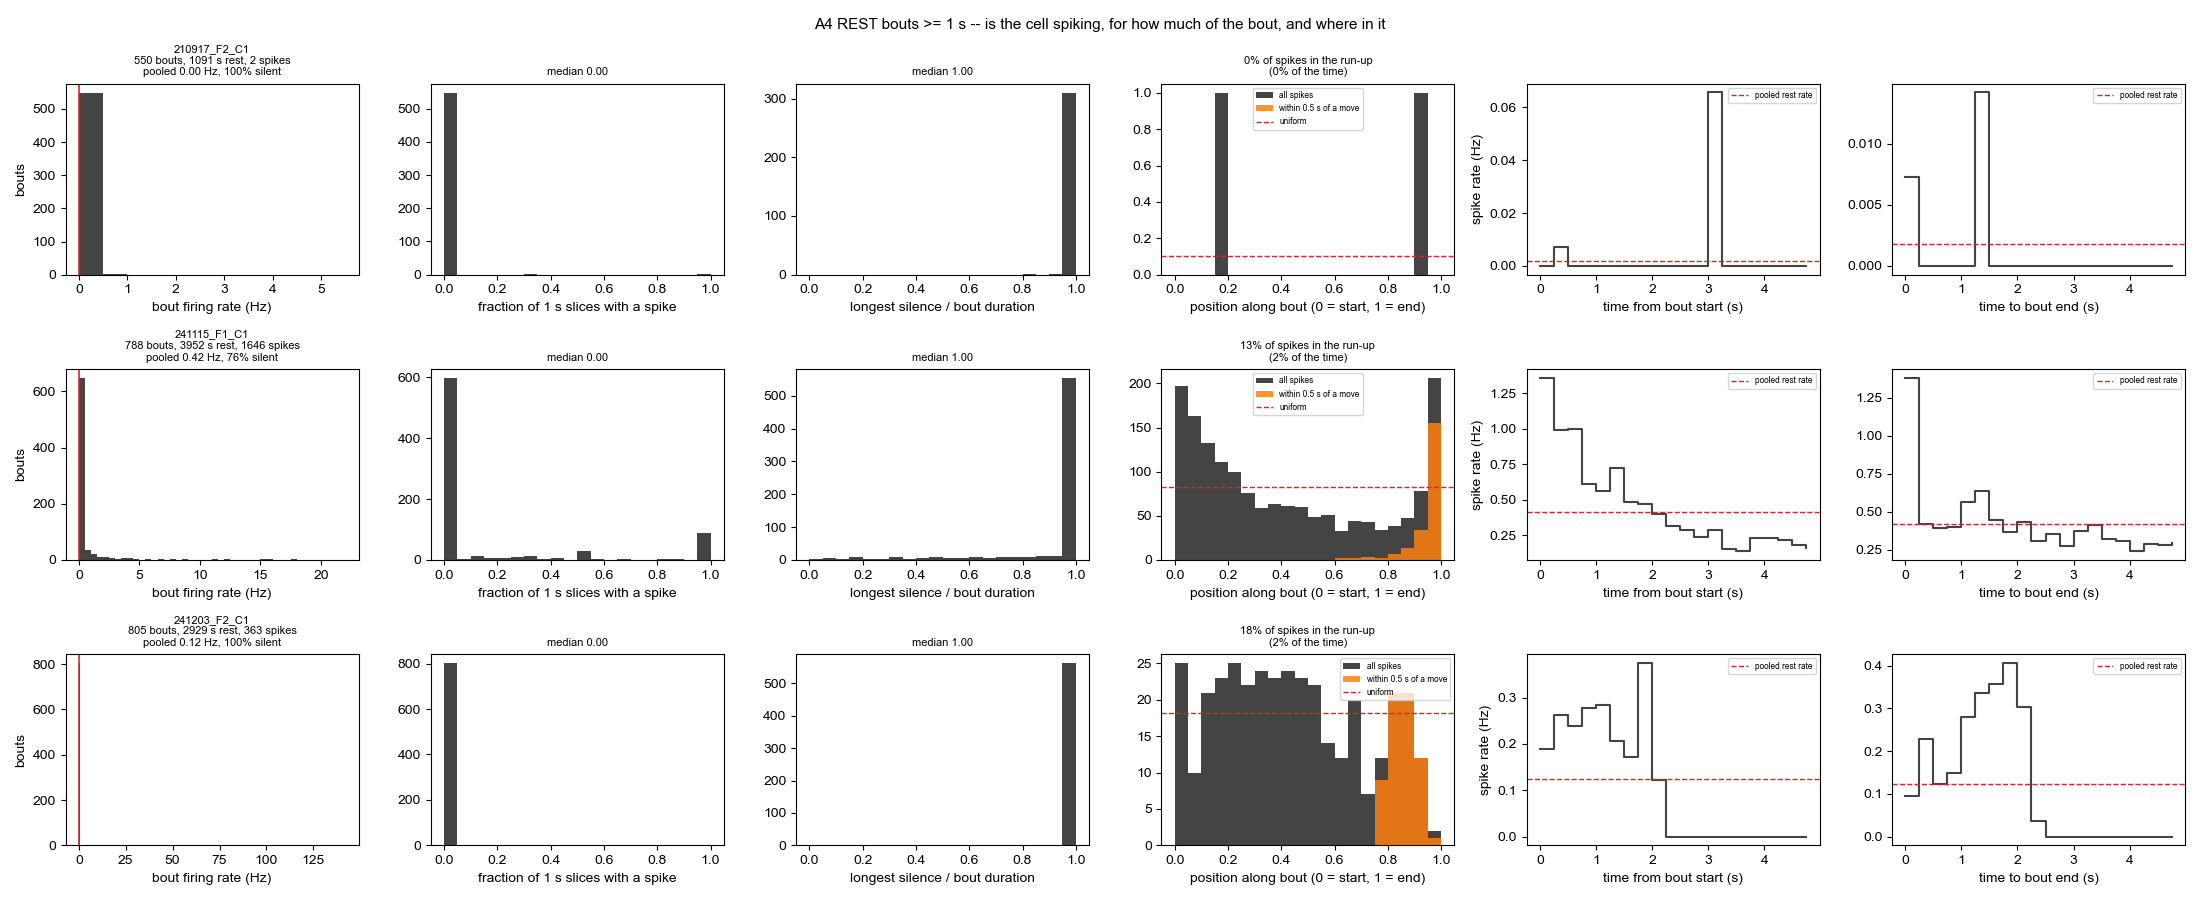

In [27]:
# [A4-SPIKING-2]
# ============================================================================
# A4 REST -- the census, drawn.  One row per cell, four panels.
# ============================================================================
#  1. bout firing rate (spikes / usable second) -- is there a rate at all
#  2. fraction of the bout's 1 s slices containing a spike -- 1.0 = throughout,
#     a pile-up at the left edge = a burst and then silence
#  3. longest silence as a fraction of the bout -- the same question from the
#     other side, and the one that is robust to bout length
#  4. where each spike sits along its bout -- flat = spread through the rest,
#     U-shaped = the spikes belong to the movements at either end. The dashed
#     line is what a uniform rate would give; the orange bars are the spikes
#     inside the 0.5 s run-up to a movement.
#  5/6. the same in seconds rather than fractions, from the bout's start and
#     from its end. Bouts differ in length, so a fixed-latency edge effect --
#     the tail of the movement that ended the previous bout, the ramp into the
#     next one -- smears out in panel 4 and shows up here.

cells_fig = list(summary_a4.index)
fig, axes = plt.subplots(len(cells_fig), 6, figsize=(22, 3.0 * len(cells_fig)),
                         squeeze=False)
for r, cid in enumerate(cells_fig):
    d = bouts_a4[bouts_a4['cell'] == cid]
    sp = spikes_a4[spikes_a4['cell'] == cid]
    s = summary_a4.loc[cid]

    ax = axes[r, 0]
    ax.hist(d['rate_hz'], bins=np.arange(0, max(d['rate_hz'].max(), 5) + 1, 0.5),
            color='#444444')
    ax.axvline(d['rate_hz'].median(), color='#d62728', lw=1.2)
    ax.set_title(f'{cid}\n{int(s["bouts"])} bouts, {s["rest_s"]:.0f} s rest, '
                 f'{int(s["spikes"])} spikes\npooled {s["rate_hz_pooled"]:.2f} Hz, '
                 f'{100*s["silent_bouts"]:.0f}% silent', fontsize=8)
    ax.set_xlabel('bout firing rate (Hz)')
    ax.set_ylabel('bouts')

    ax = axes[r, 1]
    ax.hist(d['frac_slices_with_spike'], bins=np.linspace(0, 1, 21),
            color='#444444')
    ax.set_title(f'median {s["median_frac_slices_spiking"]:.2f}', fontsize=8)
    ax.set_xlabel('fraction of 1 s slices with a spike')

    ax = axes[r, 2]
    ax.hist(d['frac_gap'], bins=np.linspace(0, 1, 21), color='#444444')
    ax.set_title(f'median {s["median_frac_gap"]:.2f}', fontsize=8)
    ax.set_xlabel('longest silence / bout duration')

    ax = axes[r, 3]
    if len(sp):
        bins = np.linspace(0, 1, 21)
        ax.hist(sp['frac_along_bout'], bins=bins, color='#444444',
                label='all spikes')
        ax.hist(sp.loc[sp['premove'], 'frac_along_bout'], bins=bins,
                color='#ff7f0e', alpha=0.85, label='within 0.5 s of a move')
        ax.axhline(len(sp) / 20, color='#d62728', ls='--', lw=1.0,
                   label='uniform')
        ax.legend(fontsize=6)
    ax.set_title(f'{100*s["frac_spikes_premove"]:.0f}% of spikes in the '
                 f'run-up\n({100*s["frac_time_premove"]:.0f}% of the time)',
                 fontsize=8)
    ax.set_xlabel('position along bout (0 = start, 1 = end)')

    # Seconds from each edge. Normalised by how many bouts are still running at
    # that latency, so the curve is a rate in Hz and does not simply decay
    # because the long bouts run out.
    edges_s = np.arange(0, 5.0 + 1e-9, 0.25)
    for ax, col, lab in ((axes[r, 4], 't_from_start', 'time from bout start (s)'),
                         (axes[r, 5], 't_to_end', 'time to bout end (s)')):
        if len(sp):
            counts = np.histogram(sp[col], bins=edges_s)[0]
            # bouts alive in each bin = those at least that long
            alive = np.array([(d['duration'] >= e).sum() for e in edges_s[1:]])
            with np.errstate(invalid='ignore', divide='ignore'):
                hz = counts / np.where(alive > 0, alive, np.nan) / np.diff(edges_s)
            ax.step(edges_s[:-1], hz, where='post', color='#444444')
            ax.axhline(s['rate_hz_pooled'], color='#d62728', ls='--', lw=1.0,
                       label='pooled rest rate')
            ax.legend(fontsize=6)
        ax.set_xlabel(lab)
        if col == 't_from_start':
            ax.set_ylabel('spike rate (Hz)')

fig.suptitle('A4 REST bouts >= %.0f s -- is the cell spiking, for how much of '
             'the bout, and where in it' % MIN_BOUT_A4, fontsize=11)
fig.tight_layout()
save_fig(fig, 'A4-SPIKING-2')

first_bin vs last_bin within each edge window, against the pooled rate of
the same bouts. A decay after onset shows as from-start first > last;
a pre-movement rise shows as to-end first > last (t_to_end counts
BACKWARD from the end, so its first bin is the last moment of the bout).
min_bouts_alive is the smallest n behind any bin -- if it is tiny the
curve is anecdote, not time course.


,cell,edge,first_bin_hz,last_bin_hz,pooled_hz,bouts,min_bouts_alive
0,241115_F1_C1,t_from_start,4.278,1.667,1.725,72,72.0
1,241115_F1_C1,t_to_end,4.056,1.056,1.725,72,72.0
2,241203_F2_C1,t_from_start,4.000,0.000,0.176,2,2.0
3,241203_F2_C1,t_to_end,2.000,0.000,0.176,2,2.0


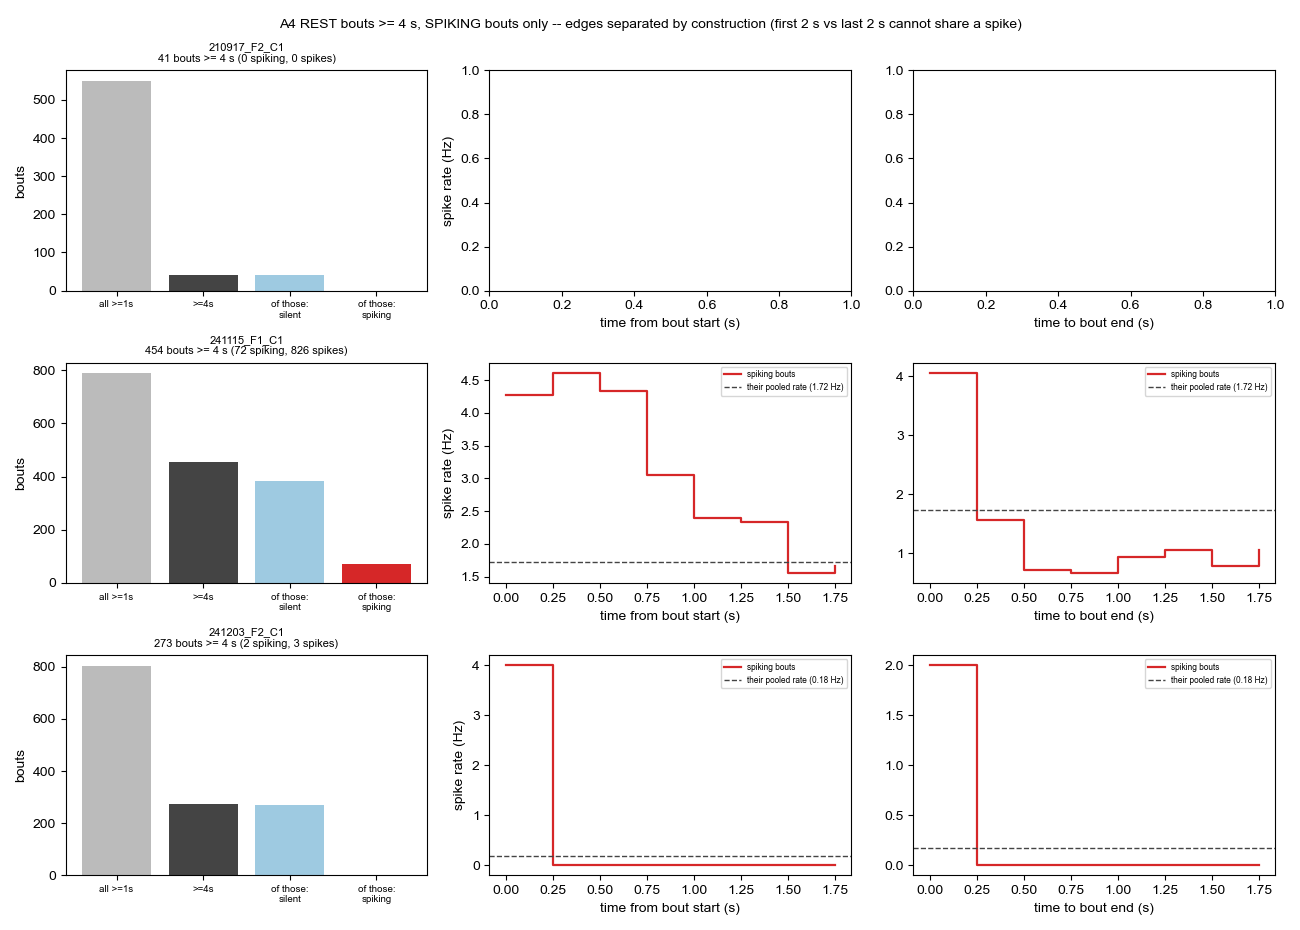

In [28]:
# [A4-SPIKING-3]
# ============================================================================
# A4 REST -- the edge-aligned rate, with the two confounds in A4-SPIKING-2 fixed
# ============================================================================
# Columns 5/6 of the census suggested that firing sits at the EDGES of a rest
# bout -- decaying for ~2 s after onset, rising in the last ~0.5 s -- with a
# quiet middle. Two things in that figure make the claim weaker than it looks,
# and both are fixed here:
#
# 1. THE EDGES ARE NOT SEPARATED. 241115 averages ~3.8 s per bout while both
#    panels span 0-5 s, so in a 2 s bout a spike 0.1 s before the end sits at
#    t_from_start = 1.9 AND t_to_end = 0.1. End-of-bout firing from short bouts
#    therefore also lands in the early part of the from-start panel. Gating on
#    bouts >= LONG_BOUT_S keeps the two windows from overlapping: with the gate,
#    a spike in the first EDGE_S is at least EDGE_S away from the other end.
# 2. THE BOUT POPULATION IS BIMODAL. Column 2 showed ~54% of 241115's bouts with
#    no spikes at all and a separate mode firing in every 1 s slice. A pooled
#    curve over that mixture describes neither. Bouts are split here into silent
#    and spiking, and only the spiking ones can carry a time course.
#
# Rates are counts / bouts-still-running / bin width, so the curve is in Hz and
# does not decay merely because the long bouts run out.

LONG_BOUT_S = 4.0        # >= 2 * EDGE_S, so the two edge windows cannot overlap
EDGE_S = 2.0             # how far in from each edge to look
EDGE_BIN_S = 0.25


def restrict_to_bouts(spikes, bouts):
    """Spikes belonging to the given bouts, safe when either side is empty.

    The obvious one-liner is a trap: ``df[[...list comprehension...]]`` selects
    zero COLUMNS rather than zero rows when the comprehension yields an empty
    list, so a cell with no spikes inside long bouts loses its columns and the
    next access raises KeyError. A numpy bool array indexes rows in every case.
    """
    if not len(spikes):
        return spikes
    keys = set(zip(bouts['trial'], bouts['epoch']))
    m = np.array([k in keys for k in zip(spikes['trial'], spikes['epoch'])],
                 dtype=bool)
    return spikes[m]


def edge_rate(spikes, bouts, col, edges_s):
    """Spike rate vs. time from a bout edge, normalised by bouts still running.

    Returns (bin_left, hz, n_alive). ``col`` is 't_from_start' or 't_to_end'.
    """
    if not len(bouts):
        return edges_s[:-1], np.full(len(edges_s) - 1, np.nan), np.zeros(len(edges_s) - 1)
    counts = (np.histogram(spikes[col], bins=edges_s)[0] if len(spikes)
              else np.zeros(len(edges_s) - 1))
    alive = np.array([(bouts['duration'] >= e).sum() for e in edges_s[1:]],
                     dtype=float)
    with np.errstate(invalid='ignore', divide='ignore'):
        hz = counts / np.where(alive > 0, alive, np.nan) / np.diff(edges_s)
    return edges_s[:-1], hz, alive


edges_e = np.arange(0, EDGE_S + 1e-9, EDGE_BIN_S)
cells_fig = [c for c in A4_CELLS if c in set(bouts_a4['cell'])]
fig, axes = plt.subplots(len(cells_fig), 3, figsize=(13, 3.1 * len(cells_fig)),
                         squeeze=False)
edge_rows = []
for r, cid in enumerate(cells_fig):
    d = bouts_a4[(bouts_a4['cell'] == cid)
                 & (bouts_a4['duration'] >= LONG_BOUT_S)]
    sp = spikes_a4[(spikes_a4['cell'] == cid)
                   & (spikes_a4['duration'] >= LONG_BOUT_S)]
    sp = restrict_to_bouts(sp, d)

    spiking = d[~d['silent']]
    sil = d[d['silent']]
    sp_sp = restrict_to_bouts(sp, spiking)

    # panel 1: how the gate and the split carve up the bouts
    ax = axes[r, 0]
    ax.bar(['all >=1s', f'>={LONG_BOUT_S:g}s', 'of those:\nsilent',
            'of those:\nspiking'],
           [int((bouts_a4['cell'] == cid).sum()), len(d), len(sil), len(spiking)],
           color=['#bbbbbb', '#444444', '#9ecae1', '#d62728'])
    ax.set_ylabel('bouts')
    ax.set_title(f'{cid}\n{len(d)} bouts >= {LONG_BOUT_S:g} s '
                 f'({len(spiking)} spiking, {sp_sp.shape[0]} spikes)', fontsize=8)
    ax.tick_params(axis='x', labelsize=7)

    # panels 2/3: the two edges, spiking bouts only, windows now disjoint
    for ax, col, lab in ((axes[r, 1], 't_from_start', 'time from bout start (s)'),
                         (axes[r, 2], 't_to_end', 'time to bout end (s)')):
        if len(spiking):
            x_, hz, alive = edge_rate(sp_sp, spiking, col, edges_e)
            ax.step(x_, hz, where='post', color='#d62728', lw=1.6,
                    label='spiking bouts')
            pooled = (spiking['n_spikes'].sum() / spiking['usable_s'].sum()
                      if spiking['usable_s'].sum() else np.nan)
            ax.axhline(pooled, color='#444444', ls='--', lw=1.0,
                       label=f'their pooled rate ({pooled:.2f} Hz)')
            ax.legend(fontsize=6)
            edge_rows.append({'cell': cid, 'edge': col,
                              'first_bin_hz': float(hz[0]),
                              'last_bin_hz': float(hz[-1]),
                              'pooled_hz': float(pooled),
                              'bouts': len(spiking),
                              'min_bouts_alive': (float(np.nanmin(alive))
                                                  if len(alive) else np.nan)})
        ax.set_xlabel(lab)
        if col == 't_from_start':
            ax.set_ylabel('spike rate (Hz)')

fig.suptitle(f'A4 REST bouts >= {LONG_BOUT_S:g} s, SPIKING bouts only -- '
             f'edges separated by construction (first {EDGE_S:g} s vs last '
             f'{EDGE_S:g} s cannot share a spike)', fontsize=10)
fig.tight_layout()
save_fig(fig, 'A4-SPIKING-3')

edge_a4 = pd.DataFrame(edge_rows)
print('first_bin vs last_bin within each edge window, against the pooled rate of')
print('the same bouts. A decay after onset shows as from-start first > last;')
print('a pre-movement rise shows as to-end first > last (t_to_end counts')
print('BACKWARD from the end, so its first bin is the last moment of the bout).')
print('min_bouts_alive is the smallest n behind any bin -- if it is tiny the')
print('curve is anecdote, not time course.')
display(edge_a4.round(3))

In [29]:
# [A4-SPIKING-4]
# ============================================================================
# Where are the spikes, and are the movements even being found?
# ============================================================================
# 210917_F2_C1 shows nothing in the exclusion sweep. Two explanations that lead
# to opposite conclusions, and this cell separates them:
#
#   (a) THE CELL BARELY FIRES. Then the empty panels are the finding, and no
#       amount of re-windowing will change them.
#   (b) THE TIMING IS BROKEN. The run-up window is built from t_to_move, which
#       comes from add_movement_timing's "maximal non-REST stretch with a
#       peak-to-peak excursion >= 8 px". On a noisy position channel -- and
#       210917 is the noisy one, the reason it needed the p90 v_rest -- those
#       stretches can be mis-found or missing, so the window lands in the wrong
#       place and the spikes that exist are excluded for the wrong reason.
#
# The distinction is visible in three numbers: spikes per state (a cell that is
# silent in REST but busy in MOVE is a different animal from one that is silent
# everywhere), the number and size of the detected movement stretches, and the
# fraction of frames that have a finite t_to_move at all -- +inf means "no later
# movement in this trial", and a cell whose REST frames are mostly +inf has no
# run-up to exclude, so the sweep cannot say anything about it.

MOVE_ONSET_PTP = 8.0        # add_movement_timing's own default


def movement_stretches(rec, min_move_ptp=MOVE_ONSET_PTP):
    """The stretches add_movement_timing keys on, recovered for inspection."""
    rows = []
    for tn, g in rec.groupby('trial', sort=True):
        t = g['t'].to_numpy(dtype=float)
        x = g['x'].to_numpy(dtype=float)
        st = g['state'].to_numpy()
        if len(t) < 2:
            continue
        dt = float(np.median(np.diff(t)))
        for a, b, v in ba._rle_states(st != ba.kin.STATE_REST):
            if not v:
                continue
            ptp = float(np.ptp(x[a:b]))
            rows.append({'trial': tn, 'duration': (b - a) * dt, 'ptp': ptp,
                         'counts': ptp >= min_move_ptp})
    return pd.DataFrame(rows, columns=['trial', 'duration', 'ptp', 'counts'])


where_rows = []
for cid in A4_CELLS:
    rec = prep_a4[cid]['rec']
    keep = ~prep_a4[cid]['cue'] & ~prep_a4[cid]['istep']
    st = rec['state'].to_numpy()
    n = np.nan_to_num(rec['n_sp'].to_numpy(dtype=float))
    dt = float(np.median(np.diff(rec['t'].to_numpy(dtype=float)[:50])))
    row = {'cell': cid, 'v_rest': rest_results[cid].get('v_rest', np.nan),
           'spikes_total': float(n[keep].sum())}
    for lab, s in (('rest', ba.kin.STATE_REST), ('drift', ba.kin.STATE_DRIFT),
                   ('move', ba.kin.STATE_MOVE)):
        m = keep & (st == s)
        row[f'{lab}_s'] = float(m.sum() * dt)
        row[f'{lab}_spikes'] = float(n[m].sum())
        row[f'{lab}_hz'] = (float(n[m].sum() / (m.sum() * dt))
                            if m.any() else np.nan)
    ms = movement_stretches(rec)
    row['stretches'] = len(ms)
    row['stretches_counting'] = int(ms['counts'].sum()) if len(ms) else 0
    row['median_stretch_ptp'] = float(ms['ptp'].median()) if len(ms) else np.nan
    # can the run-up even be defined for this cell's REST frames?
    is_rest = keep & (st == ba.kin.STATE_REST)
    t2m = rec['t_to_move'].to_numpy(dtype=float)
    row['rest_frames_with_finite_t_to_move'] = (
        float(np.isfinite(t2m[is_rest]).mean()) if is_rest.any() else np.nan)
    # and where do the REST spikes actually sit relative to the next movement?
    sp_rest = is_rest & (n > 0)
    tt = t2m[sp_rest]
    tt = tt[np.isfinite(tt)]
    row['n_rest_spike_frames'] = int(sp_rest.sum())
    row['median_t_to_move_at_rest_spikes_ms'] = (float(np.median(tt)) * 1e3
                                                 if len(tt) else np.nan)
    where_rows.append(row)

where_a4 = pd.DataFrame(where_rows).set_index('cell')
print('Spikes by state, then whether the movement timing is usable at all.')
print('  *_hz          -- a cell silent in REST but firing in MOVE is case (a)')
print('                   with structure; silent everywhere is case (a) plain.')
print('  stretches_counting -- movements big enough (>= %.0f px ptp) to define'
      % MOVE_ONSET_PTP)
print('                   an onset. Near zero means t_to_move is meaningless')
print('                   and the exclusion sweep has nothing to exclude.')
print('  rest_frames_with_finite_t_to_move -- +inf where no later movement')
print('                   exists in the trial; a low value is case (b).')
print('  median_t_to_move_at_rest_spikes_ms -- of the REST frames that DO carry')
print('                   a spike, how long before the next movement they sit.')
print('                   This is the sweep\'s answer in one number, and it does')
print('                   not depend on any exclusion window.')
display(where_a4.round(3))

Spikes by state, then whether the movement timing is usable at all.
  *_hz          -- a cell silent in REST but firing in MOVE is case (a)
                   with structure; silent everywhere is case (a) plain.
  stretches_counting -- movements big enough (>= 8 px ptp) to define
                   an onset. Near zero means t_to_move is meaningless
                   and the exclusion sweep has nothing to exclude.
  rest_frames_with_finite_t_to_move -- +inf where no later movement
                   exists in the trial; a low value is case (b).
  median_t_to_move_at_rest_spikes_ms -- of the REST frames that DO carry
                   a spike, how long before the next movement they sit.
                   This is the sweep's answer in one number, and it does
                   not depend on any exclusion window.


,v_rest,spikes_total,rest_s,rest_spikes,rest_hz,drift_s,drift_spikes,drift_hz,move_s,move_spikes,move_hz,stretches,stretches_counting,median_stretch_ptp,rest_frames_with_finite_t_to_move,n_rest_spike_frames,median_t_to_move_at_rest_spikes_ms
cell,,,,,,,,,,,,,,,,,
210917_F2_C1,49.0,16769.0,2615.835,275.0,0.105,946.048,65.0,0.069,1881.224,16429.0,8.733,4610,461,1.875,0.163,275,175.000
241115_F1_C1,30.0,55783.0,4219.074,2879.0,0.682,94.530,2121.0,22.437,968.232,50783.0,52.449,1307,530,5.311,0.159,2879,357.501
241203_F2_C1,33.0,32939.0,3513.832,2593.0,0.738,561.816,486.0,0.865,1117.352,29860.0,26.724,2172,528,0.937,0.221,2551,430.001


within-bout rate scatter at 25 ms, by how many spikes the bout contained


bouts  median_sd  median_ptp  median_mean
cell         n_spikes_census                                           
210917_F2_C1 0                  548       0.00        0.00         0.00
             1                    2       2.16       15.95         0.44
241115_F1_C1 0                  597       0.00        0.00         0.00
             1                   48       2.14       16.32         0.32
             2-3                 52       3.52       20.55         0.74
             4-10                48       5.42       24.98         2.21
             >10                 43       6.87       28.84         7.76
241203_F2_C1 0                  801       0.00        0.00         0.00
             1                    1       1.27       15.88         0.14
             2-3                  1       1.80       28.69         0.14
             >10                  2      36.46      133.40        80.04

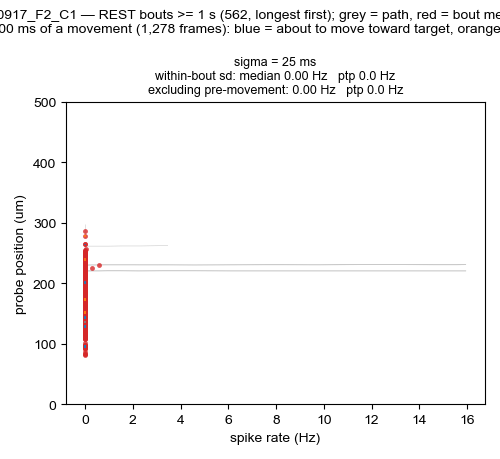

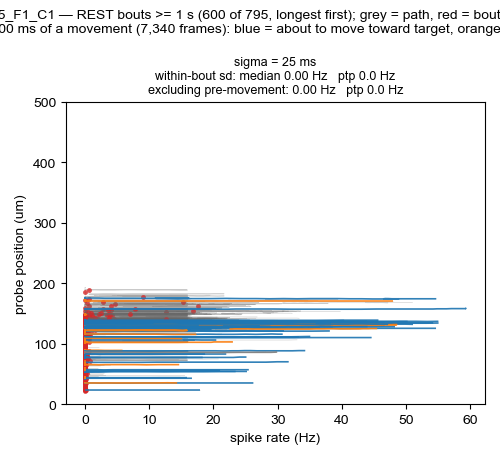

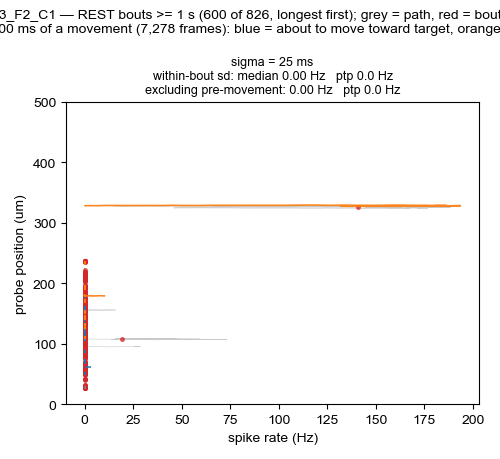

In [30]:
# [A4-PATHS-1]
# ============================================================================
# A4 REST -- rate vs. position, 25 ms only, paths shown
# ============================================================================
# show_paths=True is the point: each grey line is one bout walked frame by
# frame, so the plot shows how the rate *evolves* over the bout rather than
# collapsing it to a mean. On A2 these were short horizontal streaks around a
# steady rate. If A4 bouts run from 0 Hz out to a spike-sized excursion and back
# to 0, the streak is not a rate wandering -- it is the kernel drawing one
# spike, and the red bout-mean marker is that spike divided by the bout length.
#
# No fit lines. This figure is about what the raw paths look like, and a
# regression line drawn over near-empty spike trains invites the eye to read a
# relation the census says is not there -- which is why the old two-kernel fit
# cell is gone rather than merely unused.
#
# Axes are autoscaled per figure by default -- the A2 range (0-100 Hz) is wrong
# for a cell whose bouts sit under 5 Hz. Set XLIM_A4_REST to fix them once the
# range is known.

XLIM_A4_REST = None      # e.g. (0, 20) to pin the rate axis across cells
YLIM_A4_REST = YLIM_A4   # position axis kept common with the A2 panels

kernels_a4 = {}
for cid in A4_CELLS:
    p = prep_a4[cid]
    fig, spread = plot_rate_vs_position_kernels(
        _blank_a4(p['rec'], RATE_COL_A4, p['cue'] | p['istep']), cid,
        sigmas_s=(SIGMA_A4,), state=ba.kin.STATE_REST,
        min_duration_s=MIN_BOUT_A4, max_bouts=600,
        show_paths=True, show_means=True,
        xlim=XLIM_A4_REST, ylim=YLIM_A4_REST,
        highlight_colors=DIRECTION_COLORS, premove_s=PREMOVE_A4, fit_lines=None,
        sinq=sinq, fname_tag='A4-PATHS-1')
    kernels_a4[cid] = (fig, spread)

# The streak length in numbers, next to the spike count that produced it: a
# within-bout sd of several Hz off two spikes is the kernel, not the cell.
streaks_a4 = pd.concat(
    [s.assign(cell=cid) for cid, (_, s) in kernels_a4.items() if s is not None],
    ignore_index=True)
streaks_a4 = streaks_a4.merge(
    bouts_a4[['cell', 'trial', 'epoch', 'n_spikes', 'rate_hz', 'silent']],
    on=['cell', 'trial', 'epoch'], how='left', suffixes=('', '_census'))
print('within-bout rate scatter at 25 ms, by how many spikes the bout contained')
display(streaks_a4.groupby(['cell', pd.cut(streaks_a4['n_spikes_census'],
                                           [-0.1, 0.1, 1.1, 3.1, 10.1, np.inf],
                                           labels=['0', '1', '2-3', '4-10', '>10'])],
                           observed=True)
        .agg(bouts=('rate_sd', 'size'), median_sd=('rate_sd', 'median'),
             median_ptp=('rate_ptp', 'median'),
             median_mean=('rate_mean', 'median')).round(2))

## What the highlighted stretches in the REST path plots mean

`[A4-RUNUP-DOC]`

**Colour convention in this section** (`DIRECTION_COLORS`, set in `A4-PREP-1`):
**blue = the probe is about to move toward the target** (force going up),
**orange = about to move away**. This is the reverse of
`plot_rate_vs_position_kernels`'s library default, and it is applied *only* to
the A4 path panels — `EXC_COLORS` and `COND_COLORS`, which the excursion and
lead/lag panels use, deliberately reserve blue for away-from-target and are left
alone. The captions are generated from the colours actually passed, so they
cannot drift out of step with them.

`Figure 12.png` was drawn under the old convention, so its long 40-60 Hz streaks
are **orange** there and **blue** in everything below. Same data, same meaning.

### The finding

Almost every long horizontal excursion -- the streaks running out to 40-60 Hz --
is a stretch within 500 ms of a movement onset whose first 150 ms of
displacement is toward the target. The grey paths stay bunched under ~15 Hz.

The number in that figure's own title is the result: within-bout rate scatter is
**median sd 1.34 Hz, ptp 15.9 Hz** over the whole bout, and **0.02 Hz, ptp
0.4 Hz** once the pre-movement window is excluded. Essentially *all* rate
variation during "rest" lives in the run-up to the next movement. Outside it the
trace is flat and near zero -- the same conclusion the census reached from spike
counts, arrived at independently from the smoothed rate.

### Two claims, and they are different

**1. The highlighted stretches are not contamination -- they are the motor
command.** The state classifier works on *position*. A motor neuron that starts
firing to produce a movement necessarily fires before the probe has visibly
moved, so the burst that *causes* the movement is still inside the bout the
classifier calls REST. The 0.5 s pre-movement window picks up exactly that. The
label boundary is late relative to the neural event, by construction.

**2. Toward-target dominates away because force is asymmetric.** Increasing
force needs recruitment -- spikes. Relaxing does not; it is produced by
*stopping*, so a movement away from the target is preceded by a rate
*decrease*, which on this plot is a short streak near zero rather than a long
one. Pooling the two directions would report the net of two opposing
populations, which is why `add_movement_timing` carries `next_dx_init` and these
plots split on its sign.

### Reading the rate axis

A single spike through the 25 ms Gaussian has a peak of
**1/(sigma*sqrt(2*pi)) = 15.96 Hz**, a FWHM of 58.9 ms, and +/-3 sigma of
support, i.e. 150 ms wide; its area is exactly one spike. So **~16 Hz is the
quantum of this axis** -- an isolated excursion at ~16 Hz *is* one spike, and the
median bout's ptp of 15.9 Hz means the median bout's entire rate excursion is a
single spike.

Two spikes, measured: 10 ms apart peak at 31.3 Hz, 25 ms at 28.1 Hz, 50 ms at
19.4 Hz, and by 100 ms they are back to 16.0 Hz and independent. The 40-60 Hz
streaks therefore need **3-4+ spikes inside ~50 ms** -- genuine 60-100 Hz
instantaneous bursts, not a smoothing artefact of one or two spikes. They are
qualitatively different events from the isolated spikes scattered elsewhere.

`A4-PATHS-2` below redraws the same figure with the run-up **removed** rather
than highlighted, and highlights the other edge instead -- the frames just after
a rest begins, where the previous movement's firing is decaying away. That is
the complementary half of the same story, and the half the census's column-5
decay was pointing at.

c:\Users\tony\Code\FlyLearning\figure7_analysis.py:469: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, axes = plt.subplots(1, n, figsize=(5.0 * n, 4.6), sharex=True, sharey=True,


210917_F2_C1: 63,571 frames within 1 s of a rest onset; 81,094 frames blanked (cue + step + run-up)
241115_F1_C1: 86,828 frames within 1 s of a rest onset; 99,612 frames blanked (cue + step + run-up)
241203_F2_C1: 81,237 frames within 1 s of a rest onset; 96,622 frames blanked (cue + step + run-up)

Firing in the first 1 s of a rest bout, run-up already excluded.
enrichment > 1 means the spikes that remain sit just after the rest began.


,rest_s_after_dropping_runup,post_onset_s,spikes_total,spikes_post,frac_time_post,frac_spikes_post,hz_post,hz_elsewhere,enrichment
cell,,,,,,,,,
210917_F2_C1,2539.178,183.000,94.0,35.0,0.072,0.372,0.191,0.025,5.166
241115_F1_C1,4090.463,333.506,2397.0,985.0,0.082,0.411,2.953,0.376,5.040
241203_F2_C1,3383.287,273.466,1153.0,1015.0,0.081,0.880,3.712,0.044,10.891


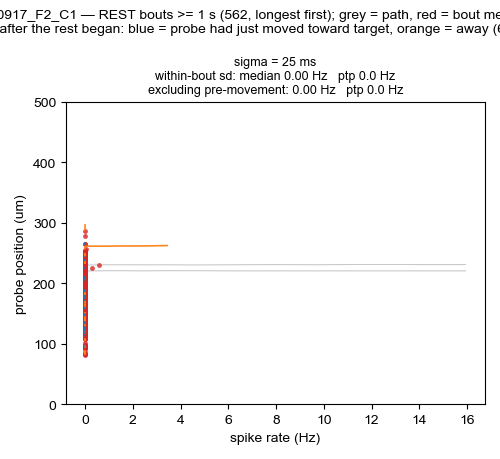

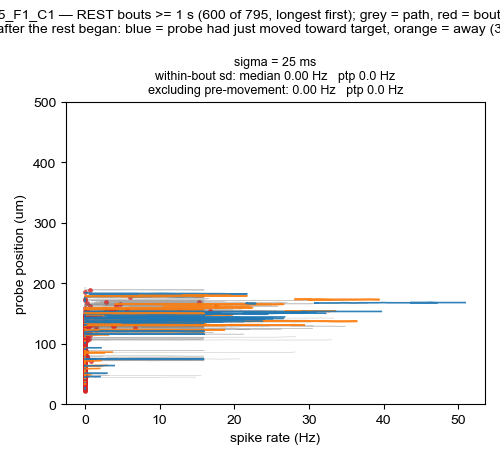

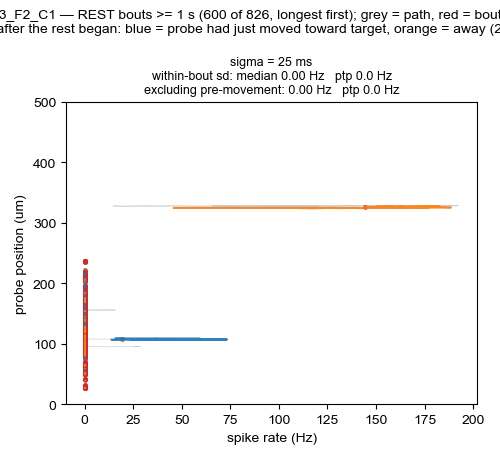

In [31]:
# [A4-PATHS-2]
# ============================================================================
# A4 REST paths -- run-up REMOVED, post-rest-onset highlighted instead
# ============================================================================
# Figure 12 showed that the rate excursions during REST are the run-up to the
# next movement (see A4-ORANGE-DOC). Two changes here:
#
#   * the pre-movement frames are BLANKED, not highlighted, so what is left is
#     rest that is not about to become a movement;
#   * the frames just AFTER a rest begins are highlighted instead, split by the
#     direction the probe travelled during the movement that just ended.
#
# The split column has to be built: add_movement_timing carries next_dx_init for
# the movement ahead but nothing for the one behind, so prev_dx_net is computed
# here by the same construction -- maximal non-REST stretches with a peak-to-peak
# excursion of at least min_move_ptp, net displacement end minus start.
#
# As with the run-up, selection is by TIMING only. Highlighting frames because
# the rate was changing would guarantee finding a rate change.

POST_REST_S = 1.0        # how long after rest onset counts as "just settled"


def add_prev_movement_dx(records, min_move_ptp=8.0, out='prev_dx_net'):
    """Net displacement of the movement that ended immediately before each frame.

    Positive = the probe had just moved toward the target (force went up), so
    the cell was recruited and is now relaxing; negative = it had just moved
    away. NaN where no earlier movement exists in the trial.
    """
    rec = records.copy()
    vals = np.full(len(rec), np.nan)
    pos = np.arange(len(rec))
    for _, g in rec.groupby('trial', sort=False):
        idx = pos[rec.index.get_indexer(g.index)]
        t = g['t'].to_numpy(dtype=float)
        x = g['x'].to_numpy(dtype=float)
        st = g['state'].to_numpy()
        stretches = [(a, b) for a, b, v in ba._rle_states(st != ba.kin.STATE_REST)
                     if v and (not min_move_ptp or np.ptp(x[a:b]) >= min_move_ptp)]
        if not stretches:
            continue
        offsets = np.array([t[b - 1] for _, b in stretches])
        dx_net = np.array([x[b - 1] - x[a] for a, b in stretches])
        k = np.searchsorted(offsets, t, side='left') - 1
        v = np.full(len(t), np.nan)
        v[k >= 0] = dx_net[k[k >= 0]]
        vals[idx] = v
    rec[out] = vals
    return rec


kernels_postrest_a4 = {}
for cid in A4_CELLS:
    p = prep_a4[cid]
    rec = p['rec']
    if 'prev_dx_net' not in rec.columns:
        rec = add_prev_movement_dx(rec)
        prep_a4[cid]['rec'] = rec
        rest_results[cid]['records'] = rec

    post = rec['t_since_move'].to_numpy() <= POST_REST_S
    rec_h = rec.assign(_post_rest=post)
    # Drop the cue, the current step AND the run-up. What survives is rest that
    # is neither imposed nor about to end.
    drop = p['cue'] | p['istep'] | p['premove']

    out = plot_rate_vs_position_kernels(
        _blank_a4(rec_h, RATE_COL_A4, drop), cid,
        sigmas_s=(SIGMA_A4,), state=ba.kin.STATE_REST,
        min_duration_s=MIN_BOUT_A4, max_bouts=600,
        show_paths=True, show_means=True,
        xlim=None, ylim=YLIM_A4,
        premove_s=0, fit_lines=None,
        highlight_col='_post_rest', highlight_sign_col='prev_dx_net',
        highlight_colors=DIRECTION_COLORS,
        highlight_label=(f'first {POST_REST_S * 1e3:.0f} ms after the rest '
                         f'began: blue = probe had just moved toward '
                         f'target, orange = away'),
        sinq=sinq, fname_tag='A4-PATHS-2')
    kernels_postrest_a4[cid] = out
    print(f'{cid}: {int(post.sum()):,} frames within {POST_REST_S:g} s of a '
          f'rest onset; {int(drop.sum()):,} frames blanked (cue + step + run-up)')

# The number that decides whether the highlight is worth drawing: spikes in the
# post-onset window against the time it occupies, inside REST and with the
# run-up already gone. Above 1.0 means firing is concentrated just after rest
# begins -- the decay of the movement that just finished, not rest firing.
post_rows = []
for cid in A4_CELLS:
    p = prep_a4[cid]
    rec = p['rec']
    m_rest = ((rec['state'].to_numpy() == ba.kin.STATE_REST)
              & ~p['cue'] & ~p['istep'] & ~p['premove'])
    post = rec['t_since_move'].to_numpy() <= POST_REST_S
    n = np.nan_to_num(rec['n_sp'].to_numpy(dtype=float))
    dt = float(np.median(np.diff(rec['t'].to_numpy(dtype=float)[:50])))
    sp_all, sp_post = n[m_rest].sum(), n[m_rest & post].sum()
    t_all, t_post = m_rest.sum() * dt, (m_rest & post).sum() * dt
    post_rows.append({
        'cell': cid,
        'rest_s_after_dropping_runup': t_all,
        'post_onset_s': t_post,
        'spikes_total': sp_all,
        'spikes_post': sp_post,
        'frac_time_post': t_post / t_all if t_all else np.nan,
        'frac_spikes_post': sp_post / sp_all if sp_all else np.nan,
        'hz_post': sp_post / t_post if t_post else np.nan,
        'hz_elsewhere': ((sp_all - sp_post) / (t_all - t_post)
                         if t_all > t_post else np.nan)})

post_rest_a4 = pd.DataFrame(post_rows).set_index('cell')
post_rest_a4['enrichment'] = (post_rest_a4['frac_spikes_post']
                              / post_rest_a4['frac_time_post'])
print(f'\nFiring in the first {POST_REST_S:g} s of a rest bout, run-up already '
      f'excluded.\nenrichment > 1 means the spikes that remain sit just after '
      f'the rest began.')
display(post_rest_a4.round(3))

Spikes surviving each exclusion, inside REST, cue and current step
already removed. frac_spikes_left is the hypothesis as a number: if
every spike is tied to a movement, it stays near 0 until the excluded
window drops below the spike-to-movement interval, then climbs.
hz_left is the rate over what is left -- the flat baseline this cell
holds when it is not about to move.
max_rate_left > 0 with spikes_left == 0 is the kernel tail leaking past
the blank, not firing during the surviving window.


frac_spikes_left                             spikes_left          \
exclude_ms              0.0    72.5   125.0  250.0  500.0       0.0     72.5    
cell                                                                            
210917_F2_C1              1.0  0.905  0.789  0.498  0.342       275.0   249.0   
241115_F1_C1              1.0  0.925  0.901  0.862  0.833      2879.0  2664.0   
241203_F2_C1              1.0  0.943  0.881  0.711  0.445      2593.0  2446.0   

                                     hz_left                              \
exclude_ms     125.0   250.0   500.0   0.0    72.5   125.0  250.0  500.0   
cell                                                                       
210917_F2_C1   217.0   137.0    94.0   0.105  0.096  0.084  0.053  0.037   
241115_F1_C1  2594.0  2482.0  2397.0   0.682  0.636  0.622  0.599  0.586   
241203_F2_C1  2284.0  1844.0  1153.0   0.738  0.701  0.658  0.537  0.341   

             max_rate_left                                      
exclude_ms           0.0      72.5     125.0    250.0    500.0  
cell                                                            
210917_F2_C1       170.511  170.511  170.511  170.511  170.511  
241115_F1_C1        69.603   69.603   69.603   69.603   69.603  
241203_F2_C1       206.218  206.218  206.218  206.218  201.204

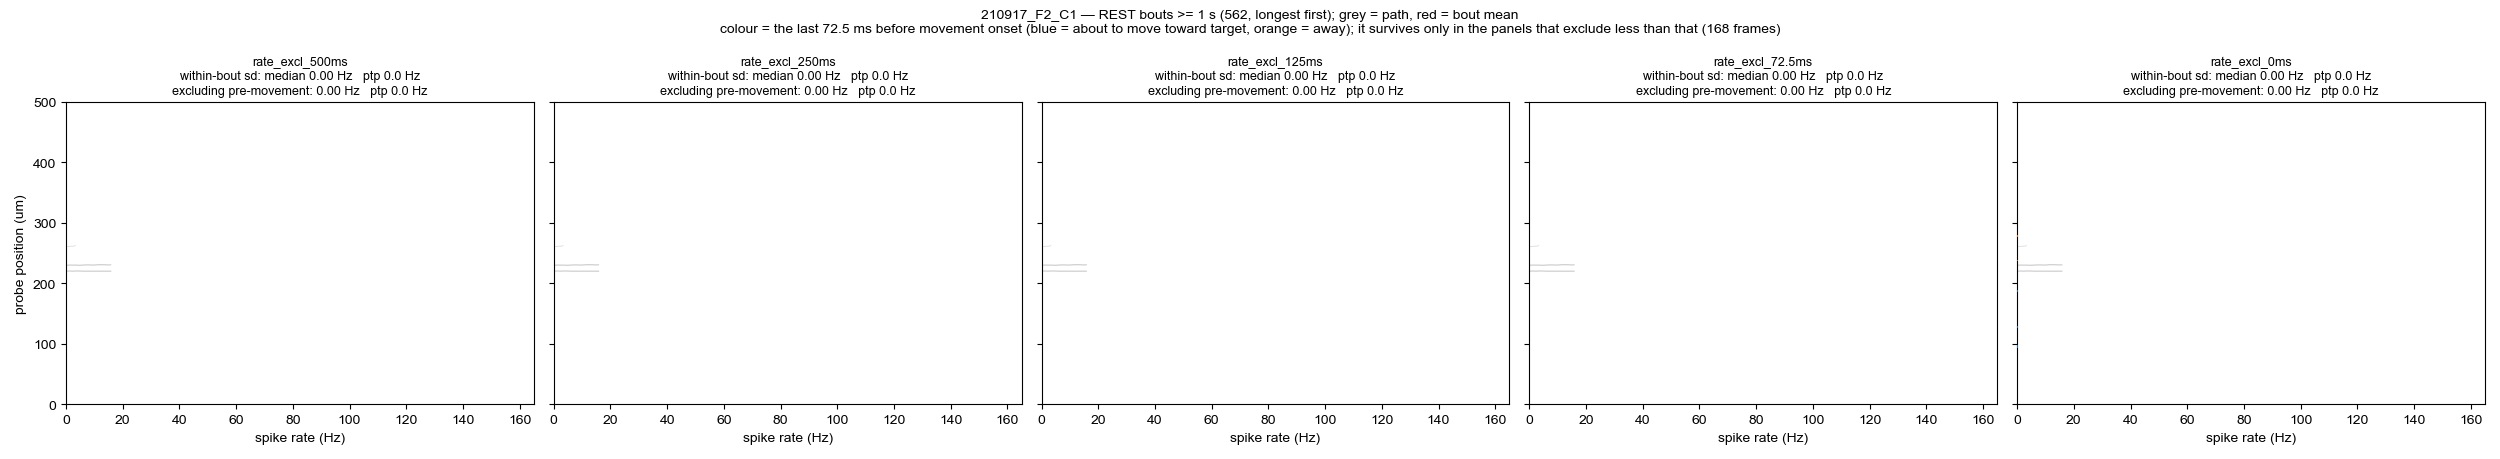

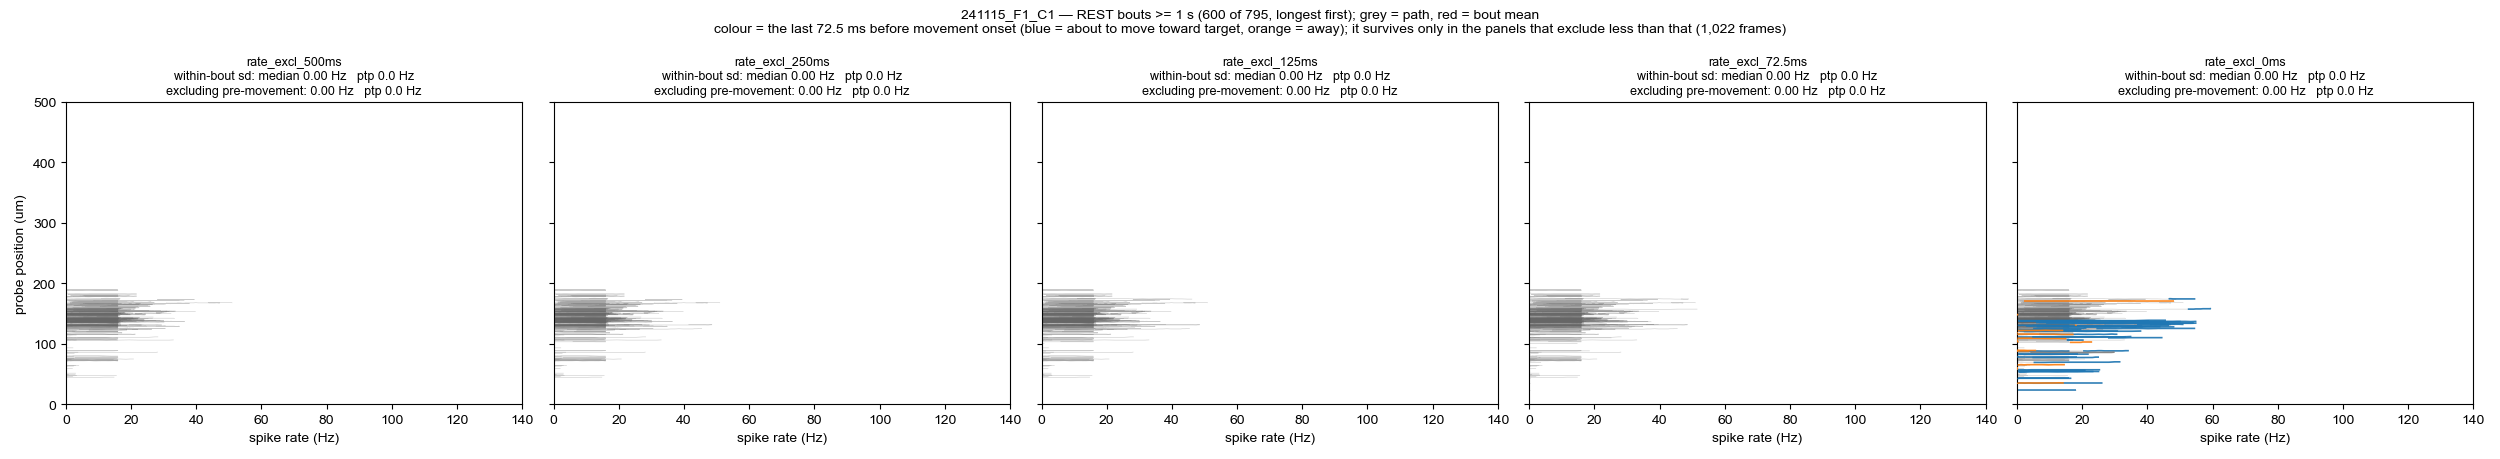

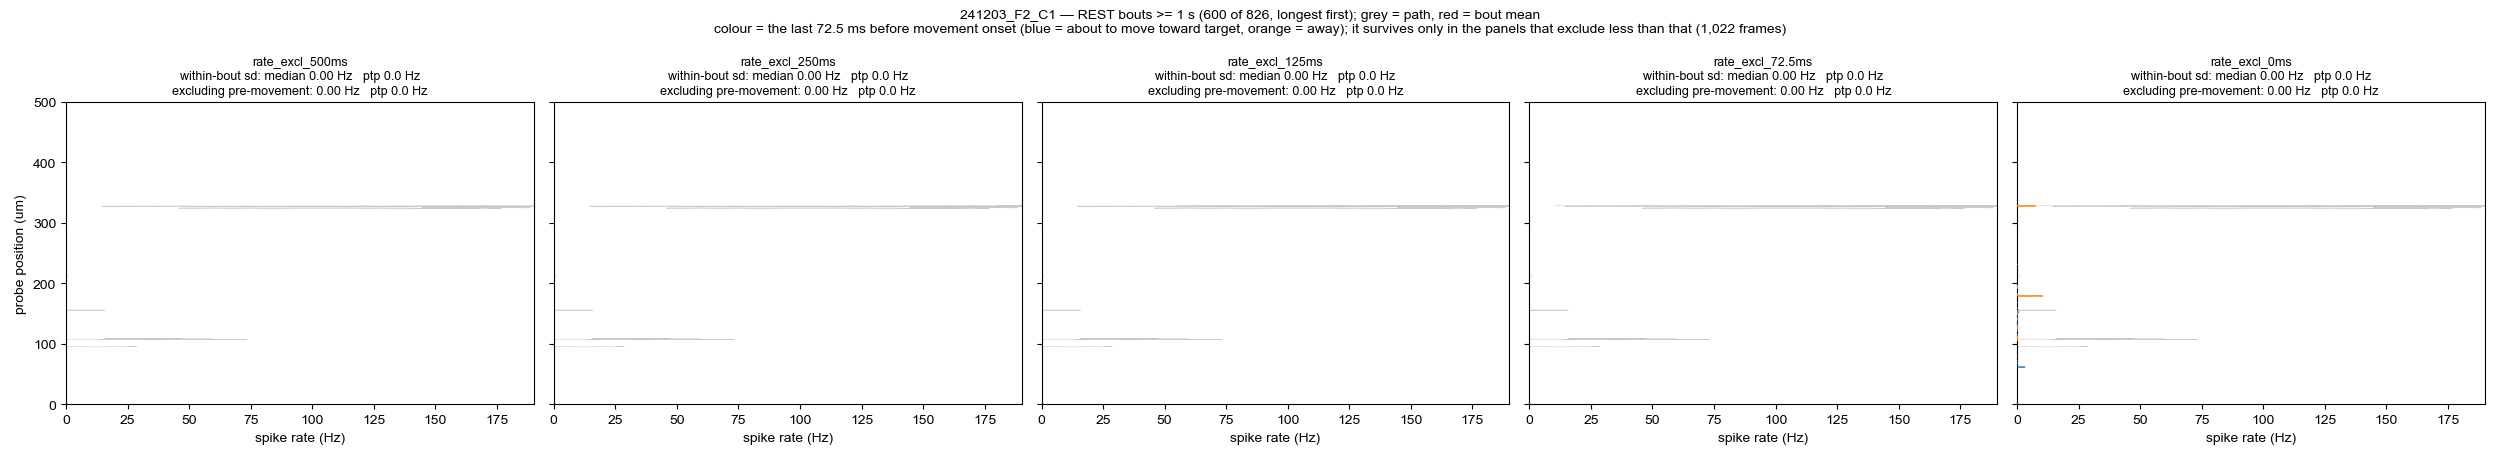

In [32]:
# [A4-PATHS-3]
# ============================================================================
# How close to the movement do the spikes sit?  Exclude a shrinking run-up.
# ============================================================================
# ANSWERING "is there an input I can change in a loop?": not for this. premove_s
# sets the width of the HIGHLIGHT, not what is excluded -- exclusion is done by
# NaN-ing the rate column with _blank_a4, the idiom A4-PATHS-2 uses. But the
# sweep does not need a loop of separate figures, and it is better off without
# one: rate_cols takes a list, and the function draws ONE PANEL PER COLUMN with
# shared axes. So four columns of the same rate, each blanked over a different
# run-up window, give four panels of the SAME bouts on the SAME scale. Separate
# figures would autoscale independently, which is precisely the comparison this
# is trying to make.
#
# THE DESIGN. Panel k blanks every frame within EXCLUDE_S[k] of a movement
# onset, down to 0 -- the last panel excludes nothing and is the reference. The
# highlight is the SAME in every panel: the final 72.5 ms before onset, coloured
# by the direction the probe is about to take. Since a panel NaNs its own
# excluded window and NaN is not drawn, the colour survives only where the
# exclusion is narrower than 72.5 ms -- i.e. only in the 0 ms panel. That is
# deliberate: it marks, on one fixed scale, where the final approach sits
# relative to everything that survives the wider exclusions.
#
# THE HYPOTHESIS being tested, in your words: if A4 spikes are always tied to
# movement, excluding 500 ms should leave the traces flat, and colour should
# reappear only as the excluded window shrinks past the spikes. The window at
# which excursions come back is then a crude read on how long before movement
# onset this cell fires -- crude because it is bounded by the frame rate and by
# the kernel's +/-75 ms of support, so nothing below ~75 ms is resolvable and
# the 72.5 ms panel is at that floor by construction.
#
# THE LEAK, and it will mislead you if it is not watched. Blanking removes
# FRAMES, but the rate in a surviving frame was smoothed with +/-3 sigma
# (+/-75 ms) of support, so it still carries the tail of spikes that were
# excluded. On a synthetic with a burst placed 100 ms before onset, the 125 ms
# panel showed a surviving rate of 4.4 Hz with ZERO surviving spikes -- entirely
# the tail of the excluded burst. So a small bump surviving an exclusion is NOT
# evidence of a spike in the surviving window, and the 72.5 ms panel sits inside
# the kernel's own support, where leakage is guaranteed. spikes_left in the
# table below is the honest arbiter; max_rate_left is printed beside it so the
# gap between them is visible rather than inferred.
#
# WHAT IT CANNOT DO: this is a floor on the spike-to-movement interval, not a
# latency. The classifier times movement onset from POSITION, which lags the
# force that causes it. A4-STA-1 is the version with a real trigger and a
# matched control; this is the quick look.

EXCLUDE_S = (0.500, 0.250, 0.125, 0.0725, 0.0)
PATHS3_HIGHLIGHT_S = 0.0725     # colour ONLY the last 72.5 ms, in every panel
PATHS3_SHOW_MEANS = False              # the red bout-mean dots, off as asked


def excluded_rate_columns(rec, windows=EXCLUDE_S, rate_col=RATE_COL_A4,
                          base_drop=None, timing_col='t_to_move',
                          prefix='rate_excl'):
    """One rate column per exclusion window, each NaN inside that window.

    ``timing_col`` chooses which edge of the bout is being walked away from:
    ``t_to_move`` counts DOWN to the next movement (the run-up), while
    ``t_since_move`` counts UP from the end of the last one (the entry into
    rest). Everything else about the sweep is identical, which is the point --
    the two are the same measurement at opposite ends of the bout.
    """
    t2m = rec[timing_col].to_numpy(dtype=float)
    base = (np.zeros(len(rec), dtype=bool) if base_drop is None
            else np.asarray(base_drop, dtype=bool))
    out, cols = rec.copy(), []
    for w in windows:
        col = f'{prefix}_{w * 1e3:g}ms'
        v = rec[rate_col].to_numpy(dtype=float).copy()
        v[base | (t2m <= w)] = np.nan
        out[col] = v
        cols.append(col)
    return out, cols


paths3_a4, paths3_rows = {}, []
for cid in A4_CELLS:
    p = prep_a4[cid]
    rec, cols = excluded_rate_columns(p['rec'], base_drop=p['cue'] | p['istep'])
    # Highlight = the full run-up. Each panel's own blanking trims it to the
    # part that survives there, so one mask serves all four.
    rec = rec.assign(_runup=rec['t_to_move'].to_numpy(dtype=float)
                     <= PATHS3_HIGHLIGHT_S)

    # A common x range, taken from the least-excluded panel so every panel is
    # judged on the same scale. Autoscaling per panel would hide the very
    # shrinkage the sweep is looking for.
    finite = rec[cols[-1]].to_numpy(dtype=float)
    finite = finite[np.isfinite(finite)]
    hi = float(np.nanpercentile(finite, 99.9)) if len(finite) else 10.0
    xlim = (0, max(np.ceil(hi / 5) * 5, 10.0))

    out = plot_rate_vs_position_kernels(
        rec, cid, rate_cols=cols, state=ba.kin.STATE_REST,
        min_duration_s=MIN_BOUT_A4, max_bouts=600,
        show_paths=True, show_means=PATHS3_SHOW_MEANS,
        xlim=xlim, ylim=YLIM_A4,
        premove_s=0, fit_lines=None,
        highlight_col='_runup', highlight_sign_col='next_dx_init',
        highlight_colors=DIRECTION_COLORS,
        highlight_label=(f'colour = the last {PATHS3_HIGHLIGHT_S * 1e3:.1f} ms '
                         f'before movement onset (blue = about to move toward '
                         f'target, orange = away); it survives only in the '
                         f'panels that exclude less than that'),
        sinq=sinq, fname_tag='A4-PATHS-3')
    paths3_a4[cid] = out

    # The numbers behind the picture: what actually survives each window.
    t2m = p['rec']['t_to_move'].to_numpy(dtype=float)
    n_sp = np.nan_to_num(p['rec']['n_sp'].to_numpy(dtype=float))
    is_rest = p['rec']['state'].to_numpy() == ba.kin.STATE_REST
    keep0 = is_rest & ~p['cue'] & ~p['istep']
    dt = float(np.median(np.diff(p['rec']['t'].to_numpy(dtype=float)[:50])))
    total = n_sp[keep0].sum()
    for w in EXCLUDE_S:
        surv = keep0 & (t2m > w)
        paths3_rows.append({
            'cell': cid, 'exclude_ms': w * 1e3,
            'rest_s_left': float(surv.sum() * dt),
            'spikes_left': float(n_sp[surv].sum()),
            'frac_spikes_left': (float(n_sp[surv].sum() / total)
                                 if total else np.nan),
            'hz_left': (float(n_sp[surv].sum() / (surv.sum() * dt))
                        if surv.any() else np.nan),
            # rate surviving the blank, which includes the kernel tail of
            # spikes that did NOT survive -- compare against spikes_left
            'max_rate_left': (float(np.nanmax(
                np.where(surv, p['rec'][RATE_COL_A4].to_numpy(dtype=float),
                         np.nan))) if surv.any() else np.nan)})

paths3_tbl = pd.DataFrame(paths3_rows)
print('Spikes surviving each exclusion, inside REST, cue and current step')
print('already removed. frac_spikes_left is the hypothesis as a number: if')
print('every spike is tied to a movement, it stays near 0 until the excluded')
print('window drops below the spike-to-movement interval, then climbs.')
print('hz_left is the rate over what is left -- the flat baseline this cell')
print('holds when it is not about to move.')
print('max_rate_left > 0 with spikes_left == 0 is the kernel tail leaking past')
print('the blank, not firing during the surviving window.')
display(paths3_tbl.pivot(index='cell', columns='exclude_ms',
                         values=['frac_spikes_left', 'spikes_left',
                                 'hz_left', 'max_rate_left']).round(3))

c:\Users\tony\Code\FlyLearning\figure7_analysis.py:494: RuntimeWarning: All-NaN slice encountered
  dx = np.nanmedian(dxi[a:b]) if b > a else np.nan
c:\Users\tony\Code\FlyLearning\figure7_analysis.py:494: RuntimeWarning: All-NaN slice encountered
  dx = np.nanmedian(dxi[a:b]) if b > a else np.nan
c:\Users\tony\Code\FlyLearning\figure7_analysis.py:494: RuntimeWarning: All-NaN slice encountered
  dx = np.nanmedian(dxi[a:b]) if b > a else np.nan
c:\Users\tony\Code\FlyLearning\figure7_analysis.py:494: RuntimeWarning: All-NaN slice encountered
  dx = np.nanmedian(dxi[a:b]) if b > a else np.nan
c:\Users\tony\Code\FlyLearning\figure7_analysis.py:494: RuntimeWarning: All-NaN slice encountered
  dx = np.nanmedian(dxi[a:b]) if b > a else np.nan
c:\Users\tony\Code\FlyLearning\figure7_analysis.py:494: RuntimeWarning: All-NaN slice encountered
  dx = np.nanmedian(dxi[a:b]) if b > a else np.nan
c:\Users\tony\Code\FlyLearning\figure7_analysis.py:494: RuntimeWarning: All-NaN slice encountered
  dx = n

Spikes surviving each exclusion measured BACKWARD from the rest onset,
over non-REST approach frames (drift + movement).
frac_spikes_left falling toward 0 as the excluded window grows means the
firing is concentrated in the final approach -- the cell shutting off as
the probe settles. Flat means it fires throughout the movement instead.


frac_spikes_left                             spikes_left  \
exclude_ms              0.0    72.5   125.0  250.0  500.0       0.0     
cell                                                                    
210917_F2_C1              1.0  0.988  0.980  0.959  0.914      6291.0   
241115_F1_C1              1.0  0.987  0.979  0.958  0.906     31378.0   
241203_F2_C1              1.0  0.986  0.978  0.961  0.922     23566.0   

                                                 hz_left                  \
exclude_ms      72.5     125.0    250.0    500.0   0.0     72.5    125.0   
cell                                                                       
210917_F2_C1   6217.0   6163.0   6030.0   5747.0   3.317   3.708   3.939   
241115_F1_C1  30967.0  30719.0  30060.0  28416.0  46.107  48.050  48.981   
241203_F2_C1  23227.0  23042.0  22650.0  21739.0  25.345  27.441  28.510   

                             max_rate_left                                      
exclude_ms     250.0   500.0         0.0      72.5     125.0    250.0    500.0  
cell                                                                            
210917_F2_C1   4.381   4.960       190.335  190.335  190.335  190.335  190.335  
241115_F1_C1  50.861  53.923       154.730  154.730  154.730  154.730  154.730  
241203_F2_C1  30.851  34.489       204.731  204.731  204.731  204.731  204.731


Fraction of that window's spikes surviving each exclusion:


exclude_ms                            0.0    72.5   125.0  250.0  500.0
cell         edge                                                      
210917_F2_C1 approach, to rest onset    1.0  0.988  0.980  0.959  0.914
             rest, to next move         1.0  0.905  0.789  0.498  0.342
241115_F1_C1 approach, to rest onset    1.0  0.987  0.979  0.958  0.906
             rest, to next move         1.0  0.925  0.901  0.862  0.833
241203_F2_C1 approach, to rest onset    1.0  0.986  0.978  0.961  0.922
             rest, to next move         1.0  0.943  0.881  0.711  0.445

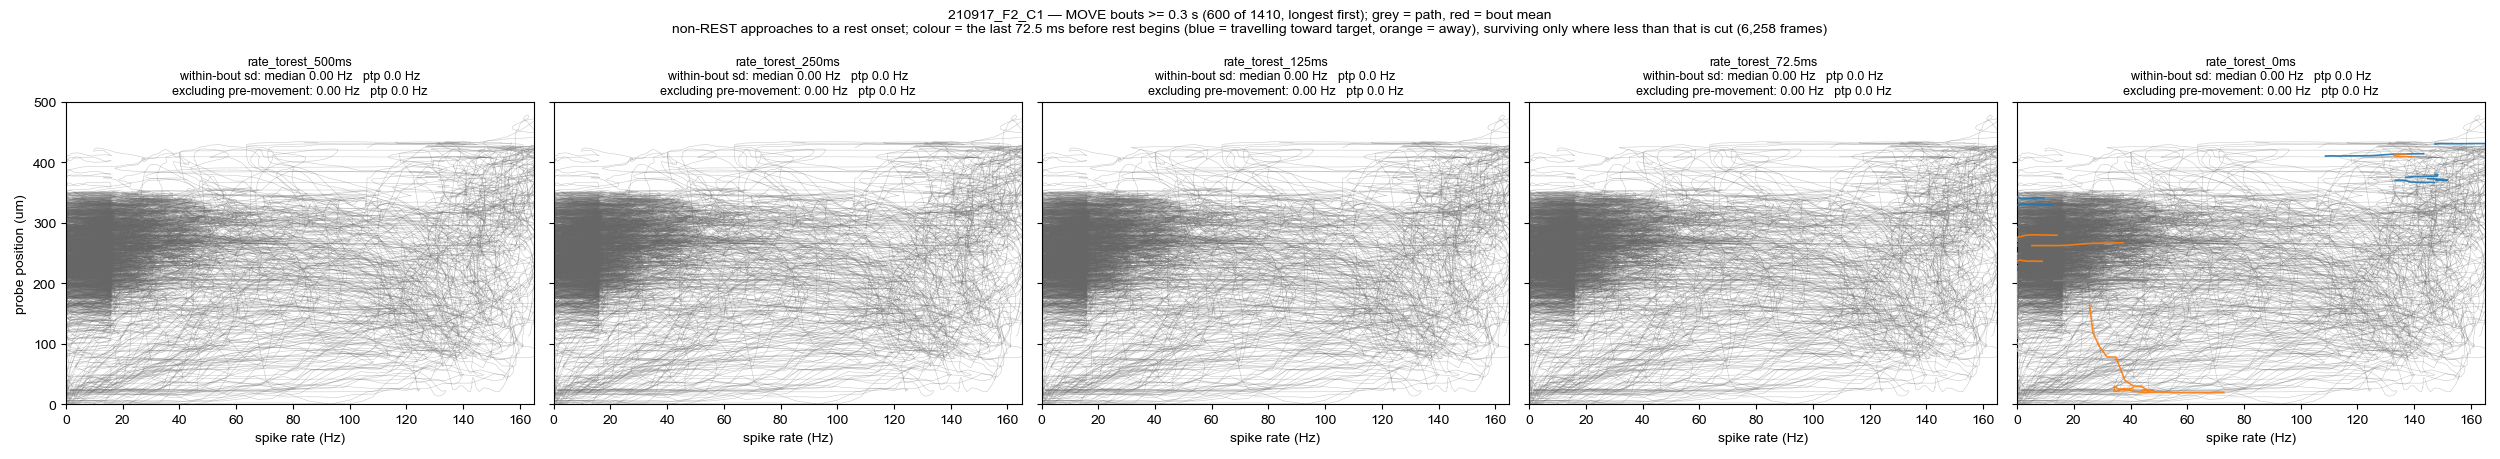

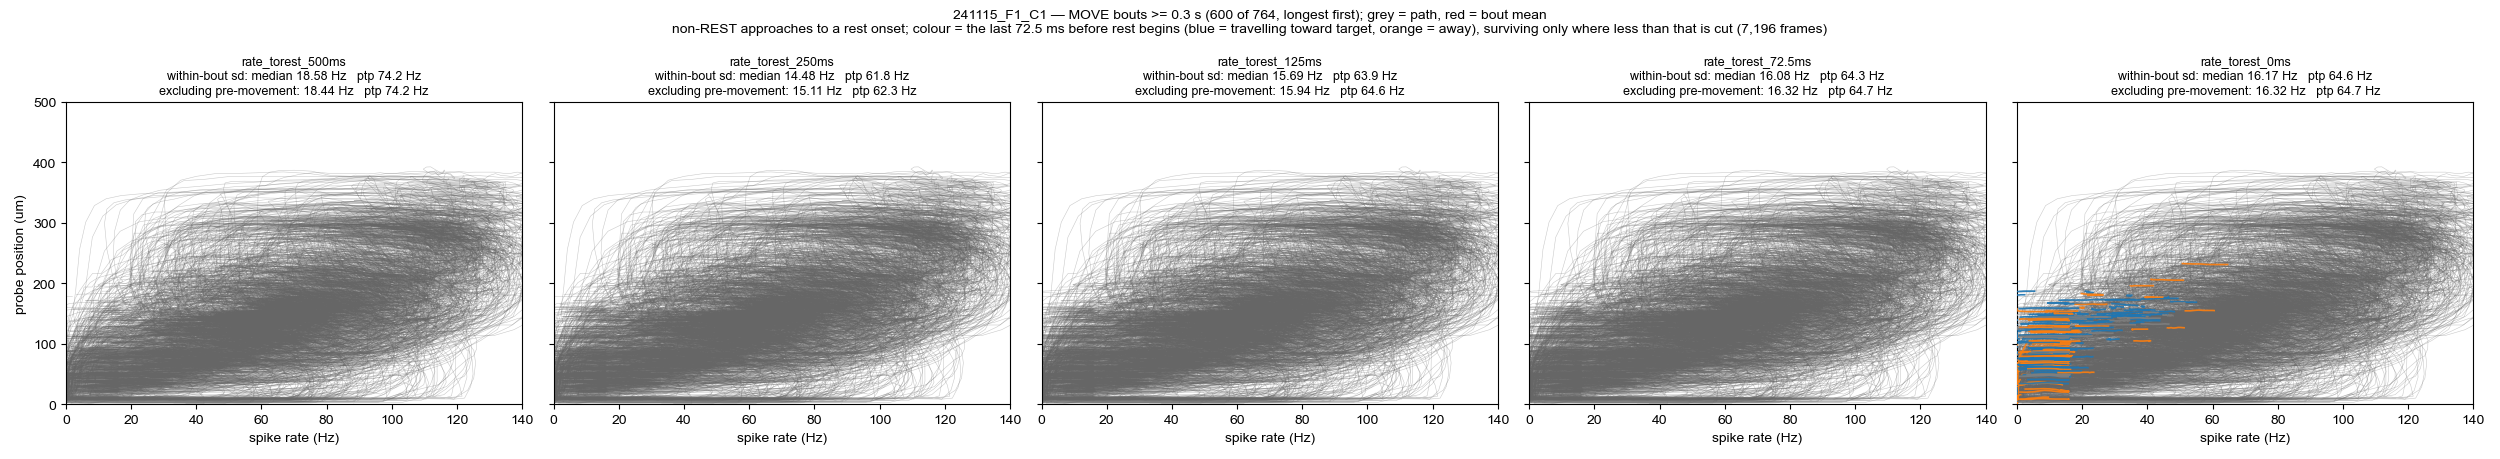

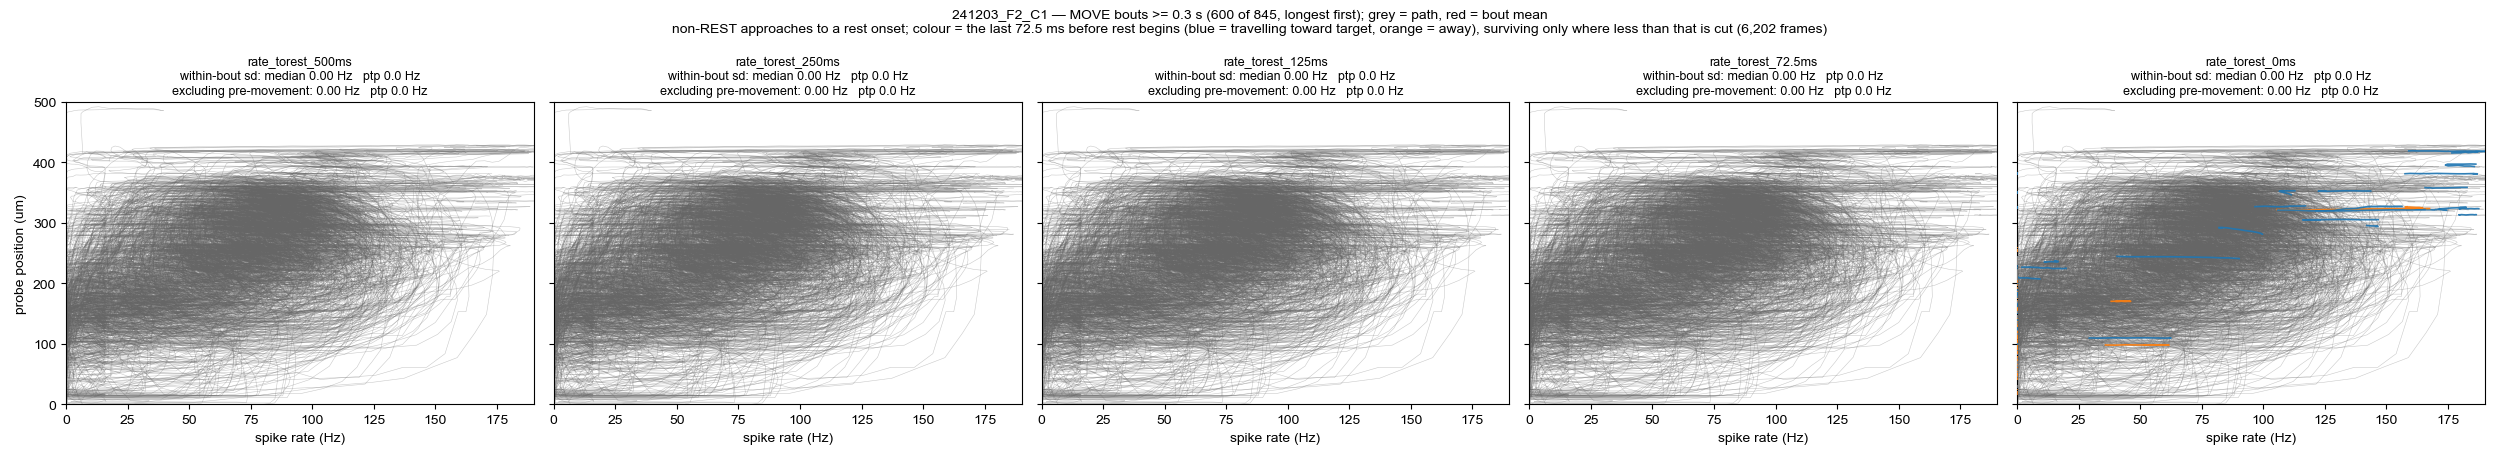

In [33]:
# [A4-PATHS-4]
# ============================================================================
# The approach TO rest: exclude a shrinking window before the rest onset
# ============================================================================
# You are right that PATHS4_STATE = STATE_DRIFT was not it -- that re-runs the
# whole analysis on drift epochs, it does not change the reference point. What
# was missing is a clock that counts DOWN to the rest onset, the way t_to_move
# counts down to the movement onset. add_movement_timing does not provide one:
# t_since_move counts UP from the end of the previous non-REST stretch, so it
# labels the rest that has already begun, not the approach to it.
#
# t_to_rest, added here, is the mirror of t_to_move. The frames it describes are
# the ones BEFORE rest begins -- the drift and the movement running into it,
# which is where you see the cell stop firing.
#
# TWO CONSTRUCTION NOTES, both of which change what the panels mean:
#
# 1. WHAT COUNTS AS A BOUT HERE. plot_rate_vs_position_kernels splits bouts on a
#    single state value, so to draw each maximal NON-REST stretch as one path
#    the state column is remapped for the plot only: REST stays REST, and DRIFT
#    and MOVE are both mapped to MOVE. That makes the drawn epochs exactly the
#    "movements" add_movement_timing keys on -- drift included, which is the
#    point -- instead of splitting each approach at every DRIFT/MOVE boundary.
#    The remap touches a copy; prep_a4[cid]['rec'] keeps its real states.
#
# 2. cur_dx_net is the net displacement of the stretch a frame is IN, not of the
#    next or previous one, so the colour says which way the probe was travelling
#    on this approach. next_dx_init would name the movement after the coming
#    rest, which is not what is being drawn.
#
# The kernel leak from A4-PATHS-3 applies unchanged: a frame surviving the blank
# still carries +/-75 ms of Gaussian, so a residual bump is not a spike in the
# surviving window. spikes_left is the arbiter.

PATHS4_HIGHLIGHT_S = 0.0725     # colour the last 72.5 ms before rest begins
PATHS4_MIN_S = 0.30             # approaches are short; the 1 s REST floor would
                                # discard nearly all of them


def add_rest_entry_timing(rec, min_move_ptp=MOVE_ONSET_PTP,
                          out_to='t_to_rest', out_dx='cur_dx_net'):
    """Time until the next REST onset, and the current stretch's net travel.

    ``t_to_rest`` is +inf where no later rest exists in the trial, so a plain
    ``<= w`` test picks out only genuine approach frames. Inside a rest bout it
    refers to the NEXT bout, which is meaningless but harmless -- those frames
    are not drawn.
    """
    t_to = np.full(len(rec), np.inf)
    dx = np.full(len(rec), np.nan)
    pos = np.arange(len(rec))
    for _, g in rec.groupby('trial', sort=False):
        idx = pos[rec.index.get_indexer(g.index)]
        t = g['t'].to_numpy(dtype=float)
        x = g['x'].to_numpy(dtype=float)
        is_rest = g['state'].to_numpy() == ba.kin.STATE_REST
        if len(t) < 2:
            continue
        d = np.diff(np.concatenate([[0], is_rest.astype(np.int8), [0]]))
        starts = np.where(d == 1)[0]
        if len(starts):
            onsets = t[starts]
            j = np.searchsorted(onsets, t, side='left')   # first onset at/after t
            has = j < len(onsets)
            v = np.full(len(t), np.inf)
            v[has] = onsets[j[has]] - t[has]
            t_to[idx] = v
        for a, b, val in ba._rle_states(~is_rest):
            if not val:
                continue
            if min_move_ptp and np.ptp(x[a:b]) < min_move_ptp:
                continue
            dx[idx[a:b]] = x[b - 1] - x[a]
    out = rec.copy()
    out[out_to] = t_to
    out[out_dx] = dx
    return out


paths4_a4, paths4_rows = {}, []
for cid in A4_CELLS:
    p = prep_a4[cid]
    rec = p['rec']
    if 't_to_rest' not in rec.columns:
        rec = add_rest_entry_timing(rec)
        prep_a4[cid]['rec'] = rec
        rest_results[cid]['records'] = rec

    rec_p, cols = excluded_rate_columns(
        rec, base_drop=p['cue'] | p['istep'],
        timing_col='t_to_rest', prefix='rate_torest')
    is_rest = rec['state'].to_numpy() == ba.kin.STATE_REST
    rec_p = rec_p.assign(
        _entry=rec['t_to_rest'].to_numpy(dtype=float) <= PATHS4_HIGHLIGHT_S,
        # remap for the plot only: every non-REST frame becomes one run
        state=np.where(is_rest, ba.kin.STATE_REST, ba.kin.STATE_MOVE))

    finite = rec_p[cols[-1]].to_numpy(dtype=float)
    finite = finite[np.isfinite(finite)]
    hi = float(np.nanpercentile(finite, 99.9)) if len(finite) else 10.0
    xlim = (0, max(np.ceil(hi / 5) * 5, 10.0))

    out = plot_rate_vs_position_kernels(
        rec_p, cid, rate_cols=cols, state=ba.kin.STATE_MOVE,
        min_duration_s=PATHS4_MIN_S, max_bouts=600,
        show_paths=True, show_means=PATHS3_SHOW_MEANS,
        xlim=xlim, ylim=YLIM_A4,
        premove_s=0, fit_lines=None,
        highlight_col='_entry', highlight_sign_col='cur_dx_net',
        highlight_colors=DIRECTION_COLORS,
        highlight_label=(f'non-REST approaches to a rest onset; colour = the '
                         f'last {PATHS4_HIGHLIGHT_S * 1e3:.1f} ms before rest '
                         f'begins (blue = travelling toward target, orange = '
                         f'away), surviving only where less than that is cut'),
        sinq=sinq, fname_tag='A4-PATHS-4')
    paths4_a4[cid] = out

    ttr = rec['t_to_rest'].to_numpy(dtype=float)
    n_sp = np.nan_to_num(rec['n_sp'].to_numpy(dtype=float))
    approach = ~is_rest & ~p['cue'] & ~p['istep'] & np.isfinite(ttr)
    dt = float(np.median(np.diff(rec['t'].to_numpy(dtype=float)[:50])))
    total = n_sp[approach].sum()
    for w in EXCLUDE_S:
        surv = approach & (ttr > w)
        paths4_rows.append({
            'cell': cid, 'exclude_ms': w * 1e3,
            'approach_s_left': float(surv.sum() * dt),
            'spikes_left': float(n_sp[surv].sum()),
            'frac_spikes_left': (float(n_sp[surv].sum() / total)
                                 if total else np.nan),
            'hz_left': (float(n_sp[surv].sum() / (surv.sum() * dt))
                        if surv.any() else np.nan),
            'max_rate_left': (float(np.nanmax(
                np.where(surv, rec[RATE_COL_A4].to_numpy(dtype=float), np.nan)))
                if surv.any() else np.nan)})

paths4_tbl = pd.DataFrame(paths4_rows)
print('Spikes surviving each exclusion measured BACKWARD from the rest onset,')
print('over non-REST approach frames (drift + movement).')
print('frac_spikes_left falling toward 0 as the excluded window grows means the')
print('firing is concentrated in the final approach -- the cell shutting off as')
print('the probe settles. Flat means it fires throughout the movement instead.')
display(paths4_tbl.pivot(index='cell', columns='exclude_ms',
                         values=['frac_spikes_left', 'spikes_left',
                                 'hz_left', 'max_rate_left']).round(3))

# Both clocks side by side: away from the coming movement (PATHS-3, inside
# REST) and away from the coming rest (PATHS-4, inside the approach).
both = pd.concat([paths3_tbl.assign(edge='rest, to next move'),
                  paths4_tbl.assign(edge='approach, to rest onset')],
                 ignore_index=True)
print('\nFraction of that window\'s spikes surviving each exclusion:')
display(both.pivot_table(index=['cell', 'edge'], columns='exclude_ms',
                         values='frac_spikes_left').round(3))

241115_F1_C1: 3,681 REST frames within 50 ms of a movement (18.4 s, 0.4% of usable REST)
   they hold 160 of 2879 REST spikes (5.6%), i.e. 8.69 Hz inside the window vs 0.65 Hz outside
   795 bouts drawn; per-bout mean rate: median 0.00 Hz, p90 1.63 Hz


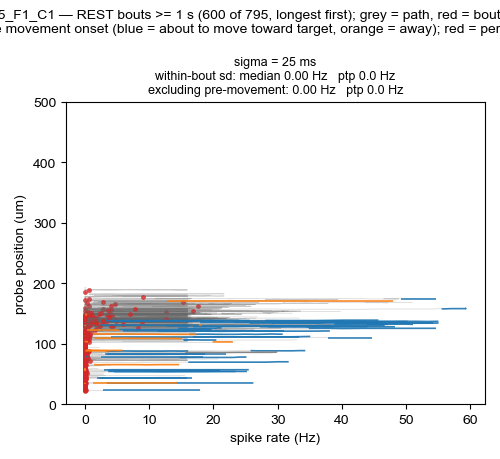

In [34]:
# [A4-PATHS-5]
# ============================================================================
# One cell, one panel: REST paths with the final 50 ms before movement marked
# ============================================================================
# The A4-PATHS-3 sweep asks when the firing appears as the excluded window
# shrinks. This is the single-panel version of the same figure for one cell:
# nothing excluded, the last 50 ms before a movement onset coloured, and the
# per-bout mean rate back on as the red dots (show_means=True).
#
# 50 ms is BELOW the kernel's own support -- one spike through the 25 ms
# Gaussian spans +/-75 ms -- so a highlighted stretch necessarily carries the
# tails of spikes on either side of it. It marks where to look; it does not
# isolate 50 ms of firing. A4-PATHS-3's spikes_left column is the arbiter for
# what is actually inside a window.
#
# The red dots are means over each bout's SURVIVING frames (cue and current
# step are still blanked), so a bout whose only spikes were in the cue shows a
# mean of zero rather than being dropped.

PATHS5_CELL = '241115_F1_C1'
PATHS5_HIGHLIGHT_S = 0.050
PATHS5_XLIM = None            # e.g. (0, 60) to pin the rate axis

if PATHS5_CELL not in A4_CELLS:
    print(f'{PATHS5_CELL} is not in A4_CELLS -- nothing drawn')
else:
    p = prep_a4[PATHS5_CELL]
    rec = p['rec']
    t2m = rec['t_to_move'].to_numpy(dtype=float)
    rec5 = _blank_a4(rec.assign(_last50=t2m <= PATHS5_HIGHLIGHT_S),
                     RATE_COL_A4, p['cue'] | p['istep'])

    fig5, spread5 = plot_rate_vs_position_kernels(
        rec5, PATHS5_CELL, sigmas_s=(SIGMA_A4,), state=ba.kin.STATE_REST,
        min_duration_s=MIN_BOUT_A4, max_bouts=600,
        show_paths=True, show_means=True,          # the red per-bout means
        xlim=PATHS5_XLIM, ylim=YLIM_A4,
        premove_s=0, fit_lines=None,
        highlight_col='_last50', highlight_sign_col='next_dx_init',
        highlight_colors=DIRECTION_COLORS,
        highlight_label=(f'colour = the last {PATHS5_HIGHLIGHT_S * 1e3:.0f} ms '
                         f'before movement onset (blue = about to move toward '
                         f'target, orange = away); red = per-bout mean rate'),
        sinq=sinq, fname_tag='A4-PATHS-5')

    is_rest = rec['state'].to_numpy() == ba.kin.STATE_REST
    keep = is_rest & ~p['cue'] & ~p['istep']
    hl = keep & (t2m <= PATHS5_HIGHLIGHT_S)
    n_sp = np.nan_to_num(rec['n_sp'].to_numpy(dtype=float))
    dt = float(np.median(np.diff(rec['t'].to_numpy(dtype=float)[:50])))
    print(f'{PATHS5_CELL}: {int(hl.sum()):,} REST frames within '
          f'{PATHS5_HIGHLIGHT_S*1e3:.0f} ms of a movement '
          f'({hl.sum()*dt:.1f} s, {100*hl.sum()/max(keep.sum(),1):.1f}% of usable REST)')
    print(f'   they hold {n_sp[hl].sum():.0f} of {n_sp[keep].sum():.0f} REST spikes '
          f'({100*n_sp[hl].sum()/max(n_sp[keep].sum(),1):.1f}%), i.e. '
          f'{n_sp[hl].sum()/max(hl.sum()*dt,1e-9):.2f} Hz inside the window vs '
          f'{(n_sp[keep].sum()-n_sp[hl].sum())/max((keep.sum()-hl.sum())*dt,1e-9):.2f} Hz outside')
    if len(spread5):
        s5 = spread5[spread5['rate_col'] == RATE_COL_A4]
        print(f'   {len(s5)} bouts drawn; per-bout mean rate: median '
              f'{s5["rate_mean"].median():.2f} Hz, p90 '
              f'{s5["rate_mean"].quantile(0.9):.2f} Hz')

Per-bout mean rate (Hz), last 72.5 ms of each bout excluded:


,bouts,median,p90,max,median_x
cell,,,,,
210917_F2_C1,550,0.0,0.000,0.575,187.329
241115_F1_C1,785,0.0,1.428,20.773,83.992
241203_F2_C1,801,0.0,0.000,145.297,135.370



mean_rate_zero: bouts whose smoothed rate never left zero after the cut.
no_spikes: bouts with no spike in the surviving frames. no_spikes >=
mean_rate_zero, the gap being bouts reached only by the kernel tail of a
spike just outside them -- including one inside the excluded window,
since 72.5 ms is inside the kernel's +/-75 ms support.
zero_whole / bouts_whole are the same counts WITHOUT the exclusion
(from bouts_a4, A4-SPIKING-1) -- the rise is what the run-up was adding.


,bouts,mean_rate_zero,frac_mean_rate_zero,no_spikes,frac_no_spikes,rest_s_after_cut,bouts_whole,zero_whole
cell,,,,,,,,
210917_F2_C1,550,547,0.995,548,0.996,1090.029,550,547
241115_F1_C1,785,520,0.662,626,0.797,3940.237,788,513
241203_F2_C1,801,796,0.994,797,0.995,2917.661,805,795


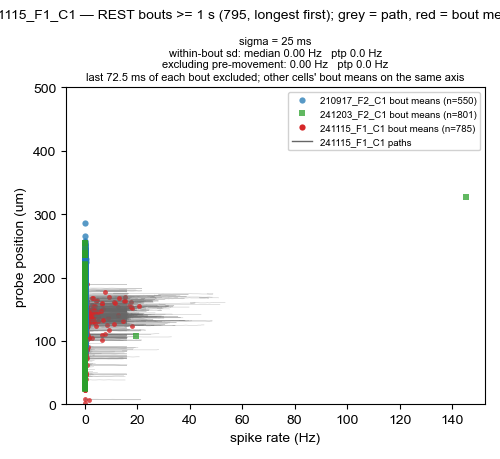

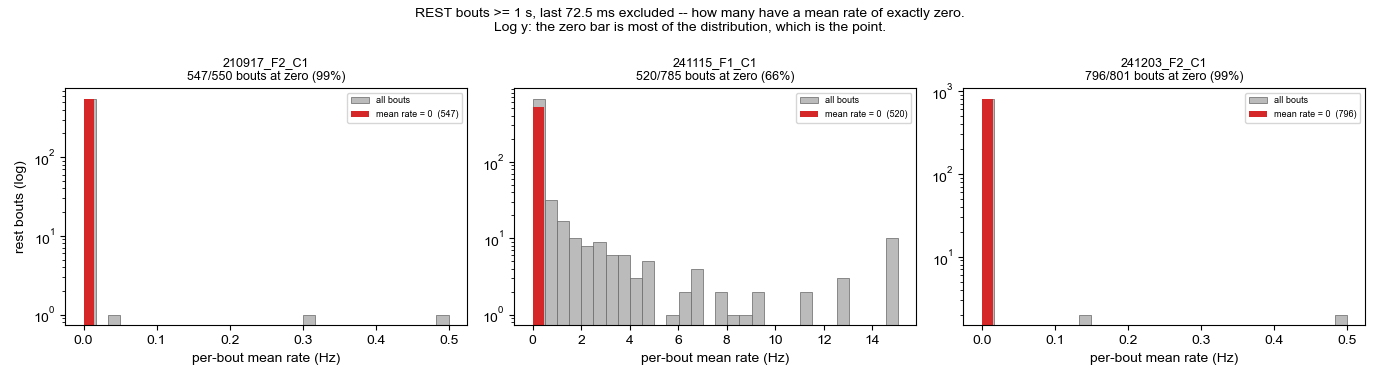

In [36]:
# [A4-ZERO-1]
# ============================================================================
# The headline: the per-bout rate is zero, and it is zero in all three cells
# ============================================================================
# Two figures, one claim.
#
# 1. ONE AXIS, ALL THREE CELLS. The grey paths and red per-bout means are the
#    reference cell's (241115, the only one with enough spikes to draw a path),
#    and the other cells' per-bout means are dropped onto the SAME axis. If the
#    A4 story is "these cells do not fire during rest", the other cells' points
#    have to sit where the red ones do -- at zero -- rather than off the panel.
#
# 2. HOW MANY BOUTS ARE EXACTLY ZERO, per cell. A histogram of the per-bout mean
#    rate with the zero bin called out, because that is the number the claim
#    rests on and a histogram alone hides it inside the first bar.
#
# ZERO_EXCLUDE_S DROPS THE END OF EACH BOUT before averaging. This is the point
# of the figure rather than a detail: what firing there is during "rest" is the
# run-up to the next movement (A4-RUNUP-DOC), and on 241115 the within-bout
# scatter collapses from 1.34 Hz to 0.02 Hz once that window is removed. A bout
# mean taken over the whole bout is therefore a mean over rest PLUS the start of
# the next movement. Excluding the last 72.5 ms asks the cleaner question: with
# the motor command taken out, is the cell doing anything at all during rest?
#
# Set ZERO_EXCLUDE_S = 0.0 to recover the whole-bout version; the window is in
# the filenames, so both can sit side by side on disk.
#
# TWO CONSEQUENCES OF EXCLUDING, both reported below rather than assumed:
#   * a bout whose USABLE time falls under MIN_BOUT_A4 after the cut is dropped
#     by rest_bout_spiking's own duration gate, so the bout count can fall;
#   * 72.5 ms is inside the kernel's +/-75 ms support, so a spike in the excluded
#     window still leaks its tail into the frames that survive. rate_mean can
#     stay nonzero where the surviving spike COUNT is zero -- which is exactly
#     the gap between the two columns in the table.
#
# WHICH "AVERAGE RATE": rate_mean from rest_bout_spiking -- the mean of the
# 25 ms smoothed rate over the bout's SURVIVING frames, the same quantity the
# red dots plot, so the two figures agree by construction.

ZERO_EXCLUDE_S = 0.0725       # last N s before movement onset, cut from the bout
ZERO_REF_CELL = '241115_F1_C1'
ZERO_TOL_HZ = 1e-9
ZERO_MARKERS = {'210917_F2_C1': ('o', '#1f77b4'),
                '241115_F1_C1': ('o', '#d62728'),
                '241203_F2_C1': ('s', '#2ca02c')}
_ms = f'{ZERO_EXCLUDE_S * 1e3:g}ms'


def zero_drop(cid):
    """cue + current step + the last ZERO_EXCLUDE_S of every rest bout."""
    p = prep_a4[cid]
    d = p['cue'] | p['istep']
    if ZERO_EXCLUDE_S:
        d = d | (p['rec']['t_to_move'].to_numpy(dtype=float) <= ZERO_EXCLUDE_S)
    return d


# Recompute the bout table with those frames gone. rest_bout_spiking already
# takes a drop mask and honours it in rate_mean, n_spikes and usable_s alike.
bouts_zero = []
for cid in A4_CELLS:
    b, _ = rest_bout_spiking(prep_a4[cid]['rec'], drop=zero_drop(cid))
    b['cell'] = cid
    bouts_zero.append(b)
bouts_zero = pd.concat(bouts_zero, ignore_index=True)

# ---- figure 1: paths for the reference cell, bout means for everyone --------
p = prep_a4[ZERO_REF_CELL]
fig_z, spread_z = plot_rate_vs_position_kernels(
    _blank_a4(p['rec'], RATE_COL_A4, zero_drop(ZERO_REF_CELL)), ZERO_REF_CELL,
    sigmas_s=(SIGMA_A4,), state=ba.kin.STATE_REST,
    min_duration_s=MIN_BOUT_A4, max_bouts=2000,
    show_paths=True, show_means=True,
    xlim=None, ylim=YLIM_A4,
    premove_s=0, fit_lines=None,
    sinq=sinq, fname_tag=f'A4-ZERO-1_paths_excl{_ms}')

ax = fig_z.axes[0]
for cid in A4_CELLS:
    if cid == ZERO_REF_CELL:
        continue
    d = bouts_zero[bouts_zero['cell'] == cid]
    if not len(d):
        continue
    m, c = ZERO_MARKERS.get(cid, ('^', '#9467bd'))
    ax.plot(d['rate_mean'], d['x_mean'], m, ms=4.5, mew=0, alpha=0.75,
            color=c, label=f'{cid} bout means (n={len(d)})', zorder=6)
ref = bouts_zero[bouts_zero['cell'] == ZERO_REF_CELL]
ax.plot([], [], 'o', ms=4.5, mew=0, color='#d62728',
        label=f'{ZERO_REF_CELL} bout means (n={len(ref)})')
ax.plot([], [], '-', lw=1.0, color='#666666', label=f'{ZERO_REF_CELL} paths')
ax.legend(fontsize=7, loc='upper right', framealpha=0.9)
ax.set_title(ax.get_title() + f'\nlast {ZERO_EXCLUDE_S*1e3:g} ms of each bout '
             f'excluded; other cells\' bout means on the same axis', fontsize=8)
save_fig(fig_z, 'A4-ZERO-1', suffix=f'overlay_excl{_ms}')

print(f'Per-bout mean rate (Hz), last {ZERO_EXCLUDE_S*1e3:g} ms of each bout excluded:')
display(bouts_zero.groupby('cell').agg(
    bouts=('rate_mean', 'size'),
    median=('rate_mean', 'median'),
    p90=('rate_mean', lambda s: s.quantile(0.9)),
    max=('rate_mean', 'max'),
    median_x=('x_mean', 'median')).round(3))

# ---- figure 2: how many bouts are exactly zero ------------------------------
cells_z = [c for c in A4_CELLS if (bouts_zero['cell'] == c).any()]
fig_h, axes_h = plt.subplots(1, len(cells_z), figsize=(4.6 * len(cells_z), 3.8),
                             squeeze=False)
zero_rows = []
for i, cid in enumerate(cells_z):
    d = bouts_zero[bouts_zero['cell'] == cid]
    v = d['rate_mean'].to_numpy(dtype=float)
    v = v[np.isfinite(v)]
    n_zero = int((np.abs(v) <= ZERO_TOL_HZ).sum())
    n_nospike = int((d['n_spikes'] == 0).sum())
    axm = axes_h[0, i]
    hi = max(float(np.nanpercentile(v, 99)) if len(v) else 1.0, 0.5)
    bins = np.linspace(0, hi, 31)
    axm.hist(np.clip(v, 0, hi), bins=bins, color='#bbbbbb',
             edgecolor='#666666', lw=0.5, label='all bouts')
    axm.bar([0], [n_zero], width=(bins[1] - bins[0]) * 0.9, align='edge',
            color='#d62728', label=f'mean rate = 0  ({n_zero})')
    axm.set_yscale('log')
    axm.set_xlabel('per-bout mean rate (Hz)')
    if i == 0:
        axm.set_ylabel('rest bouts (log)')
    axm.set_title(f'{cid}\n{n_zero}/{len(d)} bouts at zero '
                  f'({100 * n_zero / max(len(d), 1):.0f}%)', fontsize=9)
    axm.legend(fontsize=6.5)
    # the same counts WITHOUT the exclusion, for the comparison line below
    b0 = bouts_a4[bouts_a4['cell'] == cid] if 'bouts_a4' in dir() else d.iloc[:0]
    z0 = int((np.abs(b0['rate_mean'].to_numpy(dtype=float)) <= ZERO_TOL_HZ).sum()) \
        if len(b0) else np.nan
    zero_rows.append({'cell': cid, 'bouts': len(d),
                      'mean_rate_zero': n_zero,
                      'frac_mean_rate_zero': n_zero / max(len(d), 1),
                      'no_spikes': n_nospike,
                      'frac_no_spikes': n_nospike / max(len(d), 1),
                      'rest_s_after_cut': float(d['usable_s'].sum()),
                      'bouts_whole': (len(b0) if len(b0) else np.nan),
                      'zero_whole': z0})
fig_h.suptitle(f'REST bouts >= {MIN_BOUT_A4:g} s, last {ZERO_EXCLUDE_S*1e3:g} ms '
               f'excluded -- how many have a mean rate of exactly zero.\n'
               f'Log y: the zero bar is most of the distribution, which is the '
               f'point.', fontsize=10)
fig_h.tight_layout()
save_fig(fig_h, 'A4-ZERO-1', suffix=f'hist_excl{_ms}')

zero_tbl = pd.DataFrame(zero_rows).set_index('cell')
print(f'\nmean_rate_zero: bouts whose smoothed rate never left zero after the cut.')
print(f'no_spikes: bouts with no spike in the surviving frames. no_spikes >=')
print(f'mean_rate_zero, the gap being bouts reached only by the kernel tail of a')
print(f'spike just outside them -- including one inside the excluded window,')
print(f'since {ZERO_EXCLUDE_S*1e3:g} ms is inside the kernel\'s +/-75 ms support.')
print(f'zero_whole / bouts_whole are the same counts WITHOUT the exclusion')
print(f'(from bouts_a4, A4-SPIKING-1) -- the rise is what the run-up was adding.')
display(zero_tbl.round(3))

In [ ]:
# [A4-QUIT-1]
# ============================================================================
# A4 -- example bouts where the cell stops firing as the rest begins
# ============================================================================
# The edge-aligned curves are an average. This picks individual bouts that show
# the effect, so it can be looked at rather than inferred, and prints the trial
# and time span of each so any of them can be opened in the trial browser.
#
# Selection is on TIMING, not on the rate: a bout qualifies if its spikes are
# concentrated early and it then falls silent for the rest of its duration --
# n_spikes >= QUIT_MIN_SPIKES, last spike before QUIT_LAST_FRAC of the way in,
# and a trailing silence of at least QUIT_SILENCE_S. Ranking is by how long the
# cell stayed quiet afterwards, so the clearest cases come first. Nothing here
# thresholds the firing rate itself, which would make the finding circular.

QUIT_MIN_SPIKES = 4
QUIT_LAST_FRAC = 0.35
QUIT_SILENCE_S = 1.5
QUIT_PAD_S = 0.75        # context drawn either side of the bout
N_EXAMPLES = 3

q = bouts_a4[(bouts_a4['n_spikes'] >= QUIT_MIN_SPIKES)
             & (bouts_a4['last_spike_frac'] <= QUIT_LAST_FRAC)].copy()
q['silence_after_s'] = (1.0 - q['last_spike_frac']) * q['duration']
q = q[q['silence_after_s'] >= QUIT_SILENCE_S]
q = q.sort_values('silence_after_s', ascending=False)

print(f'{len(q)} bouts quit early, of '
      f'{int((bouts_a4["n_spikes"] >= QUIT_MIN_SPIKES).sum())} with at least '
      f'{QUIT_MIN_SPIKES} spikes')
display(q.groupby('cell').agg(
    quit_bouts=('duration', 'size'),
    median_silence_after_s=('silence_after_s', 'median'),
    median_spikes=('n_spikes', 'median')).round(2))
display(q[['cell', 'trial', 'epoch', 't_start', 't_end', 'duration',
           'n_spikes', 'rate_hz', 'first_spike_frac', 'last_spike_frac',
           'silence_after_s', 'x_mean']].head(12).round(3))

# Draw the top examples per cell. plot_trial_records shows position, rate and Vm
# on one clock, so the silence can be read against what the probe was doing.
quit_examples = {}
for cid in A4_CELLS:
    sel = q[q['cell'] == cid].head(N_EXAMPLES)
    if not len(sel):
        print(f'{cid}: no bout meets the criteria')
        continue
    rec = prep_a4[cid]['rec']
    for _, row in sel.iterrows():
        tn = int(row['trial'])
        fig = plot_trial_records(
            rec, cell_id=cid, trial=tn,
            t_range=(row['t_start'] - QUIT_PAD_S, row['t_end'] + QUIT_PAD_S),
            premove_s=PREMOVE_A4, sinq=sinq,
            fname_prefix='A4-QUIT-1',
            tag=f'e{int(row["epoch"])}')
        quit_examples[(cid, tn, int(row['epoch']))] = fig
        print(f'{cid} trial {tn} epoch {int(row["epoch"])}: '
              f'{row["n_spikes"]:.0f} spikes, last at '
              f'{row["last_spike_frac"]:.2f} of a {row["duration"]:.1f} s bout, '
              f'then {row["silence_after_s"]:.1f} s silent '
              f'(t = {row["t_start"]:.2f}..{row["t_end"]:.2f} s)')

In [ ]:
# [A4-QUIT-2]
# ============================================================================
# Does the cell routinely go silent as the probe settles?  And is that a
# finding, or is it our criteria?
# ============================================================================
# The observation is that examples like 241115_F1_C1 trial 465 -- the neuron
# falling silent as the probe drops back toward the target -- seem rare. Two
# things could make them rare, and they demand different responses:
#
#   (a) the cell genuinely stops firing before rest only occasionally;
#   (b) the SEARCH is narrow. A4-QUIT-1 looked inside REST bouts, which by
#       construction begins after the probe has already settled, so a cell that
#       shuts off during the approach and is silent by rest onset contributes
#       nothing to it. The approach itself was never searched.
#
# This searches the approach, using t_to_rest from A4-PATHS-4. The statistic
# that needs no threshold at all is `t_last_spike_to_rest_ms`: for every
# approach that contains a spike, how long before rest onset its LAST spike
# fell. Its distribution answers "does this normally happen" directly, and a
# grid of (min_spikes, min_silence) counts is printed beneath it so the effect
# of the criteria is visible rather than argued about.
#
# Approaches are the maximal non-REST stretches with a finite t_to_rest, i.e.
# ones that actually end in a rest -- drift included, since the drift is where
# the shutting-off is seen.

QUIT2_WINDOW_S = 0.500      # how far back from rest onset to look
QUIT2_MIN_SPIKES = 2
QUIT2_MIN_SILENCE_S = 0.100


def approach_epochs(rec, min_move_ptp=MOVE_ONSET_PTP, drop=None,
                    count_col='n_sp'):
    """One row per non-REST stretch that ends in a rest onset."""
    drop = (np.zeros(len(rec), dtype=bool) if drop is None
            else np.asarray(drop, dtype=bool))
    rows = []
    pos = np.arange(len(rec))
    for tn, g in rec.groupby('trial', sort=True):
        idx = pos[rec.index.get_indexer(g.index)]
        t = g['t'].to_numpy(dtype=float)
        x = g['x'].to_numpy(dtype=float)
        ttr = g['t_to_rest'].to_numpy(dtype=float)
        n = np.nan_to_num(g[count_col].to_numpy(dtype=float))
        n = np.where(drop[idx], 0.0, n)
        is_rest = g['state'].to_numpy() == ba.kin.STATE_REST
        if len(t) < 3:
            continue
        dt = float(np.median(np.diff(t)))
        for a, b, val in ba._rle_states(~is_rest):
            if not val or not np.isfinite(ttr[a:b]).any():
                continue
            if min_move_ptp and np.ptp(x[a:b]) < min_move_ptp:
                continue
            k = n[a:b]
            spikes = float(k.sum())
            # t_to_rest at each spike; the LAST spike is the smallest value
            tt = np.repeat(ttr[a:b], k.astype(int))
            rows.append({
                'trial': tn, 'start': float(t[a]), 'end': float(t[b - 1]),
                'duration': (b - a) * dt, 'dx_net': float(x[b - 1] - x[a]),
                'n_spikes': spikes,
                'n_spikes_in_window': float(k[ttr[a:b] <= QUIT2_WINDOW_S].sum()),
                't_last_spike_to_rest_ms': (float(np.min(tt)) * 1e3
                                            if len(tt) else np.nan),
                't_first_spike_to_rest_ms': (float(np.max(tt)) * 1e3
                                             if len(tt) else np.nan)})
    return pd.DataFrame(rows, columns=[
        'trial', 'start', 'end', 'duration', 'dx_net', 'n_spikes',
        'n_spikes_in_window', 't_last_spike_to_rest_ms',
        't_first_spike_to_rest_ms'])


appr_a4 = {}
for cid in A4_CELLS:
    p = prep_a4[cid]
    rec = p['rec']
    if 't_to_rest' not in rec.columns:
        rec = add_rest_entry_timing(rec)
        prep_a4[cid]['rec'] = rec
        rest_results[cid]['records'] = rec
    d = approach_epochs(rec, drop=p['cue'] | p['istep'])
    d['cell'] = cid
    appr_a4[cid] = d
approaches_a4 = pd.concat(appr_a4.values(), ignore_index=True)

spiking = approaches_a4[approaches_a4['n_spikes'] > 0]
print(f'{len(approaches_a4)} approaches to a rest onset, '
      f'{len(spiking)} of them containing at least one spike.')
display(approaches_a4.groupby('cell').agg(
    approaches=('duration', 'size'),
    with_spikes=('n_spikes', lambda s: int((s > 0).sum())),
    median_spikes_when_spiking=('n_spikes',
                                lambda s: float(s[s > 0].median())
                                if (s > 0).any() else np.nan),
    median_last_spike_ms=('t_last_spike_to_rest_ms', 'median')).round(2))

# --- the threshold-free view -----------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
bins = np.linspace(0, QUIT2_WINDOW_S * 1e3, 41)
for cid in A4_CELLS:
    v = spiking.loc[spiking['cell'] == cid, 't_last_spike_to_rest_ms']
    v = v[np.isfinite(v)]
    if not len(v):
        continue
    axes[0].hist(np.clip(v, 0, QUIT2_WINDOW_S * 1e3), bins=bins,
                 histtype='step', lw=1.5, label=f'{cid}  n={len(v)}')
    axes[1].hist(np.clip(v, 0, QUIT2_WINDOW_S * 1e3), bins=bins,
                 histtype='step', lw=1.5, cumulative=True, density=True,
                 label=cid)
axes[0].set_xlabel('last spike -> rest onset (ms)')
axes[0].set_ylabel('approaches')
axes[0].set_title('when the firing stops, relative to settling', fontsize=9)
axes[0].legend(fontsize=7)
axes[1].set_xlabel('last spike -> rest onset (ms)')
axes[1].set_ylabel('cumulative fraction')
axes[1].set_title('a mass at large values = routinely silent before rest',
                  fontsize=9)
axes[1].legend(fontsize=7)
fig.suptitle(f'Approaches containing spikes, window {QUIT2_WINDOW_S*1e3:.0f} ms.'
             f' Bunched near 0 means the cell fires right up to the settle;\n'
             f'spread to the right means it shuts off first -- the effect seen '
             f'in 241115_F1_C1 trial 465.', fontsize=10)
fig.tight_layout()
save_fig(fig, 'A4-QUIT-2', suffix='last_spike')

# --- is it the criteria? ----------------------------------------------------
grid = []
for ms in (1, 2, 3, 5):
    for sil in (0.050, 0.100, 0.200, 0.300):
        for cid in A4_CELLS:
            d = appr_a4[cid]
            q = d[(d['n_spikes'] >= ms)
                  & (d['t_last_spike_to_rest_ms'] >= sil * 1e3)]
            grid.append({'cell': cid, 'min_spikes': ms,
                         'min_silence_ms': sil * 1e3, 'n': len(q)})
grid = pd.DataFrame(grid)
print('\nQualifying approaches under each criterion -- how much of "we do not '
      'have\nmany examples" is the threshold rather than the cell:')
display(grid.pivot_table(index=['cell', 'min_spikes'],
                         columns='min_silence_ms', values='n'))

# --- candidates to look at --------------------------------------------------
cands = approaches_a4[
    (approaches_a4['n_spikes'] >= QUIT2_MIN_SPIKES)
    & (approaches_a4['t_last_spike_to_rest_ms'] >= QUIT2_MIN_SILENCE_S * 1e3)
].sort_values(['n_spikes', 't_last_spike_to_rest_ms'], ascending=False)
print(f'\n{len(cands)} approaches with >= {QUIT2_MIN_SPIKES} spikes that then '
      f'go quiet for >= {QUIT2_MIN_SILENCE_S*1e3:.0f} ms before rest.')
print('Trial numbers to plot with A4-EXAMPLE-1:')
display(cands[['cell', 'trial', 'start', 'end', 'duration', 'dx_net',
               'n_spikes', 't_last_spike_to_rest_ms']].head(20).round(3))

In [ ]:
# [A4-EXAMPLE-1]
# ============================================================================
# The example figure: one trial, raw membrane potential with its spikes
# ============================================================================
# Two views of the same trial, because they answer different questions and the
# A2 figure used both:
#
#   plot_trial_records(raw_voltage=trial, spike_times=trial)
#       The analysis view -- position coloured by state, qualifying REST bouts
#       shaded, rate, and the flag strip -- with the RAW voltage drawn behind
#       the Vm trace and the raster taken from the exact spike times rather than
#       from the per-frame n_sp counts. Passing the Trial is what puts the real
#       membrane potential in the Vm channel; without it the panel shows only
#       the frame-sampled, spike-blanked vm from the records.
#
#   plot_trial_vm_overlay(trial)
#       The signal view -- raw voltage with the blanked Vm riding over it, plus
#       probe and rate. This is the one that shows whether subthreshold_vm is
#       tracking the base of the trace instead of dipping at every blanked
#       spike, so it is the honest companion whenever a Vm claim is made.
#
# Both draw the TARGET ZONE on the position panel, taken from the trial's own
# pyasXPosition / pyasWidth in the same flipped frame as x, so no conversion is
# involved. Every "toward target" statement in this notebook is relative to that
# band, and the trace cannot be read against the task without it. A trial with
# no target metadata -- the 2021 protocols may predate it -- simply gets no
# band; check the panel title, which names the bounds when they were drawn.
#
# THIS CELL RESTORES A TABLE, which is the expensive step the whole notebook is
# built to avoid -- the records carry only frame-sampled voltage, so the raw
# 50 kHz trace has to come from the file. It restores one cell, draws, and drops
# it again. Change EXAMPLE_TRIALS and re-run; each entry costs one restore.

EXAMPLE_TRIALS = {'241115_F1_C1': [126, 139, 147, 227]}
EXAMPLE_PAD_S = None          # None = whole trial; (t0, t1) to zoom
EXAMPLE_DECIMATE = 5          # raw trace decimation for drawing only

example_figs = {}
for cid, trials in EXAMPLE_TRIALS.items():
    if cid not in A4_CELLS:
        print(f'{cid} is not in A4_CELLS -- skipped')
        continue
    print(f'-- restoring {cid} (this is the slow step) --', flush=True)
    T = sinq.restore_table(dayflycell=cid)
    try:
        rec = prep_a4[cid]['rec']
        blank = rest_results[cid].get('blank')
        for tn in trials:
            if tn not in T.df.index:
                print(f'   trial {tn} is not in the table')
                continue
            trial = T.df.at[tn, 'Trial']
            if trial is None:
                print(f'   trial {tn} has no Trial object')
                continue
            if tn not in set(rec['trial']):
                # still drawable from the file, but say so: it was dropped from
                # the analysis (excluded, bad ephys, or no detected spikes), so
                # it contributes to none of the numbers elsewhere
                print(f'   NOTE trial {tn} is not in the records -- excluded '
                      f'from every analysis in this notebook')

            # x is baked into the records at build time as
            # probeZero - probe_position, while the target band is read live
            # from the Trial. If probeZero changed since the records were built
            # the two are in different frames and the band lands off the trace.
            # Re-derive x for THIS trial from the Trial's current probeZero so
            # the figure is self-consistent without a rebuild.
            rows, frame_offset = records_in_trial_frame(rec, trial, tn)
            # NaN first: it is TRUTHY, so testing `if frame_offset:` ahead of it
            # swallowed the unknown case into the "out of frame" branch and the
            # elif below was unreachable.
            if np.isnan(frame_offset):
                print(f'   trial {tn}: frame could not be checked (no records '
                      f'for it, or no usable probe data) -- nothing to draw '
                      f'from the records')
                rows = rec[rec['trial'] == tn]
            elif frame_offset:
                print(f'   *** records for {cid} are {frame_offset:+.1f} px out '
                      f'of frame: they were built on a different probeZero than '
                      f'the file now carries.')
                print(f'       This figure is corrected, but nothing else is -- '
                      f'every absolute position in the notebook for this cell '
                      f'is off by that much.')
                print(f'       Re-run stage 1 for {cid} to fix the rest.')
            if not len(rows):
                # plot_trial_records returns None on an empty frame; say why
                # rather than stashing a None in example_figs.
                print(f'   trial {tn}: no records -- skipped '
                      f'(0 detected spikes, excluded, or bad ephys)')
                continue

            f1 = plot_trial_records(
                rows, cell_id=cid, trial=tn, t_range=EXAMPLE_PAD_S,
                premove_s=PREMOVE_A4, sinq=sinq,
                raw_voltage=trial,        # real Vm in the voltage panel
                spike_times=trial,        # exact spike raster, not frame counts
                target=trial,             # target zone on the position panel
                decimate=EXAMPLE_DECIMATE,
                fname_prefix='A4-EXAMPLE-1')

            f2 = plot_trial_vm_overlay(
                trial, cell_id=cid, blank=blank, sigma_s=SIGMA_A4,
                t_range=EXAMPLE_PAD_S, decimate=EXAMPLE_DECIMATE,
                sinq=sinq, tag='A4-EXAMPLE-1')

            example_figs[(cid, tn)] = (f1, f2)
            print(f'   drew {cid} trial {tn}')
    finally:
        # always drop, even if a trial above raised -- otherwise the Table stays
        # in the Sinq and the next restore silently reuses it
        sinq.drop_tables(index=[cid])

print('\nplot_trial_records: raw voltage behind the Vm trace, raster from exact')
print('spike times. plot_trial_vm_overlay: the Vm-vs-raw check.')
print('Candidates for more examples are in A4-QUIT-2 (cands).')

In [ ]:
# [A4-EXAMPLE-2]
# ============================================================================
# The example figure: consecutive trials on one continuous clock
# ============================================================================
# A single trial often cuts an event in half -- the probe settles in one trial
# and the cell stays quiet into the next. This concatenates a SPAN of
# consecutive trials the way the analysis does it, so a rest bout that straddles
# a boundary is drawn as one bout instead of two.
#
# The concatenation is ba.trace_across_trials', not a fresh one: same
# first-junction dedup, same per-trial offsets. Those offsets are then applied
# to everything else that has its own clock -- the records, the raw voltage, the
# spike times, the target bands -- so all five land on one axis together. A
# hand-rolled offset would drift from what detect_bouts_across_trials uses.
#
# Two views per span, as before:
#   plot_trial_records(raw_voltage=..., spike_times=...)  the analysis view,
#       with the real membrane potential behind the Vm trace and the raster
#       from exact spike times rather than per-frame n_sp counts.
#   plot_trial_vm_overlay(trial)  the signal view, per trial -- it takes a
#       single Trial and recomputes from the file, so it is drawn for the first
#       trial of the span only, as the Vm-vs-raw sanity check.
#
# THE TARGET moves between trials (pyasXPosition changes as the task does), so
# it cannot be one band across a span. Each trial's band is drawn over its own
# stretch of the clock, and a change mid-span is called out in the printout
# rather than averaged away.
#
# THIS CELL RESTORES A TABLE -- the records carry only frame-sampled voltage, so
# the raw 50 kHz trace has to come from the file. One restore per cell, dropped
# in a finally.

# Imported here, not relied upon from A4-PREP-1: this cell failed with
# NameError when PREP had not been re-run since the import was added.
from figure7_analysis import _raw_voltage_trace, _target_band
from mapd import ephys

EXAMPLE_SPANS = {'241115_F1_C1': [(227,228)],
                 '241203_F2_C1': [(112, 114)]}
EXAMPLE_DECIMATE = 5
JUNCTION_COLOR = '#7f7f7f'


def concat_span(rec, T, tns, channel='voltage_1'):
    """Records, raw voltage, spikes and target bands for a span, on one clock.

    Returns a dict, or None with a printed reason when the span is unusable.
    """
    trials, missing = [], []
    for tn in tns:
        tr = T.df.at[tn, 'Trial'] if tn in T.df.index else None
        (trials.append(tr) if tr is not None else missing.append(tn))
    if missing:
        print(f'   trials not in the table (excluded, bad ephys, or absent): '
              f'{missing}')
    if not trials:
        return None
    if list(np.diff(sorted(tns))) != [1] * (len(tns) - 1):
        print('   NOTE trial numbers are not consecutive; the concatenation '
              'assumes continuous recording and will misplace the junctions')

    _, _, _, junctions, offsets = ba.trace_across_trials(trials)

    frames, raw_t, raw_v, spikes, bands, edges = [], [], [], [], [], []
    for tr, tn, off in zip(trials, tns, offsets):
        rows, frame_off = records_in_trial_frame(rec, tr, tn)
        if not len(rows):
            print(f'   trial {tn} has no records -- drawn from the file only '
                  f'where possible')
        elif frame_off:
            print(f'   *** trial {tn}: records are {frame_off:+.1f} px out of '
                  f'frame (built on a different probeZero); corrected here')
        if len(rows):
            frames.append(rows.assign(t=rows['t'].to_numpy(dtype=float) + off))
        rv = _raw_voltage_trace(tr, channel)
        if rv is not None:
            raw_t.append(np.asarray(rv[0], dtype=float) + off)
            raw_v.append(np.asarray(rv[1], dtype=float))
        st = ephys.trial_spike_times(tr)
        if st is not None and len(st):
            spikes.append(np.asarray(st, dtype=float) + off)
        band = _target_band(tr)
        t_lo = float(np.asarray(tr.time).ravel()[0]) + off
        t_hi = t_lo + float(tr.total_duration)
        edges.append(t_lo)
        bands.append((tn, band, t_lo, t_hi))

    if not frames:
        print('   no records for any trial in this span')
        return None
    # Same first-junction dedup trace_across_trials does. Trial n+1's first
    # sample lands on trial n's last one, so a plain concatenation has a
    # duplicated timepoint at every junction and t is not strictly increasing.
    r = pd.concat(frames, ignore_index=True).sort_values('t').reset_index(drop=True)
    tt = r['t'].to_numpy(dtype=float)
    if len(tt) > 1:
        keep = np.ones(len(tt), dtype=bool)
        keep[1:] = np.diff(tt) >= 0.5 * float(np.median(np.diff(tt)))
        if (~keep).any():
            print(f'   dropped {int((~keep).sum())} duplicate junction sample(s)')
        r = r[keep].reset_index(drop=True)
    return {'records': r,
            'raw': ((np.concatenate(raw_t), np.concatenate(raw_v))
                    if raw_t else None),
            'spikes': np.concatenate(spikes) if spikes else None,
            'bands': bands, 'edges': edges[1:], 'trials': trials}


example_figs = {}
for cid, spans in EXAMPLE_SPANS.items():
    if cid not in A4_CELLS:
        print(f'{cid} is not in A4_CELLS -- skipped')
        continue
    print(f'-- restoring {cid} (the slow step) --', flush=True)
    T = sinq.restore_table(dayflycell=cid)
    try:
        rec = prep_a4[cid]['rec']
        for first, last in spans:
            tns = list(range(int(first), int(last) + 1))
            print(f'   span {cid} trials {first}-{last}')
            span = concat_span(rec, T, tns)
            if span is None:
                continue

            label = f'{first}-{last}'
            f1 = plot_trial_records(
                span['records'], cell_id=cid, trial=None, trial_label=label,
                premove_s=PREMOVE_A4, sinq=sinq,
                raw_voltage=span['raw'],        # (t, v) already on the span clock
                spike_times=span['spikes'],     # exact times, same clock
                decimate=EXAMPLE_DECIMATE,
                target=None,                    # per-trial, drawn below
                fname_prefix='A4-EXAMPLE-1')

            ax = f1.axes[0]
            seen = {b for _, b, _, _ in span['bands'] if b is not None}
            for tn, band, t_lo, t_hi in span['bands']:
                if band is None:
                    continue
                ax.fill_between([t_lo, t_hi], band[0], band[1], color='#9467bd',
                                alpha=0.13, lw=0, zorder=0)
            for e in span['edges']:
                for a in f1.axes:
                    a.axvline(e, color=JUNCTION_COLOR, lw=0.8, ls=':', zorder=1)
            if len(seen) > 1:
                print(f'   NOTE the target moves within this span: '
                      f'{sorted(seen)} -- bands are drawn per trial')
            elif seen:
                b = next(iter(seen))
                print(f'   target {b[0]:.0f}..{b[1]:.0f} (constant across '
                      f'the span)')
            f1.savefig(f'{FIG_DIR}/A4-EXAMPLE-1_{cid}_tr{label}_targets.svg')

            f2 = plot_trial_vm_overlay(
                span['trials'][0], cell_id=cid, blank=rest_results[cid].get('blank'),
                sigma_s=SIGMA_A4, decimate=EXAMPLE_DECIMATE, sinq=sinq,
                tag=f'A4-EXAMPLE-1_span{label}')
            example_figs[(cid, label)] = (f1, f2)
    finally:
        sinq.drop_tables(index=[cid])

print('\nDotted grey verticals are trial junctions. The target band is drawn per '
      'trial,\nso a span where it moves shows the step rather than one averaged '
      'band.')

In [ ]:
# [A4-MOVE-1]
# ============================================================================
# A4 MOVE -- probe position vs. spike rate, path by path
# ============================================================================
# The rest analysis settled that these cells are essentially silent while the
# probe is still. The complementary question, and the one the A2 set answered
# with rest bouts because A2 fires continuously: when the probe DOES move, does
# the rate go with it?
#
# Same figure as A4-PATHS-1 -- same 25 ms kernel, same axes -- with state=MOVE,
# so the two can be laid side by side. Read it as trajectories, not as a cloud:
# during REST a bout is a near-horizontal streak (position fixed, rate wandering)
# while during MOVE it should tilt, because position is the thing changing. A
# path that sweeps up and to the right is a rate rising as force rises.
#
# premove_s=0: inside a MOVE bout every frame is by definition next to a
# movement, so the run-up highlight carries no information here.
# min_duration_s is dropped to MOVE_MIN_S -- the 1 s REST floor would discard
# most movements, which last a few hundred ms.

MOVE_MIN_S = 0.3
XLIM_A4_MOVE = None      # autoscaled; pin once the range is known

kernels_move_a4 = {}
for cid in A4_CELLS:
    p = prep_a4[cid]
    out = plot_rate_vs_position_kernels(
        _blank_a4(p['rec'], RATE_COL_A4, p['cue'] | p['istep']), cid,
        sigmas_s=(SIGMA_A4,), state=ba.kin.STATE_MOVE,
        min_duration_s=MOVE_MIN_S, max_bouts=600,
        show_paths=True, show_means=False,
        xlim=XLIM_A4_MOVE, ylim=YLIM_A4,
        premove_s=0, fit_lines=None,
        sinq=sinq, fname_tag='A4-MOVE-1')
    kernels_move_a4[cid] = out

# REST and MOVE side by side in numbers. The comparison that matters is not the
# mean rate (MOVE bouts are short, so a mean is noisy) but whether the cell is
# ON at all: spikes per second, and the share of bouts with no spikes.
move_rows = []
for cid in A4_CELLS:
    p = prep_a4[cid]
    b_mv, _ = rest_bout_spiking(p['rec'], drop=p['cue'] | p['istep'],
                                min_duration_s=MOVE_MIN_S, state=ba.kin.STATE_MOVE)
    b_rest = bouts_a4[bouts_a4['cell'] == cid]
    move_rows.append({
        'cell': cid,
        'move_bouts': len(b_mv), 'move_s': float(b_mv['usable_s'].sum()),
        'move_spikes': float(b_mv['n_spikes'].sum()),
        'move_hz': (float(b_mv['n_spikes'].sum() / b_mv['usable_s'].sum())
                    if b_mv['usable_s'].sum() else np.nan),
        'move_silent_frac': float(b_mv['silent'].mean()) if len(b_mv) else np.nan,
        'rest_bouts': len(b_rest), 'rest_s': float(b_rest['usable_s'].sum()),
        'rest_spikes': float(b_rest['n_spikes'].sum()),
        'rest_hz': (float(b_rest['n_spikes'].sum() / b_rest['usable_s'].sum())
                    if b_rest['usable_s'].sum() else np.nan),
        'rest_silent_frac': float(b_rest['silent'].mean()) if len(b_rest) else np.nan,
    })
move_vs_rest_a4 = pd.DataFrame(move_rows).set_index('cell')
move_vs_rest_a4['hz_ratio'] = (move_vs_rest_a4['move_hz']
                               / move_vs_rest_a4['rest_hz'])
print(f'MOVE bouts >= {MOVE_MIN_S:g} s vs REST bouts >= {MIN_BOUT_A4:g} s, same '
      f'cue/current-step exclusions.\nhz_ratio is the whole point: if these cells '
      f'are movement-active and rest-silent it is\nlarge; if they are simply '
      f'quiet cells it is near 1.')
display(move_vs_rest_a4.round(3))

In [ ]:
# [A4-MOVE-2]
# ============================================================================
# A4 MOVE -- highlight the stretches where position RISES while rate FALLS
# ============================================================================
# This is the thing you remembered, and it is not show_paths: show_paths only
# draws the frame-to-frame line. The highlight lives in the *plotly* plot,
# plot_rate_vs_position(..., highlight_falling=True), which calls
# _falling_rate_segments. That function is a pure sign test -- dx > 0 and
# drate < 0 for at least 3 frames -- and its own docstring says so: "at 25 ms
# smoothing plenty of these are noise. It marks where to look; it does not claim
# the events are real."
#
# Here it is reproduced for the matplotlib panels with two amplitude thresholds
# added, because a sign test on a 25 ms trace fires constantly. The scale that
# makes the thresholds meaningful: one spike through this kernel peaks at
# 15.96 Hz, so FALL_MIN_DRATE = 8 Hz is "at least half a spike's worth of fall".
# Counts are printed at both settings, so the cost of the thresholds is visible
# rather than assumed.
#
# WHY IT IS INTERESTING for A4: position rising = force going up. If the rate is
# falling while force rises, this cell is not what is producing that force --
# either another motor unit is driving it, or A4 is being actively switched off
# as the movement proceeds. Both are readable on the path panel as a stretch
# running up and to the LEFT.
#
# No new plotting code: the flag is fed to the highlight machinery added for
# A4-PATHS-2 via highlight_col.

FALL_MIN_FRAMES = 3
FALL_MIN_DX = 2.0        # px risen across the stretch
FALL_MIN_DRATE = 8.0     # Hz fallen across it -- half of one spike's peak
FALL_COLOR = '#8c564b'   # brown: not blue, orange, red or grey on these panels


def add_falling_segments(rec, rate_col=RATE_COL_A4, min_frames=FALL_MIN_FRAMES,
                         min_dx=0.0, min_drate=0.0, out='_falling'):
    """Flag frames in a run of (position up, rate down), per trial.

    ``min_dx`` / ``min_drate`` are totals across the whole stretch, not
    per-frame, so a long shallow drift qualifies while a 3-frame wiggle does
    not. Pass both as 0 to reproduce _falling_rate_segments exactly.
    """
    flag = np.zeros(len(rec), dtype=bool)
    pos = np.arange(len(rec))
    for _, g in rec.groupby('trial', sort=False):
        idx = pos[rec.index.get_indexer(g.index)]
        x = g['x'].to_numpy(dtype=float)
        r = g[rate_col].to_numpy(dtype=float)
        if len(x) < min_frames + 1:
            continue
        m = (np.diff(x) > 0) & (np.diff(r) < 0)
        m = np.nan_to_num(m, nan=False).astype(bool)
        if not m.any():
            continue
        d = np.diff(np.concatenate([[0], m.astype(np.int8), [0]]))
        for s, e in zip(np.where(d == 1)[0], np.where(d == -1)[0]):
            if e - s + 1 < min_frames:
                continue
            if (x[e] - x[s]) < min_dx or (r[s] - r[e]) < min_drate:
                continue
            flag[idx[s:e + 1]] = True
    out_rec = rec.copy()
    out_rec[out] = flag
    out_rec['_falling_sign'] = 1.0      # one colour; the split is not used here
    return out_rec


falling_a4, kernels_fall_a4 = {}, {}
for cid in A4_CELLS:
    p = prep_a4[cid]
    rec = _blank_a4(p['rec'], RATE_COL_A4, p['cue'] | p['istep'])
    loose = add_falling_segments(rec, min_dx=0.0, min_drate=0.0)['_falling']
    rec = add_falling_segments(rec, min_dx=FALL_MIN_DX, min_drate=FALL_MIN_DRATE)
    strict = rec['_falling'].to_numpy()

    is_move = rec['state'].to_numpy() == ba.kin.STATE_MOVE
    dt = float(np.median(np.diff(rec['t'].to_numpy(dtype=float)[:50])))
    falling_a4[cid] = {
        'cell': cid,
        'move_s': float(is_move.sum() * dt),
        'sign_test_frames': int(loose.sum()),
        'sign_test_in_move_s': float((loose.to_numpy() & is_move).sum() * dt),
        'thresholded_frames': int(strict.sum()),
        'thresholded_in_move_s': float((strict & is_move).sum() * dt),
        'frac_move_time': float((strict & is_move).sum() / max(is_move.sum(), 1)),
    }

    out = plot_rate_vs_position_kernels(
        rec, cid, sigmas_s=(SIGMA_A4,), state=ba.kin.STATE_MOVE,
        min_duration_s=MOVE_MIN_S, max_bouts=600,
        show_paths=True, show_means=True,
        xlim=XLIM_A4_MOVE, ylim=YLIM_A4,
        premove_s=0, fit_lines=None,
        highlight_col='_falling', highlight_sign_col='_falling_sign',
        highlight_colors=(FALL_COLOR, FALL_COLOR),
        highlight_label=(f'brown = position rising while rate falls '
                         f'(>= {FALL_MIN_FRAMES} frames, >= {FALL_MIN_DX:g} px '
                         f'and >= {FALL_MIN_DRATE:g} Hz across the stretch)'),
        sinq=sinq, fname_tag='A4-MOVE-2')
    kernels_fall_a4[cid] = out

falling_tbl_a4 = pd.DataFrame(falling_a4.values()).set_index('cell')
print('Position-up / rate-down stretches. sign_test_* is _falling_rate_segments\'')
print('own criterion; thresholded_* adds the amplitude gates. The gap between')
print('them is how much of the bare sign test was noise.')
display(falling_tbl_a4.round(3))

In [ ]:
# [A4-CCF-1]
# ============================================================================
# A4 -- lead/lag, the same analysis run on the A2 set
# ============================================================================
# batch_lead_lag is the A2 notebook's function, moved into figure7_analysis so
# both notebooks run the same code rather than two copies that drift. It does
# three things per cell:
#
#   ONSET LATENCY (the estimator), for three conditions with known answers:
#     cue           the piezo moves the probe, so the probe MUST lead. Timed
#                   against the commanded waveform rebuilt from params, not
#                   against any measured channel -- camera x during the cue
#                   mixes the piezo with the fly and reports the wrong sign.
#     current_step  an imposed rate change with the probe held still: the mirror
#                   control. Reported as amplitudes, because if the rate moves
#                   and the probe does not there is no latency to measure.
#     premove       the open question -- does the rate ramp before a voluntary
#                   movement?
#   CCF, descriptive only.
#   The current-step amplitudes.
#
# THE CAVEAT THAT GOVERNS HOW ANY OF THIS MAY BE REPORTED: a CCF peak, and a
# 50%-of-peak crossing, measure how similar two traces are at a shift, not which
# one started first. An adapting rate transient has an earlier centre of mass
# than a sustained position step, so both report the rate as leading -- and on
# the A2 data they did exactly that at the CUE, where the piezo demonstrably
# moves first (CCF +60/+70 ms while 0 of 1,061 cue events timed as rate-first).
# Report lat_tbl_a4. ccf_tbl_a4 is a description of waveform shape.
#
# One thing to watch that is specific to A4 and does NOT apply to A2: these
# cells barely spike. A latency needs a rate excursion to time, so a condition
# can come back with n_timed = 0 simply because there were no spikes -- which is
# a statement about the recording, not a null result about timing. n_events vs
# n_timed is printed for exactly this reason; read it before reading a median.

from figure7_analysis import batch_lead_lag

lat_tbl_a4, ccf_tbl_a4, step_tbl_a4, leadlag_a4 = batch_lead_lag(
    rest_results, A4_CELLS, sinq=sinq, save=True,
    fname_tag='A4-CCF-1')

print('\n=== ONSET LATENCY (+ve = rate first) -- the calibrated estimator ===')
print('Check n_timed against n_events first: with A4 spike counts a condition')
print('can be empty for want of spikes rather than for want of an effect.')
display(lat_tbl_a4.round(1))

print('=== CURRENT-STEP CONTROL: rate and Vm should move, probe should not ===')
display(step_tbl_a4.round(2))

print('=== CCF (descriptive only -- peaks measure shape, not onset) ===')
display(ccf_tbl_a4.round(1))

for nm, t in (('latency', lat_tbl_a4), ('ccf', ccf_tbl_a4), ('step', step_tbl_a4)):
    t.to_csv(f'./Figure7/leadlag_{nm}_A4.csv', index=False)

# A2 alongside, if that run wrote its CSVs. Three A4 cells against six A2 cells
# is a description of two small sets, not a test -- read the overlap of the
# per-cell values, not the difference of the medians.
try:
    a2_lat = pd.read_csv('./Figure7/leadlag_latency_A2.csv')
    both = pd.concat([a2_lat.assign(group='A2'),
                      lat_tbl_a4.assign(group='A4')], ignore_index=True)
    print('=== A2 vs A4 onset latency, per condition ===')
    display(both.pivot_table(index=['condition', 'group'], values=
                             ['median_ms', 'frac_rate_first', 'n_timed'],
                             aggfunc={'median_ms': 'median',
                                      'frac_rate_first': 'median',
                                      'n_timed': 'sum'}).round(2))
    both.to_csv('./Figure7/leadlag_latency_A2_vs_A4.csv', index=False)
except FileNotFoundError:
    print('no ./Figure7/leadlag_latency_A2.csv -- run the A2 notebook\'s batch '
          'lead/lag cell to compare')

In [ ]:
# [A4-CCF-2]
# ============================================================================
# A4 lead/lag, restricted to periods when the cell is actually spiking
# ============================================================================
# A4-CCF-1 runs the A2 conditions unchanged, and on these cells most of the
# "rate" it correlates is a flat zero: 54-99% of REST bouts contain no spikes at
# all. A cross-correlation over stretches where one signal is constant is not
# measuring a relation, it is measuring the few places the constant breaks. This
# restricts every condition to epochs that contain spikes, which is what makes
# the A2-style panels comparable at all.
#
# HOW AN EPOCH IS DEFINED: frames carrying a spike, dilated by +/-3 sigma so the
# kernel's own support is inside the epoch, stretches closer than SPIKE_MERGE_S
# joined, and the result kept only if it holds >= SPIKE_MIN_SPIKES spikes. It
# selects on n_sp -- exact counts -- not on the smoothed rate, so the epoch
# boundaries do not depend on the same smoothing whose lag is being measured.
#
# THE BIAS THIS INTRODUCES, stated plainly: selecting stretches that contain
# spikes guarantees the rate has a bump in them, and a bump correlates with any
# other bump. That is exactly what the circular-rotation null in
# ba.ccf_by_condition controls for -- it destroys the temporal relation while
# preserving both signals' autocorrelation. **Read the CCF against its null
# band, not its raw peak.** A peak inside the band is nothing.
#
# AND THE STANDING CAVEAT: a CCF peak measures waveform similarity at a shift,
# not which signal started first. On the A2 data it reported the rate as leading
# at the CUE, where the piezo demonstrably moves first. The latency panel is the
# estimator; this one is a description of shape.

from figure7_analysis import LAG_WINDOWS

SPIKE_MIN_SPIKES = 3
SPIKE_PAD_S = 0.075          # 3 sigma of the 25 ms kernel
SPIKE_MERGE_S = 0.50


def spiking_epoch_mask(rec, count_col='n_sp', min_spikes=SPIKE_MIN_SPIKES,
                       pad_s=SPIKE_PAD_S, merge_s=SPIKE_MERGE_S):
    """Frames inside a stretch that actually contains firing."""
    out = np.zeros(len(rec), dtype=bool)
    pos = np.arange(len(rec))
    for _, g in rec.groupby('trial', sort=False):
        idx = pos[rec.index.get_indexer(g.index)]
        t = g['t'].to_numpy(dtype=float)
        n = np.nan_to_num(g[count_col].to_numpy(dtype=float))
        if not n.any():
            continue
        dt = float(np.median(np.diff(t)))
        pad = max(int(round(pad_s / dt)), 1)
        gap = max(int(round(merge_s / dt)), 1)
        m = n > 0
        # dilate
        k = np.convolve(m.astype(int), np.ones(2 * pad + 1, dtype=int), 'same') > 0
        # close gaps shorter than merge_s
        d = np.diff(np.concatenate([[0], k.astype(np.int8), [0]]))
        starts, ends = np.where(d == 1)[0], np.where(d == -1)[0]
        for i in range(len(starts) - 1):
            if starts[i + 1] - ends[i] <= gap:
                k[ends[i]:starts[i + 1]] = True
        # keep only stretches holding enough spikes
        d = np.diff(np.concatenate([[0], k.astype(np.int8), [0]]))
        for s, e in zip(np.where(d == 1)[0], np.where(d == -1)[0]):
            if n[s:e].sum() >= min_spikes:
                out[idx[s:e]] = True
    return out


ccf_spiking_a4, ccf_rows_a4 = {}, []
for cid in A4_CELLS:
    rec = prep_a4[cid]['rec']
    if 'cue_cmd' not in rec.columns:
        rec = ba.add_cue_command(rec)
        prep_a4[cid]['rec'] = rec
        rest_results[cid]['records'] = rec

    spk = spiking_epoch_mask(rec)
    dt = float(np.median(np.diff(rec['t'].to_numpy(dtype=float)[:50])))
    conds = ba.condition_masks(rec, cue_post_s=CUE_POST_A4,
                               premove_s=PREMOVE_A4)
    conds.pop('current_step', None)          # ~75 ms epochs, too short for a lag
    n_before = {k: int(v.sum()) for k, v in conds.items()}
    conds = {k: (v & spk) for k, v in conds.items()}
    n_after = {k: int(v.sum()) for k, v in conds.items()}
    print(f'-- {cid} -- {spk.sum():,} frames ({spk.sum()*dt:.0f} s) in spiking '
          f'epochs of {len(rec):,}')
    print('   frames per condition, all -> spiking only:')
    for k in conds:
        print(f'     {k:<16} {n_before[k]:>8,} -> {n_after[k]:>7,}')

    ccfs = ba.ccf_by_condition(rec, conditions=conds, rate_col='rate',
                               signal_col='x', lag_window_s=LAG_WINDOWS,
                               min_run_factor=1.0, n_null=100)
    ccf_spiking_a4[cid] = ccfs
    o = plot_ccf_by_condition(ccfs, cid, sinq=sinq,
                              fname_tag='A4-CCF-2')
    if o:
        display(o[0])
    for name, d in ccfs.items():
        if d.get('ccf') is None:
            continue
        # Is the peak outside the rotation null at all? Without this the table
        # invites reading a lag that the null already explains.
        lags, c = d['lags_s'], np.asarray(d['ccf'])
        lo, hi = np.asarray(d['null_lo']), np.asarray(d['null_hi'])
        outside = (c > hi) | (c < lo)
        i_pk = int(np.nanargmin(np.abs(lags - d.get('lag_peak', np.nan)))) \
            if np.isfinite(d.get('lag_peak', np.nan)) else None
        ccf_rows_a4.append({
            'cell': cid, 'condition': name,
            'n_runs': d['n_runs'], 'n_too_short': d['n_too_short'],
            'lag_peak_ms': d.get('lag_peak', np.nan) * 1e3,
            'r_peak': d.get('r_peak', np.nan),
            'lag_cv_ms': d.get('lag_cv', np.nan) * 1e3,
            'r_cv': d.get('r_cv', np.nan),
            'peak_outside_null': (bool(outside[i_pk])
                                  if i_pk is not None else False),
            'frac_lags_outside_null': float(np.nanmean(outside))})

ccf_spiking_tbl = pd.DataFrame(ccf_rows_a4)
print('\nCCF over spiking epochs only. peak_outside_null is the column that')
print('decides whether a lag is worth quoting -- and even then it describes')
print('waveform shape, not onset order. Use A4-CCF-1\'s latency table for that.')
display(ccf_spiking_tbl.round(2))
ccf_spiking_tbl.to_csv('./Figure7/ccf_spiking_only_A4.csv', index=False)

In [ ]:
# [A4-BRAKE-1]
# ============================================================================
# A4 as a brake -- does firing DECELERATE a fast movement toward zero?
# ============================================================================
# The effect seen by eye in 241115_F1_C1 trial 359: the probe runs rapidly
# toward 0 while the A4 rate is high, the movement is arrested, and the probe
# accelerates back the other way. If that is real and not a coincidence of two
# busy traces, it is a claim about SIGN and about ORDER, and the two need
# separate tests:
#
#   SIGN   during fast movement toward 0 (v < 0), acceleration should be
#          POSITIVE -- opposing the motion -- and larger when the rate is
#          higher. Measured as rho(rate, a) among v < -V_FAST frames. A brake
#          gives a positive rho; a cell merely co-active with movement gives
#          none, because acceleration is signed and its mean is ~0.
#   ORDER  the rate must rise BEFORE the deceleration, or it is a consequence
#          rather than a cause. Timed with ba.event_latency(mode='onset'), the
#          calibrated estimator, against the acceleration trace rather than
#          position -- deceleration is the event, so it is the signal to time.
#
# Kinematics are kernel-matched to the rate on purpose: velocity is
# differentiated from position smoothed at the SAME 25 ms sigma (ba.add_velocity),
# and acceleration from that velocity without further smoothing. A raw
# frame-to-frame derivative is mostly tracking noise, and its correlation with a
# 25 ms rate would report the wider kernel rather than the cell.
#
# NOTE ON SIGN CONVENTION: x is -(probe_position - probeZero), so positive x is
# toward the target / more force. "Toward 0" in the observation above is
# therefore NEGATIVE velocity, and a brake on it is POSITIVE acceleration.

V_FAST = 60.0            # px/s; only genuinely fast inward movement counts
BRAKE_PRE_S, BRAKE_POST_S = 0.40, 0.40
EXAMPLE_TRIALS = {'241115_F1_C1': [359]}


def add_kinematics(rec, sigma_s=SIGMA_A4):
    """Kernel-matched velocity and acceleration columns."""
    v_col = f'v_g{int(round(sigma_s * 1000))}ms'
    a_col = f'a_g{int(round(sigma_s * 1000))}ms'
    if v_col not in rec.columns:
        rec = ba.add_velocity(rec, sigma_s=sigma_s, out_col=v_col)
    if a_col not in rec.columns:
        # differentiate the already-smoothed velocity; smoothing twice would
        # widen the kernel and de-synchronise it from the rate
        rec = ba.add_velocity(rec, sigma_s=None, x_col=v_col, out_col=a_col)
    return rec, v_col, a_col


BRAKE_COLS = ['trial', 't0', 'v_peak', 'x_at', 'a_after', 'v_after']


def brake_events(rec, v_col, a_col, v_fast=V_FAST, arrest_frac=0.5,
                 arrest_within_s=0.30):
    """One event per fast inward (v<0) run that is then ARRESTED.

    ``t0`` is the END of the fast run -- the last moment at full inward speed,
    i.e. where the deceleration begins. Two earlier versions of this were wrong
    and both are worth recording, because the failure modes are not obvious:

    * keying on acceleration crossing zero fired repeatedly *inside* a smooth
      constant-speed run, since a twice-differentiated position trace crosses
      zero on noise (3 spurious events on a synthetic ramp with 0.05 px noise);
    * keying on the run's minimum velocity is arbitrary when the velocity
      plateaus -- argmin lands wherever the noise dips, often near the start,
      and the arrest at the far end is then missed entirely (0 events found).

    A run qualifies only if the inward speed falls to less than ``arrest_frac``
    of its peak within ``arrest_within_s`` of ``t0``, which is what makes it an
    arrest rather than a wobble. Defined by kinematics alone, never by the rate,
    so "does the rate lead this?" stays an honest question.
    """
    rows = []
    for tn, g in rec.groupby('trial', sort=True):
        t = g['t'].to_numpy(dtype=float)
        v = g[v_col].to_numpy(dtype=float)
        a = g[a_col].to_numpy(dtype=float)
        x = g['x'].to_numpy(dtype=float)
        if len(t) < 5:
            continue
        dt = float(np.median(np.diff(t)))
        w = max(int(round(arrest_within_s / dt)), 2)
        fast = np.nan_to_num(v, nan=0.0) < -v_fast
        d = np.diff(np.concatenate([[0], fast.astype(np.int8), [0]]))
        for s, e in zip(np.where(d == 1)[0], np.where(d == -1)[0]):
            i = e - 1                       # last frame at full inward speed
            v_peak = float(np.nanmin(v[s:e]))
            after = v[i:min(i + w, len(v))]
            if not len(after) or not np.isfinite(v_peak):
                continue
            if np.nanmax(after) > arrest_frac * v_peak:
                rows.append({'trial': tn, 't0': float(t[i]), 'v_peak': v_peak,
                             'x_at': float(x[i]),
                             'a_after': float(np.nanmax(a[i:min(i + w, len(a))])),
                             'v_after': float(np.nanmax(after))})
    # Explicit columns when empty: a bare DataFrame([]) has none, and the next
    # ev['trial'] then raises KeyError on any cell with no braking.
    return pd.DataFrame(rows, columns=BRAKE_COLS)


brake_rows, brake_events_a4, brake_lat_a4 = [], {}, {}
for cid in A4_CELLS:
    rec, v_col, a_col = add_kinematics(prep_a4[cid]['rec'])
    prep_a4[cid]['rec'] = rec
    rest_results[cid]['records'] = rec

    v = rec[v_col].to_numpy(dtype=float)
    a = rec[a_col].to_numpy(dtype=float)
    r = rec[RATE_COL_A4].to_numpy(dtype=float)
    keep = ~prep_a4[cid]['cue'] & ~prep_a4[cid]['istep']

    fast_in = keep & (v < -V_FAST) & np.isfinite(a) & np.isfinite(r)
    fast_out = keep & (v > V_FAST) & np.isfinite(a) & np.isfinite(r)

    def _rho(m):
        if m.sum() < 30 or np.nanstd(r[m]) == 0:
            return np.nan
        return float(np.corrcoef(r[m], a[m])[0, 1])

    ev = brake_events(rec, v_col, a_col)
    brake_events_a4[cid] = ev

    # Order. Baseline sits BEFORE the ramp, or the onset is timed against the
    # very change being sought -- the trap called out in ba.event_latency.
    lat = pd.DataFrame()
    if len(ev):
        lat = ba.event_latency(rec, ev, mode='onset', rate_col=RATE_COL_A4,
                               x_col=a_col, pre_s=BRAKE_PRE_S,
                               post_s=BRAKE_POST_S, base_from_s=0.60,
                               base_to_s=0.35, n_sd=3.0,
                               min_d_rate=4.0, min_d_x=50.0)
    brake_lat_a4[cid] = lat
    lv = (lat['latency_ms'].replace([np.inf, -np.inf], np.nan).dropna()
          if len(lat) else pd.Series(dtype=float))

    brake_rows.append({
        'cell': cid,
        'fast_in_frames': int(fast_in.sum()), 'fast_out_frames': int(fast_out.sum()),
        'rho_rate_accel_in': _rho(fast_in),
        'rho_rate_accel_out': _rho(fast_out),
        'mean_rate_fast_in': float(np.nanmean(r[fast_in])) if fast_in.any() else np.nan,
        'mean_rate_fast_out': float(np.nanmean(r[fast_out])) if fast_out.any() else np.nan,
        'n_brake_events': len(ev),
        'n_timed': len(lv),
        'latency_median_ms': float(np.median(lv)) if len(lv) else np.nan,
        'frac_rate_first': float((lv > 0).mean()) if len(lv) else np.nan,
    })

brake_tbl_a4 = pd.DataFrame(brake_rows).set_index('cell')
print('SIGN: rho_rate_accel_in > 0 means that while the probe moves fast toward')
print('0, more spiking goes with more positive (opposing) acceleration -- a')
print('brake. rho_rate_accel_out is the control: the same correlation while the')
print('probe moves the other way, where a brake would show the opposite sign.')
print('ORDER: latency_median_ms > 0 means the rate moved first (rate leads the')
print('deceleration). n_timed vs n_brake_events matters -- with A4 spike counts')
print('most events have no rate excursion to time, and that is not a null result.')
display(brake_tbl_a4.round(3))

# --- event-aligned averages, the picture behind the numbers -----------------
fig, axes = plt.subplots(3, len(A4_CELLS), figsize=(5.0 * len(A4_CELLS), 8.4),
                         squeeze=False, sharex=True)
for c, cid in enumerate(A4_CELLS):
    rec = prep_a4[cid]['rec']
    _, v_col, a_col = add_kinematics(rec)
    ev = brake_events_a4[cid]
    dt = float(np.median(np.diff(rec['t'].to_numpy(dtype=float)[:50])))
    t_rel = np.arange(-BRAKE_PRE_S, BRAKE_POST_S + 1e-9, dt)
    segs = {k: [] for k in ('x', v_col, a_col, RATE_COL_A4)}
    by_trial = {tn: g for tn, g in rec.groupby('trial', sort=False)}
    for _, e in ev.iterrows():
        g = by_trial.get(e['trial'])
        if g is None:
            continue
        tt = g['t'].to_numpy(dtype=float)
        for k in segs:
            y = g[k].to_numpy(dtype=float)
            segs[k].append(np.interp(t_rel + e['t0'], tt, y,
                                     left=np.nan, right=np.nan))
    for ax, keys, lab in ((axes[0, c], ['x'], 'position (px)'),
                          (axes[1, c], [v_col, a_col], 'velocity / accel'),
                          (axes[2, c], [RATE_COL_A4], 'spike rate (Hz)')):
        for k, col in zip(keys, ('#444444', '#d62728')):
            if not segs[k]:
                continue
            m = np.nanmean(np.vstack(segs[k]), axis=0)
            n = np.sum(np.isfinite(np.vstack(segs[k])), axis=0)
            sem = np.nanstd(np.vstack(segs[k]), axis=0) / np.sqrt(np.maximum(n, 1))
            scale = 1.0 if k != a_col else 0.1     # accel shares the v axis
            ax.plot(t_rel, m * scale, color=col,
                    label=k + ('  (x0.1)' if k == a_col else ''))
            ax.fill_between(t_rel, (m - sem) * scale, (m + sem) * scale,
                            color=col, alpha=0.25, lw=0)
        ax.axvline(0, color='#999999', lw=0.8, ls='--')
        ax.set_ylabel(lab)
        if len(keys) > 1:
            ax.legend(fontsize=6)
    axes[0, c].set_title(f'{cid}\n{len(ev)} peak-inward-speed events '
                         f'(v < -{V_FAST:g} px/s)', fontsize=9)
    axes[2, c].set_xlabel('time from peak inward speed (s)')
fig.suptitle('A4 -- is the cell braking? t=0 is the instant the inward movement '
             'stops accelerating.\nA brake fires BEFORE 0; a consequence fires '
             'after.', fontsize=10)
fig.tight_layout()
save_fig(fig, 'A4-BRAKE-1', suffix='aligned')

# --- the trial that prompted this -------------------------------------------
for cid, trials in EXAMPLE_TRIALS.items():
    if cid not in A4_CELLS:
        continue
    rec = prep_a4[cid]['rec']
    for tn in trials:
        if tn not in set(rec['trial']):
            print(f'{cid} trial {tn} is not in the records (excluded, or no '
                  f'spikes detected) -- pick another from brake_events_a4')
            continue
        f = plot_trial_records(rec, cell_id=cid, trial=tn, premove_s=PREMOVE_A4,
                               sinq=sinq, fname_prefix='A4-BRAKE-1')
        ev = brake_events_a4[cid]
        print(f'{cid} trial {tn}: brake events at '
              f'{np.round(ev[ev["trial"] == tn]["t0"].to_numpy(), 3).tolist()} s')

In [ ]:
# [A4-BRAKE-2]
# ============================================================================
# Is the brake graded?  Burst size vs. how hard the probe is decelerated
# ============================================================================
# "Peak rate sits just before the velocity zero-crossing" is the right SHAPE for
# a brake, but peak timing is the estimator that failed at the cue: an adapting
# transient has an earlier centre of mass than the sustained thing it causes, so
# it reads as leading whether it leads or not. This cell adds the two arguments
# that peak timing cannot make.
#
# DOSE-RESPONSE. If the firing brakes the probe, a bigger burst should brake it
# harder. Per event: spikes in the window before the arrest (exact counts, not
# the smoothed rate) against the peak opposing acceleration, and against how
# much speed was actually lost. A coincidence of two busy traces gives no slope;
# a brake gives a positive one. This is the argument that is hard to fake,
# because it uses the variation ACROSS events rather than their average shape.
#
# DIRECTION CONTROL. The same regression on fast OUTWARD movements. A brake acts
# against whatever direction the probe is going, so if A4 only ever opposes
# inward motion the slope should be absent or reversed there. If instead both
# directions give the same positive slope, the cell is tracking speed rather
# than braking.
#
# The rate is never used to define an event, and spike COUNTS rather than the
# smoothed rate are the predictor, so the 25 ms kernel cannot manufacture the
# relation.

BRAKE_COUNT_WIN_S = 0.15      # window before t0 in which burst spikes are counted


def brake_dose(rec, events, v_col, a_col, win_s=BRAKE_COUNT_WIN_S,
               count_col='n_sp', after_s=0.30):
    """Per event: spikes just before the arrest, and the braking that follows."""
    if not len(events):
        return pd.DataFrame(columns=['trial', 't0', 'n_spikes', 'v_peak',
                                     'a_max', 'speed_lost', 'reversed'])
    rows = []
    by_trial = {tn: g for tn, g in rec.groupby('trial', sort=False)}
    for _, e in events.iterrows():
        g = by_trial.get(e['trial'])
        if g is None:
            continue
        t = g['t'].to_numpy(dtype=float)
        v = g[v_col].to_numpy(dtype=float)
        a = g[a_col].to_numpy(dtype=float)
        n = np.nan_to_num(g[count_col].to_numpy(dtype=float))
        t0 = float(e['t0'])
        pre = (t >= t0 - win_s) & (t <= t0)
        post = (t > t0) & (t <= t0 + after_s)
        if pre.sum() < 2 or post.sum() < 3:
            continue
        v0 = float(e['v_peak'])
        v_post = v[post]
        rows.append({'trial': e['trial'], 't0': t0,
                     'n_spikes': float(n[pre].sum()), 'v_peak': v0,
                     'a_max': float(np.nanmax(a[post])),
                     # speed lost, signed so that "more braking" is larger
                     'speed_lost': float(np.nanmax(v_post) - v0),
                     'reversed': bool(np.nanmax(v_post) > 0)})
    return pd.DataFrame(rows)


def outward_events(rec, v_col, a_col, v_fast=V_FAST, arrest_frac=0.5,
                   arrest_within_s=0.30):
    """brake_events with the sign flipped -- fast OUTWARD runs that are arrested."""
    flip = rec.copy()
    flip[v_col] = -flip[v_col].to_numpy(dtype=float)
    flip[a_col] = -flip[a_col].to_numpy(dtype=float)
    ev = brake_events(flip, v_col, a_col, v_fast=v_fast,
                      arrest_frac=arrest_frac, arrest_within_s=arrest_within_s)
    return ev


def _fit(d, xcol, ycol):
    """Slope, rho and n for a dose-response, or NaNs when it cannot be fitted."""
    if len(d) < 8:
        return dict(n=len(d), slope=np.nan, rho=np.nan)
    x = d[xcol].to_numpy(dtype=float)
    y = d[ycol].to_numpy(dtype=float)
    m = np.isfinite(x) & np.isfinite(y)
    if m.sum() < 8 or np.std(x[m]) == 0 or np.std(y[m]) == 0:
        return dict(n=int(m.sum()), slope=np.nan, rho=np.nan)
    return dict(n=int(m.sum()),
                slope=float(np.polyfit(x[m], y[m], 1)[0]),
                rho=float(np.corrcoef(x[m], y[m])[0, 1]))


dose_rows, dose_a4 = [], {}
for cid in A4_CELLS:
    rec, v_col, a_col = add_kinematics(prep_a4[cid]['rec'])
    ev_in = brake_events_a4[cid]
    ev_out = outward_events(rec, v_col, a_col)
    d_in = brake_dose(rec, ev_in, v_col, a_col)
    # for outward runs the braking is negative acceleration, so flip to compare
    d_out = brake_dose(rec.assign(**{v_col: -rec[v_col].to_numpy(dtype=float),
                                     a_col: -rec[a_col].to_numpy(dtype=float)}),
                       ev_out, v_col, a_col)
    dose_a4[cid] = {'in': d_in, 'out': d_out}

    row = {'cell': cid, 'n_in': len(d_in), 'n_out': len(d_out),
           'frac_reversed_in': (float(d_in['reversed'].mean())
                                if len(d_in) else np.nan),
           'median_spikes_in': (float(d_in['n_spikes'].median())
                                if len(d_in) else np.nan),
           'frac_events_with_no_spikes': (float((d_in['n_spikes'] == 0).mean())
                                          if len(d_in) else np.nan)}
    for lab, d in (('in', d_in), ('out', d_out)):
        f = _fit(d, 'n_spikes', 'a_max')
        row[f'slope_a_per_spike_{lab}'] = f['slope']
        row[f'rho_spikes_amax_{lab}'] = f['rho']
        f2 = _fit(d, 'n_spikes', 'speed_lost')
        row[f'rho_spikes_speedlost_{lab}'] = f2['rho']
    dose_rows.append(row)

dose_tbl_a4 = pd.DataFrame(dose_rows).set_index('cell')
print(f'Spikes counted in the {BRAKE_COUNT_WIN_S*1e3:.0f} ms before the arrest '
      f'(exact n_sp, not the smoothed rate).')
print('THE TEST: rho_spikes_amax_in > 0 means bigger bursts brake harder.')
print('THE CONTROL: rho_spikes_amax_out is the same fit on fast OUTWARD runs.')
print('  both positive and similar -> the cell tracks speed, it does not brake;')
print('  in positive, out absent/reversed -> it opposes inward motion specifically.')
print('frac_events_with_no_spikes is the sanity check: if most arrests happen')
print('with zero spikes, the cell is not what stops the probe, whatever the')
print('surviving events look like.')
display(dose_tbl_a4.round(3))

fig, axes = plt.subplots(1, len(A4_CELLS), figsize=(4.4 * len(A4_CELLS), 3.8),
                         squeeze=False)
for c, cid in enumerate(A4_CELLS):
    ax = axes[0, c]
    for lab, col, mark in (('in', '#d62728', 'o'), ('out', '#999999', 's')):
        d = dose_a4[cid][lab]
        if not len(d):
            continue
        ax.plot(d['n_spikes'], d['a_max'], mark, ms=3.5, alpha=0.5, color=col,
                mew=0, label=f'{lab} (n={len(d)})')
        f = _fit(d, 'n_spikes', 'a_max')
        if np.isfinite(f['slope']):
            xs = np.linspace(0, max(d['n_spikes'].max(), 1), 20)
            b = np.polyfit(d['n_spikes'].to_numpy(dtype=float),
                           d['a_max'].to_numpy(dtype=float), 1)
            ax.plot(xs, np.polyval(b, xs), '-', color=col, lw=1.5)
    ax.set_xlabel(f'spikes in the {BRAKE_COUNT_WIN_S*1e3:.0f} ms before arrest')
    ax.set_ylabel('peak opposing acceleration')
    ax.set_title(cid, fontsize=9)
    ax.legend(fontsize=6)
fig.suptitle('Is the brake graded? Slope > 0 for inward and absent for outward '
             'is the signature.', fontsize=10)
fig.tight_layout()
save_fig(fig, 'A4-BRAKE-2', suffix='dose')

In [ ]:
# [A4-STA-1]
# ============================================================================
# Spike-triggered movement: align on the FIRST spike after quiescence
# ============================================================================
# The cleanest latency these cells can give. Align on the exact time of a spike
# that follows at least QUIET_S of silence, and average what the probe does
# afterwards. Three things make it better than the cross-correlation:
#
#   * the trigger is a SPIKE TIME, not a feature of the smoothed rate, so the
#     25 ms kernel plays no part in the alignment;
#   * requiring silence before it means no earlier spike of this cell can be the
#     cause of what follows -- the trigger is the earliest possible candidate;
#   * it needs no lag grid and no peak-finding, the two things that made the CCF
#     report the wrong sign at the cue.
#
# WHAT THE NUMBER BOUNDS. If it takes k spikes at interval I to move the probe
# detectably, the observed delay D from the first spike satisfies
# D = (k-1)*I + L, where L is the elementary spike-to-force latency. So D is an
# UPPER bound on L, and is itself the directly useful quantity: how long after
# this cell starts firing the probe moves. Quoting D as L would overstate the
# conduction delay whenever bursts are needed to produce force, which for a
# motor unit is the normal case.
#
# THE CONTROL IS THE WHOLE ANALYSIS. Probe position drifts, and an average of
# any 200 windows will not be flat. Pseudo-events are therefore drawn from
# frames that are equally far from any spike, matched in number, and the real
# average is read against THEIR scatter -- not against zero. An onset is
# declared only where the real mean leaves the pseudo-event band for
# ONSET_MIN_FRAMES consecutive frames.
#
# NOTE ON THE REFERENCE POINT: the A2 "~160 ms" figure is one of the withdrawn
# CCF lags (move +155 ms), not an onset latency. There is no established number
# to compare against yet; this cell is how one gets made.

STA_QUIET_S = 0.50        # silence required before the trigger spike
STA_PRE_S, STA_POST_S = 0.30, 0.60
STA_N_SD = 2.0            # width of the pseudo-event band
ONSET_MIN_FRAMES = 3      # consecutive frames outside it to call an onset
STA_STATE = ba.kin.STATE_REST   # triggers AND controls; None = any state
# Why REST and not None: the control pool is every frame far from a spike, and
# with a cell this quiet that pool is full of frames in the MIDDLE of ongoing
# movements. Averaged, those ramp -- so the control is a ramp, the real average
# is flat-then-ramp, and the two differ from t=0 onward for a reason that has
# nothing to do with the spike. Restricting both sides to REST makes them start
# from a stationary probe, and turns the comparison into the one worth making:
# does a spike predict movement MORE than a random moment of rest does? Rest
# bouts do end without this cell firing, and those events belong in the control.
STA_SEED = 0


def first_spikes_after_silence(rec, quiet_s=STA_QUIET_S, count_col='n_sp',
                               state=STA_STATE, drop=None):
    """Times of spikes preceded by >= quiet_s with no spike from this cell.

    Returns (events, quiet_frames): the trigger times, and a per-frame boolean
    marking frames far from EVERY spike, which is where the pseudo-events are
    drawn from.
    """
    drop = (np.zeros(len(rec), dtype=bool) if drop is None
            else np.asarray(drop, dtype=bool))
    rows = []
    quiet = np.zeros(len(rec), dtype=bool)
    pos = np.arange(len(rec))
    for tn, g in rec.groupby('trial', sort=True):
        idx = pos[rec.index.get_indexer(g.index)]
        t = g['t'].to_numpy(dtype=float)
        n = np.nan_to_num(g[count_col].to_numpy(dtype=float))
        st = g['state'].to_numpy()
        dr = drop[idx]
        dt = float(np.median(np.diff(t)))
        k = max(int(round(quiet_s / dt)), 1)
        has = n > 0
        # frames whose preceding quiet_s contains no spike
        csum = np.concatenate([[0.0], np.cumsum(n)])
        before = csum[np.maximum(np.arange(len(t)) - k, 0)]
        n_before = csum[np.arange(len(t))] - before
        # ...and frames with no spike within quiet_s either side, for controls
        after = csum[np.minimum(np.arange(len(t)) + k + 1, len(csum) - 1)]
        n_around = after - before
        q = (n_around == 0) & ~dr
        # the control window must fit inside the trial too, or short segments
        # pad the average with NaNs exactly where the real one has data
        q &= (t >= t[0] + max(quiet_s, STA_PRE_S)) & (t <= t[-1] - STA_POST_S)
        ok = has & (n_before == 0) & ~dr
        # the whole window must exist inside the trial
        ok &= (t >= t[0] + max(quiet_s, STA_PRE_S)) & (t <= t[-1] - STA_POST_S)
        if state is not None:
            in_state = np.isin(st, ba._state_tuple(state))
            ok &= in_state
            q &= in_state          # same restriction on both sides
        quiet[idx] = q
        for i in np.where(ok)[0]:
            rows.append({'trial': tn, 't0': float(t[i]),
                         'state': int(st[i]), 'x_at': float(g['x'].to_numpy()[i])})
    return pd.DataFrame(rows, columns=['trial', 't0', 'state', 'x_at']), quiet


def matched_controls(rec, events, quiet, rng, tol_s=0.10, n_per_event=3):
    """Pseudo-events at the SAME trial-time as each trigger, in OTHER trials.

    Drawing controls uniformly from quiet frames is not good enough, and the
    failure is not subtle. Spikes and movements are both tied to trial structure
    -- the cue, the stimulus window -- so both cluster in trial time. A control
    drawn uniformly then has a different trial-time distribution from the
    triggers, and the spike-triggered average shows movement-after-spike with no
    causal link at all: on a synthetic whose spike trains were shuffled ACROSS
    trials, destroying every real relation, the uniform control still reported an
    onset at 105 ms.

    Matching each control to its trigger's trial-time and taking it from a
    different trial preserves that structure while breaking the within-trial
    correspondence, which is the null this analysis actually needs. ``rec['t']``
    is the per-trial clock, so matching on t is matching trial-time.
    """
    cols = ['trial', 't0']
    if not len(events):
        return pd.DataFrame(columns=cols)
    ok = np.where(np.asarray(quiet, dtype=bool))[0]
    if not len(ok):
        return pd.DataFrame(columns=cols)
    t_ok = rec['t'].to_numpy(dtype=float)[ok]
    tr_ok = rec['trial'].to_numpy()[ok]
    order = np.argsort(t_ok)
    t_s, tr_s = t_ok[order], tr_ok[order]
    rows = []
    for _, e in events.iterrows():
        lo = int(np.searchsorted(t_s, e['t0'] - tol_s))
        hi = int(np.searchsorted(t_s, e['t0'] + tol_s))
        cand = np.arange(lo, hi)
        cand = cand[tr_s[cand] != e['trial']]
        if not len(cand):
            continue
        for c in rng.choice(cand, size=min(n_per_event, len(cand)),
                            replace=False):
            rows.append({'trial': tr_s[c], 't0': float(t_s[c])})
    return pd.DataFrame(rows, columns=cols)


def align(rec, events, cols, pre_s=STA_PRE_S, post_s=STA_POST_S, baseline_s=0.05):
    """Event-aligned segments, each baselined on the last baseline_s before t0."""
    if not len(events):
        return np.array([]), {c: np.empty((0, 0)) for c in cols}
    dt = float(np.median(np.diff(rec['t'].to_numpy(dtype=float)[:50])))
    t_rel = np.arange(-pre_s, post_s + 1e-9, dt)
    by_trial = {tn: g for tn, g in rec.groupby('trial', sort=False)}
    out = {c: [] for c in cols}
    for _, e in events.iterrows():
        g = by_trial.get(e['trial'])
        if g is None:
            continue
        tt = g['t'].to_numpy(dtype=float)
        for c in cols:
            y = np.interp(t_rel + e['t0'], tt, g[c].to_numpy(dtype=float),
                          left=np.nan, right=np.nan)
            b = np.nanmean(y[(t_rel >= -baseline_s) & (t_rel <= 0)])
            out[c].append(y - b)
    return t_rel, {c: (np.vstack(v) if v else np.empty((0, len(t_rel))))
                   for c, v in out.items()}


def first_departure(t_rel, real, ctrl, n_sd=STA_N_SD, min_frames=ONSET_MIN_FRAMES):
    """First time after 0 that the real mean leaves the control band and stays."""
    if not len(real) or not len(ctrl):
        return np.nan
    m = np.nanmean(real, axis=0)
    rn = np.sum(np.isfinite(real), axis=0)
    rs = np.nanstd(real, axis=0) / np.sqrt(np.maximum(rn, 1))
    cm = np.nanmean(ctrl, axis=0)
    cn = np.sum(np.isfinite(ctrl), axis=0)
    cs = np.nanstd(ctrl, axis=0) / np.sqrt(np.maximum(cn, 1))
    # SEM of the DIFFERENCE, not of the control alone. There are always far more
    # control events than triggers, so the control band is the narrower of the
    # two and testing against it alone lets the trigger average's own noise cross
    # it immediately -- on a synthetic with a 120 ms latency that reported 45 ms.
    sed = np.sqrt(rs ** 2 + cs ** 2)
    out = np.abs(m - cm) > n_sd * sed
    out &= t_rel > 0
    d = np.diff(np.concatenate([[0], out.astype(np.int8), [0]]))
    for s, e in zip(np.where(d == 1)[0], np.where(d == -1)[0]):
        if e - s >= min_frames:
            return float(t_rel[s])
    return np.nan


rng = np.random.default_rng(STA_SEED)
sta_rows, sta_a4 = [], {}
for cid in A4_CELLS:
    rec, v_col, a_col = add_kinematics(prep_a4[cid]['rec'])
    prep_a4[cid]['rec'] = rec
    drop = prep_a4[cid]['cue'] | prep_a4[cid]['istep']
    ev, quiet = first_spikes_after_silence(rec, drop=drop)

    # Pseudo-events, time-matched to the triggers and taken from other trials.
    ctrl = matched_controls(rec, ev, quiet, rng)

    cols = ['x', v_col, RATE_COL_A4]
    t_rel, R = align(rec, ev, cols)
    _, C = align(rec, ctrl, cols) if len(ctrl) else (t_rel, {c: np.empty((0, len(t_rel))) for c in cols})
    sta_a4[cid] = {'t_rel': t_rel, 'real': R, 'ctrl': C, 'events': ev,
                   'v_col': v_col}

    # Self-calibration: split the controls in half and run the SAME test on
    # control-vs-control. It should find nothing. If it finds an onset, the
    # threshold is too loose for this cell's event count and the real onset
    # beside it means nothing -- which is far better learned here than argued
    # about later. (A trial-shuffled null on synthetic data moved from 105 ms to
    # 570 ms once the controls were time-matched, so the residual risk is late
    # spurious crossings, not early ones.)
    null_ms = np.nan
    if len(C['x']) >= 8:
        h = len(C['x']) // 2
        null_ms = first_departure(t_rel, C['x'][:h], C['x'][h:]) * 1e3

    sta_rows.append({
        'cell': cid, 'n_events': len(ev), 'n_control': len(ctrl),
        'quiet_frames': int(quiet.sum()),
        'onset_x_ms': first_departure(t_rel, R['x'], C['x']) * 1e3,
        'onset_v_ms': first_departure(t_rel, R[v_col], C[v_col]) * 1e3,
        'null_onset_x_ms': null_ms,
        'dx_at_post_px': (float(np.nanmean(R['x'], axis=0)[-1])
                          if len(R['x']) else np.nan),
    })

sta_tbl_a4 = pd.DataFrame(sta_rows).set_index('cell')
print(f'Trigger: first spike after {STA_QUIET_S*1e3:.0f} ms of silence '
      f'(state = {"any" if STA_STATE is None else STA_STATE}).')
print('onset_* is the first time the event average leaves the pseudo-event band')
print(f'({STA_N_SD:g} SEM) for {ONSET_MIN_FRAMES} consecutive frames. NaN means it never')
print('does -- which is a result, not a failure, and the honest one when a cell')
print('has too few triggers. Read n_events first.')
print('null_onset_x_ms is control-vs-control: it MUST be NaN. A number there')
print('means the test is firing on noise and onset_x_ms cannot be believed.')
display(sta_tbl_a4.round(1))

fig, axes = plt.subplots(3, len(A4_CELLS), figsize=(4.8 * len(A4_CELLS), 8.4),
                         squeeze=False, sharex=True)
for c, cid in enumerate(A4_CELLS):
    d = sta_a4[cid]
    t_rel, R, C = d['t_rel'], d['real'], d['ctrl']
    for r, (key, lab) in enumerate((('x', 'delta position (px)'),
                                    (d['v_col'], 'velocity (px/s)'),
                                    (RATE_COL_A4, 'spike rate (Hz)'))):
        ax = axes[r, c]
        for M, col, name in ((C.get(key), '#999999', 'no-spike control'),
                             (R.get(key), '#d62728', 'first spike')):
            if M is None or not len(M):
                continue
            m = np.nanmean(M, axis=0)
            n = np.sum(np.isfinite(M), axis=0)
            sem = np.nanstd(M, axis=0) / np.sqrt(np.maximum(n, 1))
            ax.plot(t_rel * 1e3, m, color=col, lw=1.4, label=name)
            ax.fill_between(t_rel * 1e3, m - sem, m + sem, color=col,
                            alpha=0.25, lw=0)
        ax.axvline(0, color='#333333', lw=0.8, ls='--')
        ax.set_ylabel(lab)
        if r == 0:
            ax.legend(fontsize=6)
            on = sta_tbl_a4.loc[cid, 'onset_x_ms']
            ax.set_title(f'{cid}\n{len(d["events"])} triggers; position onset '
                         + (f'{on:.0f} ms' if np.isfinite(on) else 'not detected'),
                         fontsize=9)
        if np.isfinite(sta_tbl_a4.loc[cid, 'onset_x_ms']) and r == 0:
            ax.axvline(sta_tbl_a4.loc[cid, 'onset_x_ms'], color='#1f77b4', lw=1.0)
    axes[2, c].set_xlabel('time from the first spike after silence (ms)')
fig.suptitle('Spike-triggered movement. The trigger is an exact spike time, and '
             'no earlier spike\nof this cell precedes it -- so the delay to the '
             'position departure is an UPPER bound on\nthe elementary '
             'spike-to-force latency, and the direct answer to "how long after '
             'it fires does the probe move".', fontsize=10)
fig.tight_layout()
save_fig(fig, 'A4-STA-1')

In [ ]:
# [A4-VM-1]
# ============================================================================
# Membrane fluctuations during REST -- A4 against A2
# ============================================================================
# With no spiking there is no rate to correlate Vm against, so the question
# reduces to the one that can still be asked: how much does the membrane move
# while the probe is still, and is that different from A2? Within-bout sd and
# peak-to-peak, one number per bout, so no between-bout or between-trial offset
# contributes -- the same bout definition and the same exclusions as everywhere
# else in this section (cue + off-response + injected current step removed;
# those are imposed Vm displacements and would swamp what is being measured).
#
# THE CONFOUND, and it is large enough to invert the answer if ignored. `vm` is
# SPIKE-BLANKED: every spike is cut out and interpolated across. On the A2 set
# that is not a detail -- vm_rate_A2.csv records frac_blanked = 0.398 for
# 210915_F1_C1, i.e. 40% of its voltage samples are interpolation. A4 barely
# fires, so its `vm` is nearly untouched. Blanking removes the fastest
# excursions, so it biases A2's sd DOWNWARD specifically, which manufactures
# "A4 fluctuates more than A2" out of the method alone.
#
# `vm_noblank` is the control with the opposite bias: spikes left in, inflating
# A2. A difference that survives in BOTH columns is not an artifact of either;
# a difference that appears only in `vm` is the blanking. frac_blanked is
# printed per cell so the size of the bias is visible rather than assumed.

VM_COLS = ('vm', 'vm_noblank')
VM_MIN_BOUT_S = MIN_BOUT_A4
A2_VM_CSV = './Figure7/bout_vm_spread_A2.csv'

vm_a4 = bout_vm_spread(rest_results, A4_CELLS, vm_cols=VM_COLS,
                       min_duration_s=VM_MIN_BOUT_S, cue_post_s=CUE_POST_A4,
                       group='A4')
if not len(vm_a4):
    raise RuntimeError('no Vm bouts -- check that build_cell_records ran with '
                       'with_vm=True and that the vm column is not all NaN')
vm_a4.to_csv('./Figure7/A4-VM-1_bout_vm_spread_A4.csv', index=False)

# The A2 side, if it has been generated. bout_vm_spread lives in
# figure7_analysis precisely so the A2 notebook can produce it with the same
# code rather than a re-implementation that drifts.
vm_a2 = None
try:
    vm_a2 = pd.read_csv(A2_VM_CSV)
except FileNotFoundError:
    print(f'no {A2_VM_CSV} -- run this in the A2 notebook to make it:\n'
          '    from figure7_analysis import bout_vm_spread\n'
          "    v = bout_vm_spread(rest_results, cell_list, group='A2')\n"
          f"    v.to_csv('{A2_VM_CSV}', index=False)\n"
          'The A4 numbers below stand on their own; only the comparison is '
          'missing.')

vm_all = pd.concat([d for d in (vm_a2, vm_a4) if d is not None],
                   ignore_index=True)

per_cell = (vm_all.groupby(['group', 'cell', 'vm_col'])
            .agg(bouts=('vm_sd', 'size'),
                 median_sd=('vm_sd', 'median'),
                 median_ptp=('vm_ptp', 'median'),
                 median_iqr=('vm_iqr', 'median'),
                 median_bout_s=('duration', 'median'),
                 frac_blanked=('frac_blanked', 'first'))
            .round(3))
print('Within-bout Vm scatter, one row per cell per column (mV).')
print('Compare A2 and A4 within the SAME vm_col, and require the direction to')
print('agree between vm and vm_noblank before believing it.')
display(per_cell)

# --- distributions ----------------------------------------------------------
groups = [g for g in ('A2', 'A4') if g in set(vm_all['group'].dropna())]
cols_present = [c for c in VM_COLS if c in set(vm_all['vm_col'])]
fig, axes = plt.subplots(len(cols_present), 2,
                         figsize=(11, 3.6 * len(cols_present)), squeeze=False)
G_COLORS = {'A2': '#1f77b4', 'A4': '#d62728'}
for r, col in enumerate(cols_present):
    d0 = vm_all[vm_all['vm_col'] == col]
    for c, (key, lab) in enumerate((('vm_sd', 'within-bout Vm sd (mV)'),
                                    ('vm_ptp', 'within-bout Vm ptp (mV)'))):
        ax = axes[r, c]
        vals = d0[key].to_numpy(dtype=float)
        vals = vals[np.isfinite(vals)]
        if not len(vals):
            continue
        bins = np.linspace(0, float(np.nanpercentile(vals, 99)), 45)
        for g in groups:
            v = d0.loc[d0['group'] == g, key].to_numpy(dtype=float)
            v = v[np.isfinite(v)]
            if not len(v):
                continue
            ax.hist(v, bins=bins, histtype='step', lw=1.6, density=True,
                    color=G_COLORS[g],
                    label=f'{g}  n={len(v)}  median {np.median(v):.2f}')
            ax.axvline(np.median(v), color=G_COLORS[g], lw=1.0, ls='--')
        ax.set_xlabel(lab)
        ax.set_ylabel('density')
        ax.legend(fontsize=7)
        ax.set_title(col, fontsize=9)
fig.suptitle(f'REST bouts >= {VM_MIN_BOUT_S:g} s -- membrane fluctuation, A4 vs '
             f'A2.\nDensity, not counts: the two sets have very different bout '
             f'numbers. Read vm and vm_noblank together (see the cell header).',
             fontsize=10)
fig.tight_layout()
save_fig(fig, 'A4-VM-1', suffix='hist')

# Per-cell medians, which is the honest unit here: three A4 cells against six A2
# cells is a description of two small sets, not a test, so the per-cell spread
# matters more than the pooled histogram.
fig2, axes2 = plt.subplots(1, len(cols_present),
                           figsize=(5.0 * len(cols_present), 4.0), squeeze=False)
for c, col in enumerate(cols_present):
    ax = axes2[0, c]
    d0 = per_cell.reset_index()
    d0 = d0[d0['vm_col'] == col]
    for i, g in enumerate(groups):
        sub = d0[d0['group'] == g]
        ax.plot(np.full(len(sub), i) + np.linspace(-.08, .08, max(len(sub), 1)),
                sub['median_sd'], 'o', ms=7, color=G_COLORS[g], mew=0, alpha=.85)
        for _, row in sub.iterrows():
            ax.annotate(row['cell'], (i, row['median_sd']), fontsize=6,
                        xytext=(9, 0), textcoords='offset points', va='center')
    ax.set_xticks(range(len(groups)))
    ax.set_xticklabels(groups)
    ax.set_ylabel('median within-bout Vm sd (mV)')
    ax.set_title(col, fontsize=9)
    ax.set_xlim(-0.5, len(groups) - 0.5)
fig2.suptitle('One point per cell. Read the overlap, not the gap.', fontsize=10)
fig2.tight_layout()
save_fig(fig2, 'A4-VM-1', suffix='percell')